| 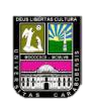 | <center><b>UNIVERSITY OF CARABOBO</b><br>Faculty of Experimental Sciences and Technology (FACYT)<br>Department of Computing<br><br>Elective: Machine Learning<br>Professor: Álvaro Espinoza</center> | 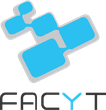 |
|:---:|:---:|:---:|

# Exploratory Data Analysis — Warhammer 40,000 Faction Classification

**Project Assignment 1** · Authors: Gustavo Herrera, Jeanmarco Alarcón · October 2026

Warhammer 40,000 is a tabletop wargame in which every playable unit is described by a **datasheet**: the game statistics of its models, its weapons, its points cost, its keywords and its abilities. This notebook explores the Wahapedia export of those datasheets to understand **whether, and how, the mechanical characteristics of a unit are associated with the faction it belongs to**, which data-quality problems exist, and which hypotheses must be validated before a multiclass classifier is trained. The raw CSV export is loaded into a **SQLite** database by the notebook itself, and every analysis reads from that database.

## 1. Context and problem definition

**Domain.** In Warhammer 40,000 (10th edition) each army belongs to a **faction** (Space Marines, Orks, Necrons, …). A faction's units are published as datasheets. A datasheet lists one or more **model profiles** (Movement, Toughness, Save, Wounds, …), the **weapon profiles** its models can carry, the **points cost** of each allowed unit size, the **keywords** that the rules refer to (`Infantry`, `Vehicle`, `Fly`, …) and its **abilities**.

**Premise.** *"Given the characteristics of a Warhammer 40K unit, predict which faction it belongs to."*

**Motivating question.** *Do the mechanical characteristics of a unit (statistics, weapons, cost, rule keywords and core abilities) carry enough information to identify its faction, and which of them are associated with each faction?*

**Expected usefulness.** A classifier of this kind would tell how "mechanically distinctive" each faction is, and would help to place new or unofficial datasheets. More importantly for the course, the dataset is relational, imbalanced and full of near-duplicate units, which makes it a demanding exercise in building an analytical table whose rows and features have a stable meaning.

| Item | Definition |
|---|---|
| **Unit of observation** | One **datasheet** (one row of `Datasheets`, key `datasheet_id`) that describes a playable unit. Its child rows (model profiles, weapon profiles, costs, keywords, abilities) are summarised with rules whose meaning is stated explicitly in Section 4.7; no unweighted means are used. |
| **Target variable** | `faction_id` (25 classes). `faction_name` is only a display label for `faction_id`; neither of them is ever a feature. |
| **Learning problem** | **Multiclass classification** (single label, 25 imbalanced classes). |
| **Prediction time** | When a datasheet is published: its statistics, weapons, points, keywords and abilities are known; its faction is what we want to infer. |
| **Information available at prediction time** | Everything printed on the datasheet. **Excluded by design:** identifiers, the faction keywords and faction-specific rules (they state the answer), and the publication source (a codex is a faction book). |
| **Features** | **Numeric and mechanical values only**: model statistics, weapon statistics, cost, unit size, rule keywords shared by several factions, core abilities, battlefield role and base. **Words are never used to predict:** unit, model and weapon names are excluded by design. |
| **Data source** | Kaggle dataset *Warhammer 40k* by *theredmage* (<https://www.kaggle.com/datasets/theredmage/warhammer-40k>), **version 5**: 19 CSV files exported from Wahapedia (<https://wahapedia.ru/wh40k10ed/>) on **2025-10-03 20:47:58** (`Last_Update.csv`). The unzipped download is kept unchanged in `data/raw/`. The game content belongs to Games Workshop; the data are used here for academic purposes only. |

## 2. Guiding questions

Each question is answered explicitly in Section 11.1.

1. **Q1 – Construction.** Is the raw export internally consistent (keys, orphan rows, repeated datasheets, formats), and what does one row of the analytical table represent?
2. **Q2 – Quality.** Which values are missing, and *why* (structural absence, not applicable, parsing failure, special value)? Which values are corrupted or out of domain?
3. **Q3 – Target.** How imbalanced are the 25 factions, and what does that imply for baselines and metrics?
4. **Q4 – Model statistics.** Which model statistics (Movement, Toughness, Save, Wounds, …) differ between factions, and how large are those differences once uncertainty is considered?
5. **Q5 – Weapons and cost.** How do weapon profiles (melee vs ranged) and points cost (elite vs horde) differ across factions?
6. **Q6 – Keywords and abilities.** Do rule keywords and core abilities carry faction signal without simply naming the faction?
7. **Q7 – Related units.** How many datasheets are duplicated or near-identical across factions, and how much optimism would a random train/test split introduce?
8. **Q8 – Features.** Which features can be built with a stable operational meaning, and which ones must be excluded or computed inside the validation folds?

## 3. Setup and reproducibility

All imports are grouped here. Paths are relative to the notebook folder (`warhammer/notebooks/`). The random seed controls the bootstrap intervals and the validation folds.

**Folder roles:**
- `data/raw/` holds the **immutable raw export** (19 CSV files). The notebook only reads it and stops if a checksum differs.
- `artifacts/` holds two **generated SQLite databases**, rebuilt on every run:
  - `warhammer_raw.db`: the 19 CSV files loaded verbatim (one table per file, every value as text);
  - `warhammer_clean.db`: built **only from the raw database**, with the tables and columns kept by the decisions of 4.2, the abbreviated characteristics renamed to their full name and the few derived columns defined in 4.6.

In [1]:
import csv
import hashlib
import html
import re
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

# Reproducibility
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Paths (relative to the notebook folder: warhammer/notebooks/)
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
RAW_DIR = PROJECT_DIR / "data" / "raw"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RAW_DB_PATH = ARTIFACTS_DIR / "warhammer_raw.db"      # CSV files loaded verbatim
CLEAN_DB_PATH = ARTIFACTS_DIR / "warhammer_clean.db"  # selection and transformations, built from the raw database
FILE_PREFIX = "Wahapedia Data Export - "

# Source lineage: SHA-256 of each raw CSV of the Kaggle download (version 5, snapshot 2025-10-03)
SOURCE_URL = "https://www.kaggle.com/datasets/theredmage/warhammer-40k"
EXPECTED_SHA256 = {
    "Abilities": "cc82bdfd06aa0174e58e4052f3110c865fecfa7fce7fc6b34bbc251fbd71916d",
    "Datasheets": "c029e088ac3ea699f18e1820309e2af421380d8b527c1dda0c40fbcd8fdc67b4",
    "Detachment_Abilities": "32355f9d0d7657e32fbc37e22d5729196ffd32a7b57cd34978d958a37521d014",
    "DS_Abilities": "3844304cdab463292b9a6f10d816697ccb54a5cccfe12dec6a60f58b340d4cc4",
    "DS_Detachment Abilities": "9e8bcff7847319b06197ccddf4c91dd99ce257ccf638078245a8a4c05ee3442c",
    "DS_enhancements": "018b767e4de616e80c34ed8a0d1ef4f312a5922765db3ccc3d8a4af673a4d379",
    "DS_Keywords": "fab6567a3d4390c562c41ea286051b0c7d5fbfb8c04ca34d5a74f21cb60c2c5b",
    "DS_Leader": "97d79c860c128eb615455619f23f97e7f0020e6278aed3ba4a32f32ebaa99fbc",
    "DS_Model Costs": "6bf975f20c912e6f08cc3489f7e113bf355e792a88613d65ff2012c17b8d355d",
    "DS_Models": "a63228898859243f88112a89b1d7bb6ba4447d2961e6d1c2bef3620288f96ee8",
    "DS_Options": "4d80019626096975d97792c799e55b33033c3101f59d701dec33dcc1807477f7",
    "DS_Stratagems": "7aa7b482d57d1062758a04c2249152c5a2e302878d77dc930a6b0b41279dcbf9",
    "DS_Unit Comp": "cef285ffd61c73fe963ba41abefb937850bbd8469b7c2ce2694f1955eddbbcb7",
    "DS_Wargear": "07a24bc5b59da7ac8ef821ce4ef7e36e65cdb6c576e4855e545b9cdcad7a4472",
    "Enhacements": "925bb98feab054190816f97bdff94c73fac7a9934e72e7024ac26e4645813cdf",
    "Factions": "178f535e8bb871f3f76b4fdfdd2df4d22ce3afd8e60e0452be41a7025d0d1a39",
    "Last_Update": "0bd9408d6616a8c03a5226440a1f4e0a5734ba0be84722792a6ddf01c9148778",
    "Sources": "c105d64b1ac3a75d649f8ddf7b579de24555e54f35f4d9b9ec01499235732985",
    "Stratagems": "f11be03e14c074ff24642bf39858c3264d365ab35240b78d768f84065b7f0a41",
}
# Exact header of each raw CSV (order matters)
EXPECTED_HEADERS = {
    "Abilities": ['id', 'name', 'legend', 'faction_id', 'description'],
    "Datasheets": ['id', 'name', 'faction_id', 'source_id', 'legend', 'role', 'loadout', 'transport', 'virtual', 'leader_head', 'leader_footer', 'damaged_w', 'damaged_description', 'link'],
    "Detachment_Abilities": ['id', 'faction_id', 'name', 'legend', 'description', 'detachment'],
    "DS_Abilities": ['datasheet_id', 'line', 'ability_id', 'model', 'name', 'description', 'type', 'parameter'],
    "DS_Detachment Abilities": ['datasheet_id', 'detachment_ability_id'],
    "DS_enhancements": ['datasheet_id', 'enhancement_id'],
    "DS_Keywords": ['datasheet_id', 'keyword', 'model', 'is_faction_keyword'],
    "DS_Leader": ['leader_id', 'attached_id'],
    "DS_Model Costs": ['datasheet_id', 'line', 'description', 'cost'],
    "DS_Models": ['datasheet_id', 'line', 'name', 'M', 'T', 'Sv', 'inv_sv', 'inv_sv_descr', 'W', 'Ld', 'OC', 'base_size', 'base_size_descr'],
    "DS_Options": ['datasheet_id', 'line', 'button', 'description'],
    "DS_Stratagems": ['datasheet_id', 'stratagem_id'],
    "DS_Unit Comp": ['datasheet_id', 'line', 'description'],
    "DS_Wargear": ['datasheet_id', 'line', 'line_in_wargear', 'dice', 'name', 'description', 'range', 'type', 'A', 'BS_WS', 'S', 'AP', 'D'],
    "Enhacements": ['id', 'faction_id', 'name', 'cost', 'detachment', 'legend', 'description'],
    "Factions": ['id', 'name', 'link'],
    "Last_Update": ['last_update'],
    "Sources": ['id', 'name', 'type', 'edition', 'version', 'errata_date', 'errata_link'],
    "Stratagems": ['faction_id', 'id', 'name', 'type', 'cp_cost', 'legend', 'turn', 'phase', 'detachment', 'description'],
}

# Expected orphan rows of the raw export (checked in 4.3; the build stops if they change)
EXPECTED_ORPHANS = {"DS_Wargear": 134, "DS_Stratagems": 124}

# Analysis constants
TARGET = "faction_id"
CONFIDENCE_LEVEL = 0.95
BOOTSTRAP_SAMPLES = 500
N_FOLDS = 4  # the smallest faction has 4 datasheets, so 4 is the largest stratified fold count

# Display options
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (9, 4.5), "axes.titleweight": "bold"})
BAR_COLOR = "#4f81bd"
ALT_COLOR = "#c0504d"

missing_files = [table for table in EXPECTED_SHA256 if not (RAW_DIR / f"{FILE_PREFIX}{table}.csv").exists()]
if missing_files:
    raise FileNotFoundError(f"Raw files missing in {RAW_DIR}: {missing_files}")
print(f"Raw export: {RAW_DIR.relative_to(PROJECT_DIR)} ({len(EXPECTED_SHA256)} CSV files)")
print(f"Raw DB    : {RAW_DB_PATH.relative_to(PROJECT_DIR)}")
print(f"Clean DB  : {CLEAN_DB_PATH.relative_to(PROJECT_DIR)}")

Raw export: data\raw (19 CSV files)
Raw DB    : artifacts\warhammer_raw.db
Clean DB  : artifacts\warhammer_clean.db


Helper functions used throughout the notebook. `query` is the way the notebook reads data once the database exists.

In [2]:
def query(sql, params=None):
    """Run a SQL query against the analytical database and return a DataFrame."""
    return pd.read_sql_query(sql, connection, params=params)


def query_text(sql):
    """Run a query on raw tables and return Python objects, with SQL NULL as None (not NaN)."""
    frame = query(sql).astype(object)
    return frame.where(frame.notna(), None)


def wilson_interval(successes, totals, confidence=CONFIDENCE_LEVEL):
    """Wilson score interval for a proportion (robust for small groups).

    Parameters
    ----------
    successes, totals : array-like
        Number of positive cases and group sizes.
    confidence : float
        Confidence level of the interval.

    Returns
    -------
    tuple of numpy.ndarray
        Lower and upper bounds of the interval.
    """
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    proportion = successes / totals
    denominator = 1 + z**2 / totals
    centre = (proportion + z**2 / (2 * totals)) / denominator
    half_width = z * np.sqrt(proportion * (1 - proportion) / totals + z**2 / (4 * totals**2)) / denominator
    return centre - half_width, centre + half_width


def cramers_v_from_table(contingency):
    """Bias-corrected Cramér's V (Bergsma, 2013) from a contingency table of counts.

    Empty rows and columns are dropped first.
    """
    table = np.asarray(contingency, dtype=float)
    table = table[table.sum(axis=1) > 0][:, table.sum(axis=0) > 0]
    n = table.sum()
    rows, cols = table.shape
    if rows < 2 or cols < 2:
        return np.nan
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / n
    chi2 = ((table - expected) ** 2 / expected).sum()
    phi2_corrected = max(0.0, chi2 / n - (cols - 1) * (rows - 1) / (n - 1))
    rows_corrected = rows - (rows - 1) ** 2 / (n - 1)
    cols_corrected = cols - (cols - 1) ** 2 / (n - 1)
    denominator = min(cols_corrected - 1, rows_corrected - 1)
    return float(np.sqrt(phi2_corrected / denominator)) if denominator > 0 else np.nan


def cramers_v_with_ci(x, y, n_boot=BOOTSTRAP_SAMPLES):
    """Bias-corrected Cramér's V between two categorical arrays, with a percentile bootstrap CI.

    The bootstrap is vectorised: each resample is a weighted count of the cell codes.
    """
    x_codes, x_levels = pd.factorize(pd.Series(x), sort=True)
    y_codes, y_levels = pd.factorize(pd.Series(y), sort=True)
    keep = (x_codes >= 0) & (y_codes >= 0)
    cells_codes = x_codes[keep] * len(y_levels) + y_codes[keep]
    n_cells = len(x_levels) * len(y_levels)
    shape = (len(x_levels), len(y_levels))
    point = cramers_v_from_table(np.bincount(cells_codes, minlength=n_cells).reshape(shape))
    boot = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, len(cells_codes), len(cells_codes))
        boot[b] = cramers_v_from_table(np.bincount(cells_codes[idx], minlength=n_cells).reshape(shape))
    low, high = np.nanpercentile(boot, [2.5, 97.5])
    return point, low, high


def epsilon_squared(values, codes):
    """Kruskal-Wallis effect size epsilon² = H / (n - 1), with the tie correction used by scipy.

    Parameters
    ----------
    values : numpy.ndarray
        Numeric values without missing entries.
    codes : numpy.ndarray
        Integer class code of each value.
    """
    n = len(values)
    if n < 3 or np.unique(values).size < 2 or np.unique(codes).size < 2:
        return np.nan
    ranks = stats.rankdata(values)
    sizes = np.bincount(codes)
    rank_sums = np.bincount(codes, weights=ranks)
    present = sizes > 0
    h = 12 / (n * (n + 1)) * np.sum(rank_sums[present] ** 2 / sizes[present]) - 3 * (n + 1)
    _, tie_counts = np.unique(values, return_counts=True)
    h /= 1 - np.sum(tie_counts**3 - tie_counts) / (n**3 - n)
    return float(h / (n - 1))


def epsilon_squared_with_ci(values, labels, n_boot=BOOTSTRAP_SAMPLES, generator=None):
    """epsilon² of a numeric variable across classes, with a percentile bootstrap CI (resampling datasheets).

    `generator` defaults to the notebook-wide `rng`.
    """
    generator = rng if generator is None else generator
    values = np.asarray(values, dtype=float)
    codes = pd.factorize(pd.Series(labels))[0]
    keep = ~np.isnan(values)
    values, codes = values[keep], codes[keep]
    point = epsilon_squared(values, codes)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        idx = generator.integers(0, len(values), len(values))
        boot[b] = epsilon_squared(values[idx], codes[idx])
    low, high = np.nanpercentile(boot, [2.5, 97.5])
    return point, low, high

## 4. Building the analytical table: CSV → raw SQLite → clean SQLite

The export is **relational**: `Datasheets` is the parent table and almost every other file is a child table keyed by `datasheet_id`. Reaching one row per datasheet therefore requires joins and aggregations, and every one of them is a modelling decision. This section makes each step explicit and executable.

**Lineage:**
```text
Kaggle download (19 CSV, snapshot 2025-10-03) ── unzipped unchanged ──> data/raw/           [raw, immutable, SHA-256 verified]
   └─(4.1) raw database: one table per file, all 19 files, text exactly as in the CSV ──> artifacts/warhammer_raw.db
        │   (attached read-only to the clean database; every step below reads from it)
        └─(4.2) one documented decision for every raw column (kept, renamed or removed)
        └─(4.3) referential integrity check: orphan rows counted
        └─(4.4) reading check: the text is read exactly, without type guessing
        └─(4.5) parsers: dice expressions, thresholds, movement, bases, costs
        └─(4.6) clean database: kept tables and columns, full names, derived columns ──> artifacts/warhammer_clean.db
              └─ working tables of the session (TEMP, never written to a file): characteristics parsed with a status
        └─(4.7) datasheet_features (working table): one row per datasheet, aggregation rules documented
        └─(4.8) known leakage kept for auditing, checked in code
```

**Scope of this section.** This is the initial phase of the EDA: **loading, cleaning, repair and analysis of the raw data**. It states:
- why each table and column is kept or removed (4.2);
- how orphan rows are detected and cleaned (4.3);
- how the files must be read so that no value is altered (4.4);
- what each game characteristic means and how it is parsed (4.5);
- which new columns are derived (4.7);
- which columns carry known leakage (4.8).

Every decision is applied **in code** after loading the complete export, so it can be audited and reversed, and each one is stated with the evidence that supports it.

### 4.1 Raw database: the complete export, verbatim

All 19 files are verified (checksum, exact header, consistent number of fields per row) and loaded into **`warhammer_raw.db`**, one table per file, with every column stored as text. The raw database is therefore a faithful copy of the export: empty cells become `NULL` and nothing else changes. A `load_manifest` table records the file, checksum, rows and columns of each table. The load runs **inside one transaction**, so a failure leaves no half-built database.

The clean database **`warhammer_clean.db`** is then created and the raw database is **attached to it read-only** under the name `raw`. Every later step reads `raw.<table>` and writes only to the clean database, so the raw copy cannot be modified by the analysis.

In [3]:
def verify_raw_file(table):
    """Stop if a raw CSV is empty or differs from the recorded snapshot. Returns its path."""
    path = RAW_DIR / f"{FILE_PREFIX}{table}.csv"
    content = path.read_bytes()
    if not content.strip():
        raise ValueError(f"The raw file {path.name} is empty.")
    checksum = hashlib.sha256(content).hexdigest()
    if checksum != EXPECTED_SHA256[table]:
        raise ValueError(f"SHA-256 mismatch for {path.name}: expected {EXPECTED_SHA256[table]}, got {checksum}.")
    return path


def read_raw_csv(table):
    """Read a raw CSV as text, checking the exact header and the number of fields of every row."""
    path = verify_raw_file(table)
    with path.open(encoding="utf-8", newline="") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        if header != EXPECTED_HEADERS[table]:
            raise ValueError(f"Unexpected header in {table}.\nExpected: {EXPECTED_HEADERS[table]}\nFound:    {header}")
        rows = []
        for line_number, row in enumerate(reader, start=2):
            if len(row) != len(header):
                raise ValueError(f"{table}, line {line_number}: {len(row)} fields, expected {len(header)}.")
            rows.append(tuple(None if value.strip() == "" else value for value in row))
    return header, rows


def raw_table_name(table):
    """Name of a file's table in the raw database, e.g. 'DS_Model Costs' -> DS_Model_Costs."""
    return re.sub(r"\W+", "_", table)


def staging_name(table):
    """How the clean database reads a raw table: through the attached schema `raw`."""
    return f"raw.{raw_table_name(table)}"


for path in (RAW_DB_PATH, CLEAN_DB_PATH):
    if path.exists():
        path.unlink()  # both databases are generated artifacts: always rebuilt from the CSV files

# --- 1) raw database: the CSV files, verbatim
# isolation_level=None: no implicit transactions; each build step manages its own BEGIN/COMMIT
raw_connection = sqlite3.connect(RAW_DB_PATH, isolation_level=None)
load_manifest = []
raw_connection.execute("BEGIN")
try:
    for table in EXPECTED_SHA256:
        header, rows = read_raw_csv(table)
        columns = ", ".join(f'"{column}" TEXT' for column in header)
        raw_connection.execute(f'CREATE TABLE "{raw_table_name(table)}" ({columns})')
        placeholders = ", ".join("?" * len(header))
        raw_connection.executemany(f'INSERT INTO "{raw_table_name(table)}" VALUES ({placeholders})', rows)
        load_manifest.append((f"{FILE_PREFIX}{table}.csv", raw_table_name(table), EXPECTED_SHA256[table],
                              len(rows), len(header)))
    raw_connection.execute("""CREATE TABLE load_manifest (source_file TEXT PRIMARY KEY, raw_table TEXT NOT NULL,
                              sha256 TEXT NOT NULL, csv_rows INTEGER NOT NULL, columns INTEGER NOT NULL)""")
    raw_connection.executemany("INSERT INTO load_manifest VALUES (?, ?, ?, ?, ?)", load_manifest)
    raw_connection.execute("COMMIT")
except Exception:
    raw_connection.execute("ROLLBACK")
    raise
raw_connection.close()

# --- 2) clean database, with the raw database attached read-only
connection = sqlite3.connect(f"file:{CLEAN_DB_PATH.as_posix()}", uri=True, isolation_level=None)
connection.execute("ATTACH DATABASE ? AS raw", (f"file:{RAW_DB_PATH.as_posix()}?mode=ro",))

staging_audit = query("SELECT raw_table, csv_rows, columns FROM raw.load_manifest")
staging_audit["sqlite_rows"] = [query(f'SELECT COUNT(*) AS n FROM raw."{name}"')["n"].iloc[0]
                                for name in staging_audit["raw_table"]]
if not (staging_audit["csv_rows"] == staging_audit["sqlite_rows"]).all():
    raise ValueError("Row counts differ between the CSV files and the raw database.")
try:
    connection.execute("CREATE TABLE raw.write_test (x)")
    raise RuntimeError("The raw database should be read-only for the clean build.")
except sqlite3.OperationalError:
    pass  # expected: the attached raw database cannot be modified
print("All 19 files match their recorded SHA-256 and header; row counts match between CSV and the raw database.")
print("The raw database is attached read-only to the clean database.")
print("Snapshot date (Last_Update.csv):", query("SELECT last_update FROM raw.Last_Update")["last_update"].iloc[0])
display(staging_audit)

All 19 files match their recorded SHA-256 and header; row counts match between CSV and the raw database.
The raw database is attached read-only to the clean database.
Snapshot date (Last_Update.csv): 10/3/2025 20:47:58


,raw_table,csv_rows,columns,sqlite_rows
0,Abilities,68,5,68
1,Datasheets,1636,14,1636
2,Detachment_Abilities,237,6,237
3,DS_Abilities,6744,8,6744
4,DS_Detachment_Abilities,11163,2,11163
5,DS_enhancements,8001,2,8001
6,DS_Keywords,15239,4,15239
7,DS_Leader,1466,2,1466
8,DS_Model_Costs,2038,4,2038
9,DS_Models,1731,13,1731


**Interpretation.**
- All 19 files of the export match the checksums recorded for the download, have exactly the expected header and the same number of rows in the CSV and in the raw database. `warhammer_raw.db` is therefore a verified copy of the source, and because it is attached read-only, the analysis cannot change it: any difference in `warhammer_clean.db` is caused by an explicit step of this notebook.
- The snapshot is dated 2025-10-03 20:47:58, the date of version 5 of the Kaggle dataset. The analysis describes the game *as published on that date*: later balance updates (points, profiles) can change several conclusions.
- `Datasheets` has 1,636 rows. After the empty duplicates are removed (4.6), the analytical table has 1,350 observations for 25 classes. That is small for a multiclass problem, and it drives the validation choices in Section 11.5.

### 4.2 Table and column decisions

Every raw column has one decision with a reason. The decisions are written below as data and **checked against the headers of the 19 files**: the build stops if a raw column has no decision or if a decision names a column that does not exist. `clean_column` is the name of the column in `warhammer_clean.db`; it is empty when the column is not copied. Abbreviated characteristics take their full name (glossary in 4.5).

| Role | Meaning |
|---|---|
| `key` | join or primary-key column; never a feature |
| `target` / `target alias` | the label `y` and its display name |
| `feature source` | parsed or derived into features (4.5, 4.7) |
| `filter` | used to select rows, not as a value |
| `known leakage` | kept for readability and auditing; never in `X` (4.8) |
| `verification only` | kept only to verify a claim (4.8) |
| `removed` / `removed (whole table)` | not copied to the clean database; it stays in the raw database |

The **only new columns** of the clean database are listed in `ADDED_COLUMNS`: `base_area`, `is_flying_base` and `kw_FLY` in `DS_Models`; a numeric column next to every characteristic that can be written as a dice expression; and, in `DS_Model_Costs`, the total number of models of each size option and the real cost per model.

In [4]:
TABLE_REMOVALS = {
    "Stratagems": "faction-exclusive rules: each stratagem belongs to one faction and detachment (a trivial shortcut to the target)",
    "DS_Stratagems": "link table to Stratagems (it also has 124 orphan rows, 4.3)",
    "Enhacements": "faction-exclusive upgrades; optional, so they do not define the unit's base profile",
    "DS_enhancements": "link table to Enhancements",
    "Detachment_Abilities": "detachments are sub-factions (e.g. Gladius Task Force = Space Marines)",
    "DS_Detachment Abilities": "link table to Detachment_Abilities",
    "DS_Options": "wargear options as free text; it names faction-specific weapons",
    "DS_Leader": "leader-unit links: if A and C attach to B, a model can infer that A and C share a faction (transitive leakage)",
    "Sources": "maps each publication (codex) to a faction",
    "Last_Update": "extraction metadata; read only to report the snapshot date (4.1)",
    "DS_Unit Comp": ("composition text ('1 Boss Nob', '9-19 Boyz', named characters). Replaced by "
                     "DS_Model_Costs.description, which gives the number of models of each size option and its price "
                     "directly; DS_Unit_Comp needs ranges, alternatives and HTML to be parsed and has no price (compared in 4.6)"),
}
PARSED = "feature source"
REMOVED = "removed"
COLUMN_DECISIONS = {  # raw column: (role, column in the clean database or None, reason)
    "Factions": {
        "id": ("target", "id", "faction code (same values as Datasheets.faction_id)"),
        "name": ("target alias", "name", "display name of the faction; never a feature"),
        "link": (REMOVED, None, "URL"),
    },
    "Datasheets": {
        "id": ("key", "id", "primary key of the unit of observation (datasheet_id)"),
        "name": ("known leakage", "name", "unit name ('Gretchin', 'Intercessor Squad') reveals the unit; never a feature"),
        "faction_id": ("target", "faction_id", "faction code: the label y"),
        "source_id": (REMOVED, None, "identifies the codex / book, i.e. the faction (direct leakage)"),
        "legend": (REMOVED, None, "narrative text without game statistics"),
        "role": (PARSED, "role", "battlefield role (Battleline, Characters, Dedicated Transports, ...)"),
        "loadout": (REMOVED, None, "equipment as text, redundant with DS_Wargear; read from the raw database only in 6.5, "
                                   "to diagnose datasheets without weapon profiles"),
        "transport": (REMOVED, None, "present in few datasheets (see the evidence below); HTML text with faction-specific rules"),
        "virtual": (REMOVED, None, "internal Wahapedia metadata (pages that are not units); read from the raw database as "
                                   "is_virtual, for auditing only"),
        "leader_head": (REMOVED, None, "free text about leaders; leader links are in DS_Leader (removed)"),
        "leader_footer": (REMOVED, None, "free text about leaders; leader links are in DS_Leader (removed)"),
        "damaged_w": (REMOVED, None, "wounds range of the 'damaged' profile of large models: its information (a model that "
                                     "degrades) is already captured by its high Wounds; checked in 10.4"),
        "damaged_description": (REMOVED, None, "HTML text; read from the raw database only in 10.4, to check that the damaged "
                                               "range is redundant with Wounds"),
        "link": (REMOVED, None, "URL"),
    },
    "DS_Models": {
        "datasheet_id": ("key", "datasheet_id", "parent datasheet"),
        "line": (REMOVED, None, "profile number inside the datasheet: a layout index"),
        "name": ("known leakage", "name", "miniature name ('GHAZGHKULL THRAKA') reveals the unit; never a feature"),
        "M": (PARSED, "movement", "Movement"),
        "T": (PARSED, "toughness", "Toughness"),
        "Sv": (PARSED, "save", "Save"),
        "inv_sv": (PARSED, "invulnerable_save", "Invulnerable Save"),
        "inv_sv_descr": (REMOVED, None, "free-text description of the invulnerable save; its value is already in inv_sv"),
        "W": (PARSED, "wounds", "Wounds"),
        "Ld": (PARSED, "leadership", "Leadership"),
        "OC": (PARSED, "objective_control", "Objective Control"),
        "base_size": (PARSED, "base_size", "base as text; base_area and is_flying_base are derived from it"),
        "base_size_descr": (REMOVED, None, "redundant free-text description of the base"),
    },
    "DS_Wargear": {
        "datasheet_id": ("key", "datasheet_id", "parent datasheet"),
        "line": (REMOVED, None, "weapon number inside the datasheet: a layout index"),
        "line_in_wargear": (REMOVED, None, "profile number inside the weapon: a layout index"),
        "dice": (REMOVED, None, "empty column: the dice of the weapons are written in A, S and D; in this copy only "
                                "3 cells hold a number (4.4)"),
        "name": ("known leakage", "name", "weapon names are faction vocabulary ('Shuriken catapult'); never a feature"),
        "description": (REMOVED, None, "weapon special rules as HTML text"),
        "range": (PARSED, "range", "Range in inches, 'Melee' for close combat"),
        "type": (PARSED, "type", "Melee or Ranged: splits the weapon envelope"),
        "A": (PARSED, "attacks", "Attacks, number or dice"),
        "BS_WS": (PARSED, "ballistic_weapon_skill", "Ballistic / Weapon Skill"),
        "S": (PARSED, "strength", "Strength, number or dice"),
        "AP": (PARSED, "armour_penetration", "Armour Penetration"),
        "D": (PARSED, "damage", "Damage, number or dice"),
    },
    "DS_Model Costs": {
        "datasheet_id": ("key", "datasheet_id", "parent datasheet"),
        "line": (REMOVED, None, "size option number: a layout index"),
        "description": (PARSED, "description", "number of models ('5 models', '1 Spanner and 4 Burna Boyz') and alternative-price context"),
        "cost": (PARSED, "cost", "points; '+N' marks an optional extra model"),
    },
    "DS_Keywords": {
        "datasheet_id": ("key", "datasheet_id", "parent datasheet"),
        "keyword": (PARSED, "keyword", "rule keywords (Infantry, Vehicle, Fly, ...); universality filter: kept only if present "
                                       "in >= 2 factions (4.6); refitted inside each training fold for the model (10.6)"),
        "model": (REMOVED, None, "miniature the keyword applies to ('Ghazghkull Thraka'): it reveals the faction"),
        "is_faction_keyword": ("known leakage", "is_faction_keyword", "TRUE rows state the faction; never a feature"),
    },
    "DS_Abilities": {
        "datasheet_id": ("key", "datasheet_id", "parent datasheet"),
        "line": (REMOVED, None, "ability number inside the datasheet: a layout index"),
        "ability_id": ("key", "ability_id", "link to Abilities; identifies the Core abilities"),
        "model": (REMOVED, None, "miniature name (leakage)"),
        "name": (REMOVED, None, "names of datasheet and faction abilities; Core abilities are identified through ability_id"),
        "description": (REMOVED, None, "rule text in HTML"),
        "type": ("filter", "type", "only 'Core' rows are loaded: faction and datasheet abilities name the faction"),
        "parameter": (PARSED, "parameter", "intensity of the ability (Feel No Pain 5+ vs 6+, Deadly Demise D3 vs D6)"),
    },
    "Abilities": {
        "id": ("key", "id", "ability id. It is not unique in the raw table (the same id "
                            "appears for several factions); among the Core abilities, the only ones loaded, it is unique"),
        "name": (PARSED, "name", "name of the Core ability, used to name its feature"),
        "legend": (REMOVED, None, "narrative text"),
        "faction_id": ("verification only", "faction_id", "empty for every Core ability; checked in 4.8"),
        "description": (REMOVED, None, "rule text in HTML"),
    },
}
ADDED_COLUMNS = {  # raw table: [(new column in the clean database, placed after, SQL type, rule)]
    "DS_Models": [
        ("base_area", "base_size", "REAL", "area of the base in mm², assuming a circle or an ellipse"),
        ("is_flying_base", "base_area", "INTEGER", "1 if a regular expression finds the text 'flying' in base_size, else 0"),
        ("kw_FLY", "is_flying_base", "INTEGER", "1 if the datasheet has the keyword Fly in DS_Keywords, else 0"),
    ],
    "DS_Wargear": [
        ("attacks_mean", "attacks", "REAL", "expected value of attacks, a number or a dice expression: "
                                            "nDk+c -> n*(k+1)/2 + c (2D6 -> 7)"),
        ("strength_mean", "strength", "REAL", "expected value of strength, a number or a dice expression"),
        ("damage_mean", "damage", "REAL", "expected value of damage, a number or a dice expression (D6+1 -> 4.5)"),
    ],
    "DS_Model Costs": [
        ("total_models", "description", "INTEGER", "total number of models of the size option: sum of the numbers in "
                                                   "description outside parentheses ('1 Spanner and 4 Burna Boyz' -> 5); "
                                                   "1 for a single model without a number ('Attack Bike')"),
        ("cost_per_model", "cost", "REAL", "real cost per model: points / total_models ('+55' for one extra model -> 55)"),
    ],
    "DS_Abilities": [
        ("parameter_mean", "parameter", "REAL", "expected value of parameter when it is a number or a dice expression "
                                                "(D6+2 -> 5.5); thresholds such as Feel No Pain 5+ stay NULL"),
    ],
}


def clean_columns(table):
    """Columns of a table in the clean database, in order: the kept raw columns (renamed) and the added ones."""
    columns = [COLUMN_DECISIONS[table][column][1] for column in EXPECTED_HEADERS[table]
               if COLUMN_DECISIONS[table][column][1] is not None]
    for new, after, _, _ in ADDED_COLUMNS.get(table, []):
        columns.insert(columns.index(after) + 1, new)
    return columns


decision_rows = []
for table, header in EXPECTED_HEADERS.items():
    if table in TABLE_REMOVALS:
        decision_rows += [(table, column, "removed (whole table)", None, TABLE_REMOVALS[table]) for column in header]
        continue
    decisions = COLUMN_DECISIONS[table]
    if set(decisions) != set(header):
        raise ValueError(f"{table}: columns without a decision {sorted(set(header) - set(decisions))}, "
                         f"decisions for unknown columns {sorted(set(decisions) - set(header))}")
    decision_rows += [(table, column, *decisions[column]) for column in header]
column_decisions = pd.DataFrame(decision_rows, columns=["raw_table", "column", "role", "clean_column", "reason"])
kept = column_decisions["clean_column"].notna()
print(f"{len(column_decisions)} raw columns in {column_decisions['raw_table'].nunique()} files; each one has exactly one "
      f"documented decision. {kept.sum()} columns of {column_decisions.loc[kept, 'raw_table'].nunique()} tables are kept, "
      f"{(kept & (column_decisions['clean_column'] != column_decisions['column'])).sum()} of them renamed.")
print("\nNumber of raw columns of each table, by decision:")
display(pd.crosstab(column_decisions["raw_table"], column_decisions["role"]))

evidence = query("""SELECT AVG(transport IS NOT NULL) AS transport_filled_share,
                           SUM(virtual = 'TRUE')     AS virtual_datasheets,
                           (SELECT COUNT(*) FROM (SELECT id FROM raw.Abilities GROUP BY id HAVING COUNT(*) > 1))
                                                     AS ability_ids_repeated
                    FROM raw.Datasheets""")
print("Evidence for three decisions: share of datasheets with a transport text, internal 'virtual' pages, "
      "ability ids repeated in Abilities:")
display(evidence)
with pd.option_context("display.max_colwidth", 230, "display.max_rows", 200):
    print("Decision for every column of the tables that are kept (raw name, role, name in the clean database, reason):")
    display(column_decisions[column_decisions["role"] != "removed (whole table)"].reset_index(drop=True)
            .fillna({"clean_column": "— (not copied)"}))
    print("Tables removed whole (not copied to the clean database): number of columns and reason:")
    display(column_decisions[column_decisions["role"] == "removed (whole table)"]
            .groupby("raw_table").agg(columns=("column", "size"), reason=("reason", "first")))
    print("Columns added to the clean database (the only new columns):")
    display(pd.DataFrame([(raw_table_name(table), new, rule) for table, added in ADDED_COLUMNS.items()
                          for new, _, _, rule in added], columns=["clean_table", "column", "rule"]))

110 raw columns in 19 files; each one has exactly one documented decision. 38 columns of 8 tables are kept, 12 of them renamed.

Number of raw columns of each table, by decision:


role,feature source,filter,key,known leakage,removed,removed (whole table),target,target alias,verification only
raw_table,,,,,,,,,
Abilities,1,0,1,0,2,0,0,0,1
DS_Abilities,1,1,2,0,4,0,0,0,0
DS_Detachment Abilities,0,0,0,0,0,2,0,0,0
DS_Keywords,1,0,1,1,1,0,0,0,0
DS_Leader,0,0,0,0,0,2,0,0,0
DS_Model Costs,2,0,1,0,1,0,0,0,0
DS_Models,8,0,1,1,3,0,0,0,0
DS_Options,0,0,0,0,0,4,0,0,0
DS_Stratagems,0,0,0,0,0,2,0,0,0


Evidence for three decisions: share of datasheets with a transport text, internal 'virtual' pages, ability ids repeated in Abilities:


,transport_filled_share,virtual_datasheets,ability_ids_repeated
0,0.108,3,13


Decision for every column of the tables that are kept (raw name, role, name in the clean database, reason):


,raw_table,column,role,clean_column,reason
0,Abilities,id,key,id,"ability id. It is not unique in the raw table (the same id appears for several factions); among the Core abilities, the only ones loaded, it is unique"
1,Abilities,name,feature source,name,"name of the Core ability, used to name its feature"
2,Abilities,legend,removed,— (not copied),narrative text
3,Abilities,faction_id,verification only,faction_id,empty for every Core ability; checked in 4.8
4,Abilities,description,removed,— (not copied),rule text in HTML
5,Datasheets,id,key,id,primary key of the unit of observation (datasheet_id)
6,Datasheets,name,known leakage,name,"unit name ('Gretchin', 'Intercessor Squad') reveals the unit; never a feature"
7,Datasheets,faction_id,target,faction_id,faction code: the label y
8,Datasheets,source_id,removed,— (not copied),"identifies the codex / book, i.e. the faction (direct leakage)"
9,Datasheets,legend,removed,— (not copied),narrative text without game statistics


Tables removed whole (not copied to the clean database): number of columns and reason:


,columns,reason
raw_table,,
DS_Detachment Abilities,2,link table to Detachment_Abilities
DS_Leader,2,"leader-unit links: if A and C attach to B, a model can infer that A and C share a faction (transitive leakage)"
DS_Options,4,wargear options as free text; it names faction-specific weapons
DS_Stratagems,2,"link table to Stratagems (it also has 124 orphan rows, 4.3)"
DS_Unit Comp,3,"composition text ('1 Boss Nob', '9-19 Boyz', named characters). Replaced by DS_Model_Costs.description, which gives the number of models of each size option and its price directly; DS_Unit_Comp needs ranges, alternatives and H..."
DS_enhancements,2,link table to Enhancements
Detachment_Abilities,6,detachments are sub-factions (e.g. Gladius Task Force = Space Marines)
Enhacements,7,"faction-exclusive upgrades; optional, so they do not define the unit's base profile"
Last_Update,1,extraction metadata; read only to report the snapshot date (4.1)


Columns added to the clean database (the only new columns):


,clean_table,column,rule
0,DS_Models,base_area,"area of the base in mm², assuming a circle or an ellipse"
1,DS_Models,is_flying_base,"1 if a regular expression finds the text 'flying' in base_size, else 0"
2,DS_Models,kw_FLY,"1 if the datasheet has the keyword Fly in DS_Keywords, else 0"
3,DS_Wargear,attacks_mean,"expected value of attacks, a number or a dice expression: nDk+c -> n*(k+1)/2 + c (2D6 -> 7)"
4,DS_Wargear,strength_mean,"expected value of strength, a number or a dice expression"
5,DS_Wargear,damage_mean,"expected value of damage, a number or a dice expression (D6+1 -> 4.5)"
6,DS_Model_Costs,total_models,total number of models of the size option: sum of the numbers in description outside parentheses ('1 Spanner and 4 Burna Boyz' -> 5); 1 for a single model without a number ('Attack Bike')
7,DS_Model_Costs,cost_per_model,real cost per model: points / total_models ('+55' for one extra model -> 55)
8,DS_Abilities,parameter_mean,expected value of parameter when it is a number or a dice expression (D6+2 -> 5.5); thresholds such as Feel No Pain 5+ stay NULL


**Interpretation.**
- **Every one of the 110 raw columns has exactly one decision.**
  - 11 tables (46 columns) are removed whole, because they reveal the faction (stratagems, enhancements, detachments, sources, leader links, wargear options) or are metadata.
  - The 8 remaining tables keep **38 columns**: keys, the target and its alias, the characteristics, and the columns with known leakage kept for readability (names, `is_faction_keyword`). **9 columns are added** (second table): the base and `Fly` indicators, the expected value of the dice expressions and the cost per model.
  - **12 characteristics are renamed** to their full name (`M` → `movement`, `BS_WS` → `ballistic_weapon_skill`, …).
  - The layout indexes (`line`) and the removed text columns stay only in the raw database. `loadout`, `virtual` and `damaged_description` are read from there for the diagnostics of 6.5 and 10.4.
- **Removed columns with little content:** `transport` is filled in only 10.8% of the datasheets, and 3 datasheets are internal `virtual` pages.
- **`Abilities.id` is not a unique key in the raw table:** 13 ids are repeated across factions. Among the Core abilities, the only ones loaded, it is unique (4.6).
- **`dice` and `damaged_w` are removed.**
  - `dice` is empty; the dice of the weapons are in `A`, `S` and `D`.
  - `damaged_w` is redundant with Wounds: only large models have a damaged profile (10.4).
- **`DS_Unit_Comp` is replaced by `DS_Model_Costs`.** `DS_Model_Costs.description` gives the number of models of each size option and its price in one row, so `total_models` and `cost_per_model` are direct. `DS_Unit_Comp` describes the same sizes as free text with ranges, alternatives and HTML, and has no price (compared in 4.6).

### 4.3 Referential integrity of the raw export

Every child table must point to an existing datasheet, and every link table must point to an existing parent row. Rows that violate a relation are **orphans**. They are counted by relation and compared with the expected counts (the build stops if they change); the orphan weapons are then left out of the clean database (4.6). No log table is stored.

**Origin of the orphans.** When Wahapedia removes or retires a unit, it deletes its row from `Datasheets` but not always its weapons or stratagem links. Such "ghost" rows have no unit and no faction, so they cannot enter any join of the analytical table.

In [5]:
RELATIONS = [
    # (child raw table, child column, parent raw table, parent column)
    ("raw.DS_Models", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Wargear", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Model_Costs", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Keywords", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Abilities", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Unit_Comp", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Options", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Stratagems", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_enhancements", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Detachment_Abilities", "datasheet_id", "raw.Datasheets", "id"),
    ("raw.DS_Leader", "leader_id", "raw.Datasheets", "id"),
    ("raw.DS_Leader", "attached_id", "raw.Datasheets", "id"),
    ("raw.DS_Abilities", "ability_id", "raw.Abilities", "id"),
    ("raw.DS_Stratagems", "stratagem_id", "raw.Stratagems", "id"),
    ("raw.DS_enhancements", "enhancement_id", "raw.Enhacements", "id"),
    ("raw.DS_Detachment_Abilities", "detachment_ability_id", "raw.Detachment_Abilities", "id"),
    ("raw.Datasheets", "faction_id", "raw.Factions", "id"),
    ("raw.Datasheets", "source_id", "raw.Sources", "id"),
]

integrity, orphan_parts = [], []
for child, column, parent, parent_column in RELATIONS:
    orphan_sql = f"""
        FROM {child} AS c
        WHERE c."{column}" IS NOT NULL
          AND c."{column}" NOT IN (SELECT "{parent_column}" FROM {parent} WHERE "{parent_column}" IS NOT NULL)"""
    orphan_keys = query(f"""SELECT '{child}' AS source_table, '{column}' AS key_column, c."{column}" AS key_value,
                                   COUNT(*) AS n_rows {orphan_sql} GROUP BY c."{column}" """)
    n_null = connection.execute(f'SELECT COUNT(*) FROM {child} WHERE "{column}" IS NULL').fetchone()[0]
    integrity.append({"relation": f"{child}.{column} -> {parent}.{parent_column}",
                      "orphan_rows": int(orphan_keys["n_rows"].sum()), "missing_parent_keys": len(orphan_keys),
                      "null_keys": n_null})
    orphan_parts.append(orphan_keys)
integrity = pd.DataFrame(integrity)
display(integrity)

orphans = pd.concat(orphan_parts, ignore_index=True)
orphans_by_table = (orphans.groupby("source_table")
                    .agg(orphan_rows=("n_rows", "sum"), missing_datasheets=("key_value", "size")).reset_index())
display(orphans_by_table)
for table, expected in EXPECTED_ORPHANS.items():
    found = orphans_by_table.loc[orphans_by_table["source_table"] == staging_name(table), "orphan_rows"].sum()
    if found != expected:
        raise ValueError(f"{table}: {found} orphan rows found, {expected} expected.")
    print(f"{table}: {found} orphan rows, as expected.")

,relation,orphan_rows,missing_parent_keys,null_keys
0,raw.DS_Models.datasheet_id -> raw.Datasheets.id,0,0,0
1,raw.DS_Wargear.datasheet_id -> raw.Datasheets.id,134,65,0
2,raw.DS_Model_Costs.datasheet_id -> raw.Datasheets.id,0,0,0
3,raw.DS_Keywords.datasheet_id -> raw.Datasheets.id,0,0,0
4,raw.DS_Abilities.datasheet_id -> raw.Datasheets.id,0,0,0
5,raw.DS_Unit_Comp.datasheet_id -> raw.Datasheets.id,0,0,0
6,raw.DS_Options.datasheet_id -> raw.Datasheets.id,0,0,0
7,raw.DS_Stratagems.datasheet_id -> raw.Datasheets.id,124,27,0
8,raw.DS_enhancements.datasheet_id -> raw.Datasheets.id,0,0,0
9,raw.DS_Detachment_Abilities.datasheet_id -> raw.Datashee...,0,0,0


,source_table,orphan_rows,missing_datasheets
0,raw.DS_Stratagems,124,27
1,raw.DS_Wargear,134,65


DS_Wargear: 134 orphan rows, as expected.
DS_Stratagems: 124 orphan rows, as expected.


**Interpretation.**
- Only two relations are broken. **134 rows of `DS_Wargear`** point to 65 datasheets that do not exist, and **124 rows of `DS_Stratagems`** point to 27. A plausible cause is that Wahapedia removed units from `Datasheets` without removing their weapons. The orphan weapons cannot be assigned to a unit or a faction, so they are excluded; the stratagems are not used at all.
- The 3,368 `DS_Abilities` rows without `ability_id` are **not** orphans. They are datasheet-specific abilities whose name and text are stored inline. They are not Core rules, so they are not loaded into the clean database (4.6). The 3 datasheets without `source_id` have no publication source.
- The exclusion is **visible and reproducible**: the orphans are counted in code, and the build stops if the counts change.

### 4.4 Reading the files without altering them

A CSV file only stores text. A reader that **guesses types** can change values before any analysis starts. The check below reads every file twice: once with the `csv` module, as text exactly as written (the reading used by this notebook), and once with `pandas.read_csv` and its default options (the usual way of loading a CSV). It lists the columns whose values change between the two readings.

In [6]:
def clean_text(text):
    """Strip HTML tags and entities and normalise typographic hyphens and apostrophes."""
    if pd.isna(text):
        return None
    text = html.unescape(re.sub(r"<[^>]+>", " ", text))
    text = text.replace("‑", "-").replace("–", "-").replace("’", "'")
    return re.sub(r"\s+", " ", text).strip()


def read_exact(table):
    """Read a raw CSV as text, exactly as written in the file."""
    with (RAW_DIR / f"{FILE_PREFIX}{table}.csv").open(encoding="utf-8", newline="") as handle:
        rows = list(csv.reader(handle))
    return pd.DataFrame(rows[1:], columns=rows[0])


reading_rows = []
for table in EXPECTED_SHA256:
    exact = read_exact(table)
    guessed = pd.read_csv(RAW_DIR / f"{FILE_PREFIX}{table}.csv")
    for column in exact.columns:
        text, value = exact[column], guessed[column]
        became_missing = (text != "") & value.isna()
        lost_sign = text.str.startswith("+") & value.notna()
        integer_as_decimal = (value.dtype == "float64") & text.str.fullmatch(r"\d+")
        if became_missing.any() or lost_sign.any() or integer_as_decimal.any():
            altered = became_missing | lost_sign | integer_as_decimal
            reading_rows.append({
                "file": table, "column": column, "type_guessed": str(value.dtype),
                "text_read_as_missing": int(became_missing.sum()),
                "'+N' read as N": int(lost_sign.sum()),
                "integers read as decimals": int(integer_as_decimal.sum()),
                "example (text -> value read)": f"{text[altered].iloc[0]!r} -> {value[altered].iloc[0]!r}",
            })
reading_check = pd.DataFrame(reading_rows)
display(reading_check)

print("Columns of the export that hold numbers where a range or nothing is expected (both removed in 4.2):")
display(query("""SELECT 'DS_Wargear.dice' AS column_name, COUNT(dice) AS non_empty_cells,
                        GROUP_CONCAT(DISTINCT dice) AS values_found
                 FROM raw.DS_Wargear
                 UNION ALL
                 SELECT 'Datasheets.damaged_w', COUNT(damaged_w), substr(GROUP_CONCAT(DISTINCT damaged_w), 1, 60)
                 FROM raw.Datasheets"""))

,file,column,type_guessed,text_read_as_missing,'+N' read as N,integers read as decimals,example (text -> value read)
0,Datasheets,source_id,float64,0,0,1633,'46' -> np.float64(46.0)
1,Datasheets,damaged_w,float64,0,0,354,'45661' -> np.float64(45661.0)
2,DS_Abilities,ability_id,float64,0,0,3376,'8346' -> np.float64(8346.0)
3,DS_Model Costs,cost,int64,0,4,0,'+55' -> np.int64(55)
4,DS_Options,description,str,270,0,0,'None' -> nan
5,DS_Wargear,dice,float64,0,0,3,'45659' -> np.float64(45659.0)
6,DS_Wargear,range,str,1,0,0,'N/A' -> nan
7,DS_Wargear,BS_WS,str,428,0,0,'N/A' -> nan
8,Enhacements,cost,int64,0,4,0,'+40' -> np.int64(40)
9,Sources,version,float64,0,0,6,'1' -> np.float64(1.0)


Columns of the export that hold numbers where a range or nothing is expected (both removed in 4.2):


,column_name,non_empty_cells,values_found
0,DS_Wargear.dice,3,"45659,45720,45783"
1,Datasheets.damaged_w,354,"45661,45662,45664,45667,45663,45665,45660,45666,45677,45..."


**Interpretation.** The files are well formed (4.1), but **how they are read matters**. Reading them with default type guessing silently changes values in eleven columns:
- **`N/A` becomes an empty cell**: 428 weapon skills and one range. "Hits automatically" becomes indistinguishable from "value missing".
- **`+N` becomes N**: 4 unit costs and 4 enhancement costs. The price of an optional extra model ("Attack Bike +55") then looks like the price of a full unit.
- **The text `None` becomes an empty cell**: 270 wargear options.
- **Identifiers become decimals** (`8346` → `8346.0`) because their columns contain empty cells. No information is lost, but the ids no longer match as text.

This notebook reads every file as **exact text** (4.1): only empty cells become `NULL`, the clean database keeps the text as written (4.6), and the analysis parses it with explicit rules (4.5).

`DS_Wargear.dice` and `Datasheets.damaged_w` hold numbers such as `45659` and `45661` where the game would write nothing or a range like `1-4`. These numbers are written in the file itself; no reader creates them. Both columns are removed by the decisions of 4.2, so they are documented here but not used.

### 4.5 Parsers that keep the raw text

**Glossary of the game characteristics.** Lower is better for `Sv`, `inv_sv`, `Ld` and `BS_WS`: they are minimum results on a six-sided die (D6).

| Column | Name | Meaning in the game | Raw format |
|---|---|---|---|
| `M` | Movement | inches the model can move in the Movement phase | `6"`; `20+"` = minimum move (aircraft); `-` = immobile |
| `T` | Toughness | physical resistance; compared with the weapon's Strength to wound | number; `5*` = value with a special rule |
| `Sv` | Save | armour save: minimum D6 roll to ignore an attack; worsened by AP | `3+`; `7+` = no armour save |
| `inv_sv` | Invulnerable save | save that AP cannot worsen (force field, magic) | `4`; `4*` = conditional; `-` = none |
| `W` | Wounds | damage a model can take before it is removed | number |
| `Ld` | Leadership | 2D6 threshold of the Battle-shock test | `6+` |
| `OC` | Objective Control | weight of the model when controlling objectives | number (0 for aircraft and buildings) |
| `base_size` | Base | size of the miniature's base | `32mm`, `170 x 109mm`, `… flying base`, `Use model` (hull) |
| `range` | Range | maximum distance of a weapon, in inches | number; `Melee` = close combat |
| `A` | Attacks | attacks made by the weapon | number or dice (`D6`, `2D6+3`) |
| `BS_WS` | Ballistic / Weapon Skill | minimum D6 roll to hit | `3`, `3+`; `N/A` = hits automatically |
| `S` | Strength | compared with the target's Toughness to wound | number or dice |
| `AP` | Armour Penetration | modifier applied to the target's Save | `0` to `-6` |
| `D` | Damage | wounds removed by each unsaved attack | number or dice |

The game writes characteristics as text: `6"` (inches), `4+` (minimum die result), `5*` (value with a special rule), `-` (the characteristic does not exist), `N/A` (not applicable, e.g. weapons that hit automatically) and **dice expressions** such as `D6`, `2D6+3`. Casting them directly to numbers would turn `-` into `0` and every dice expression into a missing value.

Here every characteristic is parsed by a function that returns the number **and a status**, and the raw text is kept next to the parsed value:

| Status | Meaning | Example |
|---|---|---|
| `fixed` | plain number | `3`, `4+`, `6"` |
| `dice` | dice expression, summarised by expected value, minimum and maximum | `D6` → 3.5 / 1 / 6 |
| `special` | number with a rule attached (kept as the number + a flag) | `5*`, `20+"` |
| `structural` | the characteristic does not exist for this model | `-` |
| `not_applicable` | the characteristic exists but has no value by design | `N/A` |
| `missing` | empty cell | |
| `failed` | text that no rule recognises (must be zero) | |

For a dice expression `nDk+c` the expected value is `n·(k+1)/2 + c`, the minimum `n + c` and the maximum `n·k + c`.

**Names in the clean database.** The abbreviations are replaced by the full name of the glossary, in lower case with underscores: `M` → `movement`, `T` → `toughness`, `Sv` → `save`, `inv_sv` → `invulnerable_save`, `W` → `wounds`, `Ld` → `leadership`, `OC` → `objective_control`, `A` → `attacks`, `BS_WS` → `ballistic_weapon_skill`, `S` → `strength`, `AP` → `armour_penetration`, `D` → `damage`.

In [7]:
DICE_PATTERN = re.compile(r"^(?P<n>\d*)D(?P<k>\d+)(?:\+(?P<c>\d+))?$")
NUMBER_PATTERN = re.compile(r"^\d+$")


def parse_dice(text):
    """Parse a number or a dice expression ('3', 'D6', '2D6+3').

    Returns
    -------
    tuple
        (expected_value, minimum, maximum, status).
    """
    if text is None:
        return (np.nan, np.nan, np.nan, "missing")
    value = text.strip()
    if value in {"N/A"}:
        return (np.nan, np.nan, np.nan, "not_applicable")
    if value == "-":
        return (np.nan, np.nan, np.nan, "structural")
    if NUMBER_PATTERN.match(value):
        number = float(value)
        return (number, number, number, "fixed")
    match = DICE_PATTERN.match(value)
    if match:
        n = int(match["n"] or 1)
        k = int(match["k"])
        c = int(match["c"] or 0)
        return (n * (k + 1) / 2 + c, float(n + c), float(n * k + c), "dice")
    return (np.nan, np.nan, np.nan, "failed")


def parse_characteristic(text):
    """Parse a characteristic written as '6"', '4+', '5*', '20+"', '-', 'N/A' or a plain number.

    Returns
    -------
    tuple
        (value, flag, status). `flag` is 1 when the value carries a modifier ('*' rule or '+' minimum).
    """
    if text is None:
        return (np.nan, 0, "missing")
    value = text.strip()
    if value == "-":
        return (np.nan, 0, "structural")
    if value == "N/A":
        return (np.nan, 0, "not_applicable")
    match = re.fullmatch(r'(?P<number>\d+)(?P<plus>\+?)(?P<star>\*?)(?P<inch>"?)', value)
    if match is None:
        return (np.nan, 0, "failed")
    number = float(match["number"])
    # '+' after an inch value means "at least" (aircraft: 20+"); '+' after a die threshold is just notation
    is_minimum = bool(match["plus"]) and bool(match["inch"])
    has_rule = bool(match["star"])
    status = "special" if (is_minimum or has_rule) else "fixed"
    return (number, int(is_minimum or has_rule), status)


BASE_PATTERN = re.compile(r"^(?P<a>\d+)(?: x (?P<b>\d+))?mm(?P<flying> flying base)?$")


def parse_base(text):
    """Parse a base size: '32mm', '170 x 109mm', '60mm flying base', 'Use model'.

    Returns
    -------
    tuple
        (area_mm2, is_flying_base, kind) with kind in {round, oval, hull, no_official_base, missing, failed}.
    """
    if text is None:
        return (np.nan, 0, "missing")
    value = text.strip()
    if value == "Use model":
        return (np.nan, 0, "hull")          # large models measured to their hull, no base
    if value == "No official base size":
        return (np.nan, 0, "no_official_base")
    match = BASE_PATTERN.match(value)
    if match is None:
        return (np.nan, 0, "failed")
    a = float(match["a"])
    b = float(match["b"]) if match["b"] else a
    area = np.pi * (a / 2) * (b / 2)          # circle or ellipse
    kind = "oval" if match["b"] else "round"
    return (area, int(bool(match["flying"])), kind)


def parse_cost_row(description, cost):
    """Parse one DS_Model_Costs row.

    Returns
    -------
    dict
        n_models (sum of the numbers in the description, 1 for a single named model),
        cost (points), is_addon (cost written as '+N': optional extra model),
        context (text in parentheses, e.g. an alternative price when used as an Imperial Agent).
    """
    context_match = re.search(r"\((.*)\)", description)
    context = clean_text(context_match.group(1)) if context_match else None
    counted_text = re.sub(r"\(.*\)", "", description)
    numbers = [int(number) for number in re.findall(r"\d+", counted_text)]
    return {
        "n_models": sum(numbers) if numbers else 1,
        "n_models_status": "counted" if numbers else "single named model",
        "cost": float(cost.lstrip("+")),
        "is_addon": int(cost.startswith("+")),
        "context": context,
    }


for example in ["3", "D6", "2D6+3", "D3+6", "N/A", "-", "x"]:
    print(f"parse_dice({example!r:9}) -> {parse_dice(example)}")
for example in ['6"', '20+"', "4+", "5*", "4*", "-", "N/A"]:
    print(f"parse_characteristic({example!r:6}) -> {parse_characteristic(example)}")
for example in ["32mm", "170 x 109mm", "60mm flying base", "Use model"]:
    print(f"parse_base({example!r}) -> {parse_base(example)}")
print("parse_cost_row('1 Spanner and 4 Burna Boyz', '60') ->", parse_cost_row("1 Spanner and 4 Burna Boyz", "60"))
print("parse_cost_row('Attack Bike', '+55') ->", parse_cost_row("Attack Bike", "+55"))

parse_dice('3'      ) -> (3.0, 3.0, 3.0, 'fixed')
parse_dice('D6'     ) -> (3.5, 1.0, 6.0, 'dice')
parse_dice('2D6+3'  ) -> (10.0, 5.0, 15.0, 'dice')
parse_dice('D3+6'   ) -> (8.0, 7.0, 9.0, 'dice')
parse_dice('N/A'    ) -> (nan, nan, nan, 'not_applicable')
parse_dice('-'      ) -> (nan, nan, nan, 'structural')
parse_dice('x'      ) -> (nan, nan, nan, 'failed')
parse_characteristic('6"'  ) -> (6.0, 0, 'fixed')
parse_characteristic('20+"') -> (20.0, 1, 'special')
parse_characteristic('4+'  ) -> (4.0, 0, 'fixed')
parse_characteristic('5*'  ) -> (5.0, 1, 'special')
parse_characteristic('4*'  ) -> (4.0, 1, 'special')
parse_characteristic('-'   ) -> (nan, 0, 'structural')
parse_characteristic('N/A' ) -> (nan, 0, 'not_applicable')
parse_base('32mm') -> (804.247719318987, 0, 'round')
parse_base('170 x 109mm') -> (14553.427967754717, 0, 'oval')
parse_base('60mm flying base') -> (2827.4333882308138, 1, 'round')
parse_base('Use model') -> (nan, 0, 'hull')
parse_cost_row('1 Spanner and 4 Burna Bo

### 4.6 The clean database and the working tables

**`warhammer_clean.db`** keeps the tables and columns selected in 4.2, with their original table names. It applies only these changes:
1. **Full names.** The abbreviated characteristics take the full name of the glossary (4.5).
2. **Derived columns in `DS_Models`:** `base_area` (mm², circle or ellipse), `is_flying_base` (0/1: a regular expression finds the text `flying` in `base_size`) and `kw_FLY` (0/1: the datasheet has the keyword with the literal value `Fly` in `DS_Keywords`).
3. **Dice converted to numbers.** Next to every characteristic that can be a dice expression, a numeric column holds its **expected value**, the mean of all its possible results: for `nDk+c` it is n·(k+1)/2 + c (`D6` → 3.5, `2D6` → 7, `D6+1` → 4.5). The columns are `attacks_mean`, `strength_mean` and `damage_mean` in `DS_Wargear`, and `parameter_mean` in `DS_Abilities`. The minimum and maximum of each expression are kept in the working tables.
4. **Cost per model in `DS_Model_Costs`:** `total_models` is the number of models of the size option (the numbers of `description`, outside the parentheses that describe an alternative price) and `cost_per_model` is the real price of one model, `cost / total_models`. An add-on row (`+55`, an optional extra model) has `total_models = 1`: its cost per model is the price of that extra model.
5. **Row filters:**
   - the 134 orphan weapons are not loaded (4.3);
   - the **empty duplicates** are not loaded. These are datasheets without weapon profiles whose duplicate (same name, identical model profile) has them. The export stores the weapons only on one copy of a shared unit and leaves the others empty (6.5). An empty copy describes the same unit as its duplicate, but without weapons and under another faction: it only adds noise. The datasheet and all its child rows are removed, **before** the universality filter is applied;
   - `DS_Abilities` and `Abilities` hold only the **Core** abilities (`type = 'Core'`), the rules shared by all factions; the faction and datasheet abilities name the faction;
   - `DS_Keywords` receives the **universality filter**: a keyword is kept only if it appears in at least two factions. Empty keywords are not keywords. The export stores the roles of a unit under its `datasheet_id` and sometimes repeats that block; once the column `model` is removed, the table keeps **one row per unit and keyword** (6.2).

No other row is removed and no other value is converted: the characteristics keep their text (`6"`, `3+`, `N/A`, `+55`). Columns that hold only integers (identifiers, `wounds`, `objective_control`, `armour_penetration`) are stored as `INTEGER`. `PRAGMA foreign_keys = ON` enforces the link of every child row to an existing datasheet, and the build stops if the stored tables or columns differ from the decisions of 4.2.

In [8]:
MIN_KEYWORD_FACTIONS = 2  # universality filter: a keyword is kept if it appears in at least two factions
INTEGER_COLUMNS = {"id", "datasheet_id", "ability_id", "wounds", "objective_control", "armour_penetration"}
TEXT_KEYS = {("Factions", "id")}  # faction codes are text ('ORK')
CLEAN_ORDER = ["Factions", "Datasheets", "DS_Models", "DS_Wargear", "DS_Model Costs", "DS_Keywords", "Abilities",
               "DS_Abilities"]  # parents before children
if set(CLEAN_ORDER) != set(COLUMN_DECISIONS):
    raise ValueError("Every kept table must be built.")


def dice_mean(text):
    """Expected value of a number or a dice expression ('2D6' -> 7.0, 'D6+1' -> 4.5); None for anything else."""
    expected, _, _, status = parse_dice(text)
    return float(expected) if status in {"fixed", "dice"} else None


def parameter_number(text):
    """Number or dice expression inside an ability parameter ('D6+3 (Szarekh model only)' -> 'D6+3', '6"' -> '6')."""
    if text is None:
        return None
    return re.sub(r"\(.*\)", "", text).replace('"', "").strip()


def kept_frame(table, where=""):
    """Kept columns of a raw table, renamed as in the clean database."""
    names = {column: decision[1] for column, decision in COLUMN_DECISIONS[table].items() if decision[1] is not None}
    frame = query_text(f"SELECT * FROM {staging_name(table)} {where}")
    return frame[[column for column in EXPECTED_HEADERS[table] if column in names]].rename(columns=names)


def column_sql(table, column):
    """Column definition in the clean database."""
    added = {new: sql_type for new, _, sql_type, _ in ADDED_COLUMNS.get(table, [])}
    if column in added:
        definition = added[column]
    elif column in INTEGER_COLUMNS and (table, column) not in TEXT_KEYS:
        definition = "INTEGER"
    else:
        definition = "TEXT"
    if table in ("Factions", "Datasheets", "Abilities") and column == "id":
        definition += " PRIMARY KEY"                      # Abilities.id is unique once only Core abilities are loaded
    elif table == "DS_Abilities" and column == "ability_id":
        definition += ' NOT NULL REFERENCES "Abilities" ("id")'
    elif table == "Datasheets" and column == "faction_id":
        definition += ' NOT NULL REFERENCES "Factions" ("id")'
    elif column == "datasheet_id":
        definition += ' NOT NULL REFERENCES "Datasheets" ("id")'
    return f'"{column}" {definition}'


def sqlite_value(value, as_integer):
    """Python value for SQLite: NULL for missing values, int for integer columns."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if as_integer:
        return int(value)
    return value.item() if hasattr(value, "item") else value


# --- the kept tables, with their row filters and added columns
ROW_FILTERS = {  # SQL filter applied when a raw table is read
    "DS_Abilities": "WHERE type = 'Core'",
    "Abilities": "WHERE id IN (SELECT ability_id FROM raw.DS_Abilities WHERE type = 'Core')",
}
clean = {table: kept_frame(table, ROW_FILTERS.get(table, "")) for table in CLEAN_ORDER
         if table not in ("DS_Wargear", "DS_Keywords")}

orphan_weapon_ids = set(orphans.loc[(orphans["source_table"] == "raw.DS_Wargear")
                                    & (orphans["key_column"] == "datasheet_id"), "key_value"])
wargear = kept_frame("DS_Wargear")
wargear = wargear[~wargear["datasheet_id"].isin(orphan_weapon_ids)].copy()
for column in ["attacks", "strength", "damage"]:
    wargear[f"{column}_mean"] = wargear[column].map(dice_mean)
clean["DS_Wargear"] = wargear

# --- empty duplicates: datasheets without weapon profiles whose duplicate (same name, identical model profile) has them
PROFILE_COLUMNS = ["movement", "toughness", "save", "invulnerable_save", "wounds", "leadership", "objective_control",
                   "base_size"]
model_profile = (clean["DS_Models"].set_index("datasheet_id")[PROFILE_COLUMNS]
                 .map(lambda value: "NA" if pd.isna(value) else str(value))
                 .agg(",".join, axis=1).groupby(level=0).agg("|".join))   # every profile of the datasheet, in order
sheets = clean["Datasheets"].set_index("id")
units = pd.DataFrame({"name": sheets["name"], "faction_id": sheets["faction_id"],
                      "name_key": sheets["name"].str.lower().str.strip(), "profile": model_profile}).dropna(subset=["profile"])
armed = units.index.isin(set(wargear["datasheet_id"]))
armed_copies = (units[armed].groupby(["name_key", "profile"])["faction_id"]
                .agg(lambda factions: ", ".join(sorted(set(factions)))).rename("weapons_stored_in"))
removed_duplicates = units[~armed].join(armed_copies, on=["name_key", "profile"]).dropna(subset=["weapons_stored_in"])
removed_ids = set(removed_duplicates.index)
clean["Datasheets"] = clean["Datasheets"][~clean["Datasheets"]["id"].isin(removed_ids)]
for table in ["DS_Models", "DS_Model Costs", "DS_Abilities"]:
    clean[table] = clean[table][~clean[table]["datasheet_id"].isin(removed_ids)].copy()

keywords = kept_frame("DS_Keywords", "WHERE keyword IS NOT NULL").drop_duplicates()
keywords = keywords[~keywords["datasheet_id"].isin(removed_ids)]
faction_of = clean["Datasheets"].set_index("id")["faction_id"]
keyword_spread = keywords.assign(faction_id=keywords["datasheet_id"].map(faction_of)).groupby("keyword")["faction_id"].nunique()
keywords = keywords[keywords["keyword"].isin(keyword_spread[keyword_spread >= MIN_KEYWORD_FACTIONS].index)]
clean["DS_Keywords"] = keywords

models = clean["DS_Models"]
bases = models["base_size"].map(parse_base)
models["base_area"] = bases.str[0]
FLYING_PATTERN = re.compile(r"\bflying\b")  # extracts the text "flying" from base_size
models["is_flying_base"] = models["base_size"].map(lambda text: int(text is not None and FLYING_PATTERN.search(text) is not None))
models["kw_FLY"] = models["datasheet_id"].isin(set(keywords.loc[keywords["keyword"] == "Fly", "datasheet_id"])).astype(int)

clean["DS_Abilities"]["parameter_mean"] = clean["DS_Abilities"]["parameter"].map(lambda text: dice_mean(parameter_number(text)))

costs = clean["DS_Model Costs"]
parsed_costs = [parse_cost_row(description, cost) for description, cost in zip(costs["description"], costs["cost"])]
costs["total_models"] = [parsed["n_models"] for parsed in parsed_costs]
costs["cost_per_model"] = [parsed["cost"] / parsed["n_models"] for parsed in parsed_costs]

# --- write the clean database in one transaction, with foreign keys enforced
connection.execute("PRAGMA foreign_keys = ON")
connection.execute("BEGIN")
try:
    for table in CLEAN_ORDER:
        name, columns = raw_table_name(table), clean_columns(table)
        connection.execute(f'CREATE TABLE main."{name}" ({", ".join(column_sql(table, c) for c in columns)})')
        is_integer = [column_sql(table, c).split()[1] == "INTEGER" for c in columns]
        rows = [tuple(sqlite_value(v, as_int) for v, as_int in zip(row, is_integer))
                for row in clean[table][columns].itertuples(index=False, name=None)]
        connection.executemany(f'INSERT INTO main."{name}" VALUES ({", ".join("?" * len(columns))})', rows)
    connection.execute("COMMIT")
except Exception:
    connection.execute("ROLLBACK")
    raise

# --- the file holds exactly the decided tables and columns
stored = set(query("SELECT name FROM main.sqlite_master WHERE type = 'table'")["name"])
if stored != {raw_table_name(table) for table in CLEAN_ORDER}:
    raise ValueError(f"Unexpected tables in the clean database: {sorted(stored)}")
for table in CLEAN_ORDER:
    stored_columns = [row[1] for row in connection.execute(f'PRAGMA main.table_info("{raw_table_name(table)}")')]
    if stored_columns != clean_columns(table):
        raise ValueError(f"{table}: stored columns {stored_columns} differ from the decisions {clean_columns(table)}")
if connection.execute("PRAGMA main.foreign_key_check").fetchall():
    raise ValueError("Foreign key violations in the clean database.")

ROW_RULES = {"Datasheets": "empty duplicates not loaded", "DS_Models": "rows of the empty duplicates not loaded",
             "DS_Model Costs": "rows of the empty duplicates not loaded", "DS_Wargear": "orphan weapons not loaded (4.3)",
             "DS_Keywords": "empty duplicates + universality filter (steps below)",
             "DS_Abilities": "only type = 'Core'; rows of the empty duplicates not loaded", "Abilities": "only the Core abilities"}
clean_audit = pd.DataFrame([{
    "clean_table": raw_table_name(table),
    "raw_rows": query(f"SELECT COUNT(*) AS n FROM {staging_name(table)}")["n"].iloc[0],
    "clean_rows": query(f'SELECT COUNT(*) AS n FROM main."{raw_table_name(table)}"')["n"].iloc[0],
    "row_rule": ROW_RULES.get(table, "all rows"),
    "columns": ", ".join(clean_columns(table)),
} for table in CLEAN_ORDER])
print("The clean database holds exactly the tables and columns decided in 4.2; PRAGMA foreign_key_check: no violations.")
print(f"Empty duplicates not loaded: {len(removed_duplicates)} datasheets (detail in 6.5)")
with pd.option_context("display.max_colwidth", 200):
    display(clean_audit)

# DS_Keywords: rows and distinct keywords left after each step
raw_keywords = query_text("SELECT datasheet_id, keyword, model, is_faction_keyword FROM raw.DS_Keywords")
named = raw_keywords[raw_keywords["keyword"].notna()]
collapsed = named.drop(columns="model").drop_duplicates()
without_empty_duplicates = collapsed[~collapsed["datasheet_id"].isin(removed_ids)]
stored_keywords = query("SELECT keyword, is_faction_keyword FROM main.DS_Keywords")
keyword_audit = pd.DataFrame([
    {"step": "raw rows", "rows": len(raw_keywords), "distinct_keywords": raw_keywords["keyword"].nunique()},
    {"step": "empty keywords removed", "rows": len(named), "distinct_keywords": named["keyword"].nunique()},
    {"step": "column model removed: repeated role rows of a unit collapse", "rows": len(collapsed), "distinct_keywords": collapsed["keyword"].nunique()},
    {"step": "rows of the empty duplicates removed", "rows": len(without_empty_duplicates),
     "distinct_keywords": without_empty_duplicates["keyword"].nunique()},
    {"step": f"keywords in fewer than {MIN_KEYWORD_FACTIONS} factions removed (clean table)", "rows": len(stored_keywords),
     "distinct_keywords": stored_keywords["keyword"].nunique()},
])
keyword_audit["rows_removed"] = (-keyword_audit["rows"].diff()).fillna(0).astype(int)
print("DS_Keywords: universality filter, step by step")
display(keyword_audit)
print("Faction keywords that pass the filter (present in several factions; kept with is_faction_keyword = TRUE):",
      sorted(stored_keywords.loc[stored_keywords["is_faction_keyword"] == "TRUE", "keyword"].unique()))
print("Example rows of DS_Model_Costs in the clean database (several kinds of description):")
display(query("""SELECT * FROM main.DS_Model_Costs
                 WHERE description IN ('1 Spanner and 4 Burna Boyz', 'Attack Bike', '5 models (Assigned Agent)')
                    OR rowid = 1"""))
print("Example rows of DS_Models in the clean database:")
display(query("SELECT * FROM main.DS_Models WHERE base_area IS NOT NULL LIMIT 3"))

The clean database holds exactly the tables and columns decided in 4.2; PRAGMA foreign_key_check: no violations.
Empty duplicates not loaded: 285 datasheets (detail in 6.5)


,clean_table,raw_rows,clean_rows,row_rule,columns
0,Factions,25,25,all rows,"id, name"
1,Datasheets,1636,1351,empty duplicates not loaded,"id, name, faction_id, role"
2,DS_Models,1731,1425,rows of the empty duplicates not loaded,"datasheet_id, name, movement, toughness, save, invulnerable_save, wounds, leadership, objective_control, base_size, base_area, is_flying_base, kw_FLY"
3,DS_Wargear,6786,6652,orphan weapons not loaded (4.3),"datasheet_id, name, range, type, attacks, attacks_mean, ballistic_weapon_skill, strength, strength_mean, armour_penetration, damage, damage_mean"
4,DS_Model_Costs,2038,1706,rows of the empty duplicates not loaded,"datasheet_id, description, total_models, cost, cost_per_model"
5,DS_Keywords,15239,5727,empty duplicates + universality filter (steps below),"datasheet_id, keyword, is_faction_keyword"
6,Abilities,68,11,only the Core abilities,"id, name, faction_id"
7,DS_Abilities,6744,1675,only type = 'Core'; rows of the empty duplicates not loaded,"datasheet_id, ability_id, type, parameter, parameter_mean"


DS_Keywords: universality filter, step by step


,step,rows,distinct_keywords,rows_removed
0,raw rows,15239,1350,0
1,empty keywords removed,14939,1350,300
2,column model removed: repeated role rows of a unit collapse,11094,1350,3845
3,rows of the empty duplicates removed,8956,1349,2138
4,keywords in fewer than 2 factions removed (clean table),5727,137,3229


Faction keywords that pass the filter (present in several factions; kept with is_faction_keyword = TRUE): ['Aeldari', 'Astra Militarum', 'Deathwatch']
Example rows of DS_Model_Costs in the clean database (several kinds of description):


,datasheet_id,description,total_models,cost,cost_per_model
0,1,1 model,1,75,75.000
1,19,1 Spanner and 4 Burna Boyz,5,60,12.000
2,116,Attack Bike,1,+55,55.000
3,3813,5 models (Assigned Agent),5,210,42.000


Example rows of DS_Models in the clean database:


,datasheet_id,name,movement,toughness,save,invulnerable_save,wounds,leadership,objective_control,base_size,base_area,is_flying_base,kw_FLY
0,1,Warboss,"6""",5,4+,5,6,6+,1,40mm,1256.637,0,0
1,2,Warboss In Mega Armour,"5""",6,2+,5,7,6+,1,50mm,1963.495,0,0
2,3,Warboss On Warbike,"12""",6,4+,5,7,6+,2,100 x 40mm,3141.593,0,0


**Interpretation.**
- **`warhammer_clean.db` contains exactly what the decisions of 4.2 define:** 8 tables with their original names, the 38 kept columns (12 of them renamed to their full name) and 9 added columns. The build checks the stored schema against the decisions of 4.2, so an extra table or column would stop it.
- **Rows:**
  - **285 empty duplicates are not loaded.** These are datasheets without weapon profiles whose duplicate, with the same name and an identical model profile, has them (detail in 6.5). `Datasheets` keeps 1,351 of 1,636 rows, `DS_Models` 1,425 of 1,731 and `DS_Model_Costs` 1,706 of 2,038;
  - `Factions` keeps all its rows;
  - `DS_Wargear` loses the 134 orphan weapons. The empty duplicates had no weapon rows;
  - `DS_Abilities` keeps the **1,675 Core rows** of the datasheets that remain (1,154 datasheets have at least one), and `Abilities` the **11 Core abilities** of 68. Among them `Abilities.id` is unique, so it is the primary key and `DS_Abilities.ability_id` is a declared foreign key;
  - `DS_Keywords` keeps **5,727 of 15,239 rows**. The steps are in the second table:
    - 300 rows with an empty keyword;
    - 3,845 rows that repeat a role already listed for the same unit once `model` is removed (6.2);
    - 2,138 rows of the empty duplicates;
    - 3,229 rows of the 1,212 keywords that appear in a single faction.
  - **137 keywords** remain. Removing the empty duplicates **before** the filter matters: many keywords appeared in two factions only because one of them held an empty copy of the unit. Only 3 faction keywords still appear in several factions (`Astra Militarum`, `Aeldari`, `Deathwatch`). They stay with `is_faction_keyword = TRUE` and never become features (4.8).
- **Derived columns:**
  - `base_area` exists for 1,154 of 1,425 profiles; the rest are hull-measured models or have no official base;
  - 113 profiles stand on a flying base, and 292 belong to a datasheet with the keyword `Fly`;
  - the dice columns hold the expected value, e.g. `D6` → 3.5 and `D6+1` → 4.5;
  - `parameter_mean` stays empty for thresholds such as `5+`, which are not dice;
  - `total_models` and `cost_per_model` are filled in all 1,706 cost rows. 968 options are a single model. The cheapest model costs 3.6 points (*Gretchin*, in options of 11 and 22 models); the most expensive, 3,500 points (*Warlord Titan*). The 4 add-on rows (`+55`, …) count one extra model, so their cost per model is the price of that model.
- **Working tables.** The analysis reads the characteristics as parsed values from `TEMP` tables built from the clean database. `weapon_profiles` checks, row by row, that its parsed expected value equals the `*_mean` column stored in the clean database.

**Why `DS_Model_Costs` and not `DS_Unit_Comp`.** Both tables describe how many models a unit has. `DS_Unit_Comp` lists the composition as free text (`1 Boss Nob`, `9-19 Boyz`); `DS_Model_Costs.description` gives one row per legal size option with its number of models and its price. The check below counts the formats each table needs to be read, and compares the smallest and largest unit size given by both.

In [9]:
unit_comp = query("""SELECT CAST(u.datasheet_id AS INTEGER) AS datasheet_id, u.description
                     FROM raw.DS_Unit_Comp AS u JOIN main.Datasheets AS d ON d.id = CAST(u.datasheet_id AS INTEGER)""")
composition_text = unit_comp["description"]
size_options = query("SELECT datasheet_id, total_models, cost FROM main.DS_Model_Costs")
source_formats = pd.DataFrame([
    ("DS_Unit_Comp", "lines", len(unit_comp)),
    ("DS_Unit_Comp", "range of models (9-19 Boyz)", int(composition_text.str.contains(r"\d+-\d+").sum())),
    ("DS_Unit_Comp", "alternative composition (OR)", int(composition_text.str.contains(r"\bOR\b").sum())),
    ("DS_Unit_Comp", "several models in one line (1 X, 1 Y and 1 Z)", int(composition_text.str.contains(r"(?:,| and) \d+ ").sum())),
    ("DS_Unit_Comp", "HTML tags", int(composition_text.str.contains("<").sum())),
    ("DS_Unit_Comp", "no number", int((~composition_text.str.contains(r"\d")).sum())),
    ("DS_Unit_Comp", "price", 0),
    ("DS_Model_Costs", "rows (one per size option)", len(size_options)),
    ("DS_Model_Costs", "total_models filled", int(size_options["total_models"].notna().sum())),
    ("DS_Model_Costs", "price filled", int(size_options["cost"].notna().sum())),
], columns=["table", "format", "rows"])
display(source_formats)


def composition_size_range(line):
    """Smallest and largest number of models of one composition line ('9-19 Boyz' -> (9, 19)); a named model counts 1."""
    match = re.match(r"\s*(\d+)(?:-(\d+))?", line)
    if match is None:
        return 1, 1
    return int(match.group(1)), int(match.group(2) or match.group(1))


plain_lines = unit_comp[~composition_text.str.contains(r"\bOR\b")]
line_bounds = pd.DataFrame(plain_lines["description"].map(composition_size_range).tolist(),
                           index=plain_lines.index, columns=["min", "max"])
unit_sizes = (line_bounds.groupby(plain_lines["datasheet_id"]).sum().add_prefix("unit_comp_")
              .join(size_options.groupby("datasheet_id")["total_models"].agg(["min", "max"]).add_prefix("model_costs_"),
                    how="inner"))
same_size = ((unit_sizes["unit_comp_min"] == unit_sizes["model_costs_min"])
             & (unit_sizes["unit_comp_max"] == unit_sizes["model_costs_max"]))
print(f"Smallest and largest unit size: same in both tables for {int(same_size.sum())} of {len(unit_sizes)} datasheets "
      f"({same_size.mean():.1%}). Examples that differ:")
display(unit_sizes[~same_size]
        .join(query("SELECT id AS datasheet_id, name FROM main.Datasheets").set_index("datasheet_id"))
        .join(unit_comp.groupby("datasheet_id")["description"].agg(" | ".join).rename("unit_comp_text"))
        .head(6))

,table,format,rows
0,DS_Unit_Comp,lines,1693
1,DS_Unit_Comp,range of models (9-19 Boyz),321
2,DS_Unit_Comp,alternative composition (OR),5
3,DS_Unit_Comp,"several models in one line (1 X, 1 Y and 1 Z)",17
4,DS_Unit_Comp,HTML tags,180
5,DS_Unit_Comp,no number,7
6,DS_Unit_Comp,price,0
7,DS_Model_Costs,rows (one per size option),1706
8,DS_Model_Costs,total_models filled,1706
9,DS_Model_Costs,price filled,1706


Smallest and largest unit size: same in both tables for 1323 of 1347 datasheets (98.2%). Examples that differ:


,unit_comp_min,unit_comp_max,model_costs_min,model_costs_max,name,unit_comp_text
datasheet_id,,,,,,
17,3,3,11,22,Gretchin,1 Runtherd and 10 Gretchin | OR | 2 Runtherds and 20 Gre...
98,1,1,1,3,Tarantula Sentry Battery,1 Tarantula Sentry Battery
116,3,7,1,6,Bike Squad,1 Biker Sergeant | 2-5 Space Marine Bikers | 0-1 Attack ...
482,5,5,3,6,Raveners,5 Raveners
615,5,11,1,10,Shadow Spectres,0-1 Shadow Spectre Exarch | 5-10 Shadow Spectres
2374,3,3,10,10,Death Korps Grenadier Squad,One of the following: | 1 Grenadier Sergeant and 9 Grena...


**Interpretation.**
- **Both tables describe the same unit sizes.** For 1,323 of the 1,347 datasheets present in both (98.2%), the smallest and largest size read from `DS_Unit_Comp` equal the minimum and maximum of `total_models`.
- **`DS_Unit_Comp` needs many reading rules.** Of its 1,693 lines:
  - 321 give a range of models;
  - 17 list several models in one sentence (*1 Runtherd and 10 Gretchin*);
  - 5 are `OR` alternatives;
  - 180 carry HTML tags;
  - 7 have no number (*One of the following:*).

  The disagreements come from these formats, and from a few lines that do not match the sizes that can be bought (*Raveners*: `5 Raveners`, but sizes of 3 and 6 have a price).
- **`DS_Model_Costs` gives the count and the price in one row.** Its 1,706 size options all have `total_models` and a price, which is exactly what the unit size and `cost_per_model` need. `DS_Unit_Comp` has no price, so it would still have to be matched to `DS_Model_Costs`. That is why the size information is taken from `DS_Model_Costs`.

**Working tables of the analysis.** The EDA needs every characteristic as a number with a status (4.5): Movement in inches, a save as a threshold, a dice expression as its expected value, minimum and maximum. These parsed values are not part of the clean database. They are built **from the clean database** into `TEMP` tables, which exist only during the session and are never written to a file. Their names are in lower case (`datasheets`, `model_profiles`, `weapon_profiles`, `unit_costs`, `keywords`, `core_abilities`); the clean tables are read as `main.<table>`.

In [10]:
WORK_SCHEMA_SQL = """
CREATE TEMP TABLE factions (
    faction_id   TEXT PRIMARY KEY,
    faction_name TEXT NOT NULL
);
CREATE TEMP TABLE datasheets (
    datasheet_id       INTEGER PRIMARY KEY,               -- unit of observation
    name               TEXT NOT NULL,                     -- identity: never in X
    faction_id         TEXT NOT NULL REFERENCES factions,  -- target
    role               TEXT,
    is_virtual         INTEGER NOT NULL                   -- read from the raw database, for auditing only
);
CREATE TEMP TABLE model_profiles (
    datasheet_id    INTEGER NOT NULL REFERENCES datasheets,
    line            INTEGER NOT NULL,                     -- order of the profile inside the datasheet
    model_name      TEXT,
    M_raw TEXT, M REAL, M_is_minimum INTEGER, M_status TEXT,
    T_raw TEXT, T REAL, T_has_rule INTEGER, T_status TEXT,
    Sv_raw TEXT, Sv REAL, Sv_status TEXT,
    inv_sv_raw TEXT, inv_sv REAL, inv_sv_has_rule INTEGER, inv_sv_status TEXT,
    W INTEGER,
    Ld_raw TEXT, Ld REAL, Ld_status TEXT,
    OC INTEGER,
    base_raw TEXT, base_area_mm2 REAL, is_flying_base INTEGER, base_kind TEXT,
    PRIMARY KEY (datasheet_id, line)
);
CREATE TEMP TABLE weapon_profiles (
    datasheet_id    INTEGER NOT NULL REFERENCES datasheets,
    line            INTEGER NOT NULL,                     -- order of the profile inside the datasheet
    weapon_name     TEXT,                                 -- identity: never in X
    weapon_type     TEXT NOT NULL,                        -- Melee / Ranged
    range_raw TEXT, range_in REAL, range_status TEXT,
    A_raw TEXT, A_ev REAL, A_min REAL, A_max REAL, A_status TEXT,
    BS_WS_raw TEXT, BS_WS REAL, BS_WS_status TEXT,
    S_raw TEXT, S_ev REAL, S_status TEXT,
    AP INTEGER,
    D_raw TEXT, D_ev REAL, D_min REAL, D_max REAL, D_status TEXT,
    PRIMARY KEY (datasheet_id, line)
);
CREATE TEMP TABLE unit_costs (
    datasheet_id INTEGER NOT NULL REFERENCES datasheets,
    line         INTEGER NOT NULL,
    description  TEXT NOT NULL,
    cost_raw     TEXT NOT NULL,
    cost         REAL NOT NULL,
    n_models     INTEGER NOT NULL,
    n_models_status TEXT NOT NULL,
    is_addon     INTEGER NOT NULL,
    context      TEXT,
    PRIMARY KEY (datasheet_id, line)
);
CREATE TEMP TABLE keywords (                              -- non-faction keywords of the clean DS_Keywords
    datasheet_id INTEGER NOT NULL REFERENCES datasheets,
    keyword      TEXT NOT NULL,
    PRIMARY KEY (datasheet_id, keyword)
);
CREATE TEMP TABLE core_abilities (
    datasheet_id    INTEGER NOT NULL REFERENCES datasheets,
    line            INTEGER NOT NULL,
    ability_id      INTEGER NOT NULL,
    ability_name    TEXT NOT NULL,
    parameter_raw   TEXT,
    parameter_value REAL,
    parameter_status TEXT,
    PRIMARY KEY (datasheet_id, line)
);
"""
ORDERED = "ROW_NUMBER() OVER (PARTITION BY datasheet_id ORDER BY rowid) AS line"


def parsed_rows(sql, row_builder):
    """Read clean rows with `sql` and turn each one into a tuple with `row_builder`."""
    return [row_builder(row) for row in query_text(sql).itertuples(index=False)]


def insert_rows(table, rows):
    """Insert tuples into a working table; the number of placeholders follows the tuple length."""
    if rows:
        placeholders = ", ".join("?" * len(rows[0]))
        connection.executemany(f"INSERT INTO temp.{table} VALUES ({placeholders})", rows)


def store_working_table(frame, name):
    """Write a DataFrame to a TEMP table of the session (never to the clean database file)."""
    connection.execute(f'DROP TABLE IF EXISTS temp."{name}"')
    sql_types = {"i": "INTEGER", "u": "INTEGER", "b": "INTEGER", "f": "REAL"}  # same affinities as pandas.to_sql
    columns = ", ".join(f'"{column}" {sql_types.get(dtype.kind, "TEXT")}' for column, dtype in frame.dtypes.items())
    connection.execute(f'CREATE TEMP TABLE "{name}" ({columns})')
    rows = [tuple(sqlite_value(value, False) for value in row) for row in frame.itertuples(index=False, name=None)]
    connection.executemany(f'INSERT INTO temp."{name}" VALUES ({", ".join("?" * len(frame.columns))})', rows)


def model_row(r):
    m = parse_characteristic(r.movement)
    t = parse_characteristic(r.toughness)
    sv = parse_characteristic(r.save)
    inv = parse_characteristic(r.invulnerable_save)
    ld = parse_characteristic(r.leadership)
    base_kind = parse_base(r.base_size)[2]
    return (int(r.datasheet_id), int(r.line), r.name, r.movement, m[0], m[1], m[2], r.toughness, t[0], t[1], t[2],
            r.save, sv[0], sv[2], r.invulnerable_save, inv[0], inv[1], inv[2], int(r.wounds), r.leadership, ld[0], ld[2],
            int(r.objective_control), r.base_size, r.base_area, int(r.is_flying_base), base_kind)


def weapon_row(r):
    if r.range == "Melee":
        rng_value = (np.nan, 0, "not_applicable")          # melee weapons have no range
    else:
        rng_value = parse_characteristic(r.range)
    a = parse_dice(r.attacks)
    bs = parse_characteristic(r.ballistic_weapon_skill)
    s = parse_dice(r.strength)
    d = parse_dice(r.damage)
    for parsed, stored in zip((a[0], s[0], d[0]), (r.attacks_mean, r.strength_mean, r.damage_mean)):
        if pd.isna(parsed) != pd.isna(stored) or (not pd.isna(parsed) and not np.isclose(parsed, stored)):
            raise ValueError(f"Dice expected value differs from the clean database for datasheet {r.datasheet_id}.")
    return (int(r.datasheet_id), int(r.line), r.name, r.type,
            r.range, rng_value[0], rng_value[2], r.attacks, a[0], a[1], a[2], a[3], r.ballistic_weapon_skill, bs[0], bs[2],
            r.strength, s[0], s[3], int(r.armour_penetration), r.damage, d[0], d[1], d[2], d[3])


def cost_row(r):
    parsed = parse_cost_row(r.description, r.cost)
    if parsed["n_models"] != r.total_models:
        raise ValueError(f"Number of models differs from the clean database for datasheet {r.datasheet_id}.")
    return (int(r.datasheet_id), int(r.line), r.description, r.cost, parsed["cost"], parsed["n_models"],
            parsed["n_models_status"], parsed["is_addon"], parsed["context"])


def core_row(r):
    cleaned = parameter_number(r.parameter)
    if cleaned is None:
        value, status = np.nan, "not_applicable"     # abilities without a parameter (e.g. Deep Strike)
    elif re.fullmatch(r"\d\+", cleaned):
        value, status = float(cleaned[0]), "fixed"     # thresholds such as Feel No Pain 5+
    else:
        value, _, _, status = parse_dice(cleaned)     # numbers and dice (Deadly Demise D3, Scouts D6+4)
    return (int(r.datasheet_id), int(r.line), int(r.ability_id), r.ability_name, r.parameter, value, status)


connection.execute("BEGIN")
try:
    for statement in WORK_SCHEMA_SQL.split(";"):
        if statement.strip():
            connection.execute(statement)  # executescript() would COMMIT the open transaction
    connection.execute("INSERT INTO temp.factions SELECT id, name FROM main.Factions")
    connection.execute("""INSERT INTO temp.datasheets
                          SELECT d.id, d.name, d.faction_id, d.role, r.virtual = 'TRUE'
                          FROM main.Datasheets AS d JOIN raw.Datasheets AS r ON CAST(r.id AS INTEGER) = d.id""")
    insert_rows("model_profiles", parsed_rows(f"SELECT {ORDERED}, * FROM main.DS_Models", model_row))
    insert_rows("weapon_profiles", parsed_rows(f"SELECT {ORDERED}, * FROM main.DS_Wargear", weapon_row))
    insert_rows("unit_costs", parsed_rows(f"SELECT {ORDERED}, * FROM main.DS_Model_Costs", cost_row))
    connection.execute("""INSERT INTO temp.keywords
                          SELECT DISTINCT datasheet_id, keyword FROM main.DS_Keywords WHERE is_faction_keyword = 'FALSE'""")
    insert_rows("core_abilities", parsed_rows(
        f"""SELECT {ORDERED.replace("datasheet_id", "d.datasheet_id").replace("rowid", "d.rowid")},
                   d.datasheet_id, d.ability_id, a.name AS ability_name, d.parameter
            FROM main.DS_Abilities AS d
            JOIN (SELECT DISTINCT id, name FROM main.Abilities WHERE faction_id IS NULL) AS a ON a.id = d.ability_id
            WHERE d.type = 'Core'""", core_row))
    connection.execute("COMMIT")
except Exception:
    connection.execute("ROLLBACK")
    raise
if connection.execute("PRAGMA temp.foreign_key_check").fetchall():
    raise ValueError("Foreign key violations in the working tables.")

work_audit = pd.DataFrame([
    ("datasheets", "main.Datasheets", "+ is_virtual from the raw database"),
    ("model_profiles", "main.DS_Models", "characteristics parsed with a status"),
    ("weapon_profiles", "main.DS_Wargear", "characteristics parsed; dice as expected value, minimum and maximum"),
    ("unit_costs", "main.DS_Model_Costs", "number of models and price parsed"),
    ("keywords", "main.DS_Keywords", "non-faction keywords only"),
    ("core_abilities", "main.DS_Abilities", "Core abilities with their name; parameter parsed"),
], columns=["working_table", "source", "content"])
work_audit["rows"] = [query(f"SELECT COUNT(*) AS n FROM temp.{t}")["n"].iloc[0] for t in work_audit["working_table"]]
print("Working tables built from the clean database (TEMP: not stored in any file).")
display(work_audit)

Working tables built from the clean database (TEMP: not stored in any file).


,working_table,source,content,rows
0,datasheets,main.Datasheets,+ is_virtual from the raw database,1351
1,model_profiles,main.DS_Models,characteristics parsed with a status,1425
2,weapon_profiles,main.DS_Wargear,"characteristics parsed; dice as expected value, minimum ...",6652
3,unit_costs,main.DS_Model_Costs,number of models and price parsed,1706
4,keywords,main.DS_Keywords,non-faction keywords only,5578
5,core_abilities,main.DS_Abilities,Core abilities with their name; parameter parsed,1675


**Parsing coverage.** Every parsed characteristic is summarised by status. A `failed` status would mean text that no rule recognises; the build stops if any appears.

In [11]:
STATUS_COLUMNS = {
    "model_profiles": ["M_status", "T_status", "Sv_status", "inv_sv_status", "Ld_status", "base_kind"],
    "weapon_profiles": ["range_status", "A_status", "BS_WS_status", "S_status", "D_status"],
    "unit_costs": ["n_models_status"],
    "core_abilities": ["parameter_status"],
}
coverage = []
for table, columns in STATUS_COLUMNS.items():
    for column in columns:
        counts = query(f"SELECT {column} AS status, COUNT(*) AS n FROM {table} GROUP BY {column}")
        for status, n in counts.itertuples(index=False):
            coverage.append({"table": table, "column": column.replace("_status", ""), "status": status, "rows": n})
coverage = pd.DataFrame(coverage).pivot_table(index=["table", "column"], columns="status", values="rows",
                                              fill_value=0, aggfunc="sum")
display(coverage)
if "failed" in coverage.columns and coverage["failed"].sum() > 0:
    raise ValueError("Some values could not be parsed; see the 'failed' column.")
print("No characteristic failed to parse.")

status                     counted  dice  fixed  hull  missing  no_official_base  not_applicable  oval  round  single named model  special  structural
table           column                                                                                                                                
core_abilities  parameter        0   451    333     0        0                 0             891     0      0                   0        0           0
model_profiles  Ld               0     0   1425     0        0                 0               0     0      0                   0        0           0
                M                0     0   1312     0        0                 0               0     0      0                   0       68          45
                Sv               0     0   1425     0        0                 0               0     0      0                   0        0           0
                T                0     0   1424     0        0                 0               0     0      0                   0        1           0
                base_kind        0     0      0   259        9                 3               0   221    933                   0        0           0
                inv_sv           0     0    732     0        0                 0               0     0      0                   0        2         691
unit_costs      n_models      1702     0      0     0        0                 0               0     0      0                   4        0           0
weapon_profiles A                0  1124   5528     0        0                 0               0     0      0                   0        0           0
                BS_WS            0     0   6239     0        0                 0             413     0      0                   0        0           0
                D                0  1051   5601     0        0                 0               0     0      0                   0        0           0
                S                0     3   6649     0        0                 0               0     0      0                   0        0           0
                range            0     0   4421     0        0                 0            2231     0      0                   0        0           0

No characteristic failed to parse.


**Interpretation.**
- **No value failed to parse.** The dice parser recovers **1,124 Attacks, 1,051 Damage and 3 Strength** values that a direct numeric cast would turn into missing values.
- **Structural and special values are now separate categories, not zeros:**
  - 45 immobile models (`M = -`, fortifications and buildings);
  - 68 aircraft with a minimum move (`20+"`);
  - 691 profiles with no invulnerable save;
  - 413 weapons that hit automatically (`N/A`);
  - 259 hull-measured models without a base.
- 4 cost rows describe a single named model without a number (e.g. *Attack Bike*); they count as one model.

### 4.7 One row per datasheet: aggregation rules with a stated meaning

**Unweighted means** of model profiles, weapons and costs describe units that do not exist: the mean of a 5-model and a 10-model price is the price of no legal unit (10.1, 10.2). The number of models of each size option comes from `DS_Model_Costs` (4.6). How that number is split between profiles (a leader and the rank and file) is not needed: **no feature in this notebook uses profile weights**. Every aggregate below has a meaning that holds regardless of that split:

| Child table | Rule | Meaning of the aggregated value |
|---|---|---|
| Model profiles | `min` and `max` of each characteristic, `n_profiles` | "the unit contains at least one model with this value"; the range shows the spread between, e.g., a leader and the rank and file. 95% of datasheets have a single profile, where `min = max`. |
| Weapon profiles | split into **ranged** and **melee**; per group: best value (max Strength / Attacks / Damage / range, most negative AP, lowest skill threshold) and number of profiles | "the strongest profile the datasheet can field" (an envelope of capabilities). Means are avoided because the list mixes weapons carried together, alternatives and optional upgrades. |
| Weapon profiles (per profile) | `A_ev × D_ev`, then the maximum | expected damage of one profile's attacks if every attack hits, wounds and is not saved; it is a per-profile quantity, **not** a product of means. |
| Costs | the **smallest legal configuration** (fewest models, then lowest price), its number of models, the largest size, the number of size options | a real price of a real unit. Add-on rows (`+N` points for an optional extra model) and alternative contexts (Imperial Agents pricing) are flagged, not averaged. |
| Core abilities | one flag per ability + its parameter (e.g. Feel No Pain threshold, Deadly Demise expected mortal wounds) | rules shared by all factions, so not identity labels. |
| Keywords | **kept as a separate table** (`DS_Keywords`), with the universality filter applied (4.6) | a keyword that appears in at least two factions. The filter uses the labels, so the model refits it inside each training fold (10.6). |

Datasheets without any model profile are not playable units and are excluded (logged below).

In [12]:
sheets = query("""SELECT d.datasheet_id, d.name, d.faction_id, f.faction_name, d.role, d.is_virtual
                  FROM datasheets AS d JOIN factions AS f USING (faction_id)""")
profiles = query("SELECT * FROM model_profiles")
weapons = query("SELECT * FROM weapon_profiles")
costs = query("SELECT * FROM unit_costs")
core = query("SELECT * FROM core_abilities")

# --- model profiles: min / max envelope
profile_features = profiles.groupby("datasheet_id").agg(
    n_profiles=("line", "size"),
    M_min=("M", "min"), M_max=("M", "max"),
    M_is_minimum=("M_is_minimum", "max"),
    M_immobile=("M_status", lambda s: int((s == "structural").any())),
    T_min=("T", "min"), T_max=("T", "max"),
    Sv_best=("Sv", "min"), Sv_worst=("Sv", "max"),
    inv_sv_best=("inv_sv", "min"),
    has_inv_sv=("inv_sv", lambda s: int(s.notna().any())),
    inv_sv_has_rule=("inv_sv_has_rule", "max"),
    W_min=("W", "min"), W_max=("W", "max"),
    Ld_best=("Ld", "min"),
    OC_min=("OC", "min"), OC_max=("OC", "max"),
    base_area_max=("base_area_mm2", "max"),
    is_flying_base=("is_flying_base", "max"),
    has_hull=("base_kind", lambda s: int((s == "hull").any())),
)
profile_features["multi_profile"] = (profile_features["n_profiles"] > 1).astype(int)

# --- weapon profiles: envelope per weapon type
weapons["raw_damage_ev"] = weapons["A_ev"] * weapons["D_ev"]
weapon_parts = []
for weapon_type, prefix in [("Ranged", "ranged"), ("Melee", "melee")]:
    subset = weapons[weapons["weapon_type"] == weapon_type]
    aggregations = {
        f"{prefix}_n_profiles": ("line", "size"),
        f"{prefix}_A_ev_max": ("A_ev", "max"),
        f"{prefix}_S_max": ("S_ev", "max"),
        f"{prefix}_AP_best": ("AP", "min"),
        f"{prefix}_D_ev_max": ("D_ev", "max"),
        f"{prefix}_skill_best": ("BS_WS", "min"),
        f"{prefix}_raw_damage_ev_max": ("raw_damage_ev", "max"),
        f"{prefix}_dice_share": ("A_status", lambda s: float((s == "dice").mean())),
    }
    if prefix == "ranged":
        aggregations["ranged_range_max"] = ("range_in", "max")
        aggregations["ranged_has_auto_hit"] = ("BS_WS_status", lambda s: int((s == "not_applicable").any()))
    weapon_parts.append(subset.groupby("datasheet_id").agg(**aggregations))
weapon_features = pd.concat(weapon_parts, axis=1)

# --- costs: smallest legal configuration
base_costs = costs[costs["is_addon"] == 0].sort_values(["datasheet_id", "n_models", "cost"])
smallest = base_costs.groupby("datasheet_id").first()
cost_features = pd.DataFrame({
    "cost_min_config": smallest["cost"],
    "models_min": smallest["n_models"],
    "models_max": base_costs.groupby("datasheet_id")["n_models"].max(),
    "n_size_options": base_costs.groupby("datasheet_id")["n_models"].nunique(),
})
cost_features["cost_per_model_min"] = cost_features["cost_min_config"] / cost_features["models_min"]
cost_features["has_addon_option"] = costs.groupby("datasheet_id")["is_addon"].max()
cost_features["cost_has_context"] = costs.groupby("datasheet_id")["context"].agg(lambda s: int(s.notna().any()))

# --- core abilities: flags + parameters
core["feature"] = "core_" + core["ability_name"].str.lower().str.replace(r"\W+", "_", regex=True)
core_flags = pd.crosstab(core["datasheet_id"], core["feature"]).clip(upper=1)
core_parameters = core[core["parameter_value"].notna()].pivot_table(
    index="datasheet_id", columns="feature", values="parameter_value", aggfunc="max")
core_parameters.columns = [f"{column}_value" for column in core_parameters.columns]

# --- assemble: one row per datasheet with at least one model profile
features = (sheets.set_index("datasheet_id")
            .join(profile_features, how="inner")
            .join(weapon_features).join(cost_features).join(core_flags).join(core_parameters))
excluded = sheets[~sheets["datasheet_id"].isin(features.index)]
print("Excluded datasheets (no model profile, not a playable unit):")
display(excluded[["datasheet_id", "name", "faction_id", "is_virtual"]])

features["has_wargear"] = features[["ranged_n_profiles", "melee_n_profiles"]].notna().any(axis=1).astype(int)
for column in ["ranged_n_profiles", "melee_n_profiles"]:
    features[column] = features[column].fillna(0).astype(int)  # no weapon of this type: a count of zero (also for the units
                                                   # without weapons by design, 6.5; the empty duplicates were not loaded)
for column in core_flags.columns:
    features[column] = features[column].fillna(0).astype(int)   # absence of an ability is a valid "no"
features["role"] = features["role"].fillna("Unknown")

if not features.index.is_unique:
    raise ValueError("The analytical table must have exactly one row per datasheet.")
store_working_table(features.reset_index(), "datasheet_features")
connection.execute("CREATE UNIQUE INDEX temp.datasheet_features_pk ON datasheet_features (datasheet_id)")
print(f"datasheet_features (working table): {len(features)} rows (one per datasheet_id, unique), {features.shape[1]} columns")

Excluded datasheets (no model profile, not a playable unit):


,datasheet_id,name,faction_id,is_virtual
1199,3708,Example Wargear,SM,1


datasheet_features (working table): 1350 rows (one per datasheet_id, unique), 67 columns


**Interpretation.**
- The analytical table has **1,350 rows, one per datasheet**; a unique index on the working table guarantees it. The one excluded datasheet, *Example Wargear*, has no model profile: it is an internal Wahapedia page (`virtual = TRUE`), not a unit.
- Each column has a stated meaning that does not depend on how a unit is split between its profiles:
  - "the unit contains at least one model with T = 6" is true whatever the number of models;
  - "the smallest legal unit costs 105 points" is a real price.

  Unit sizes and prices come from `DS_Model_Costs` (4.6). Totals of a mixed unit (the total wounds of 1 leader and 9 troopers) are not built, because they would need the split between profiles (11.4).
- The weapon counts are 0 for the 19 units without weapons by design (6.5); the empty duplicates are no longer in the data.

### 4.8 Known leakage kept for auditing

To keep the data readable during the analysis and the manual audit, some columns that reveal the faction are **not deleted** from the database. They must **never** enter `X`. The table lists them with the guard that applies; the code checks the guards that can be verified at this stage. The final check on `X` is in Section 10.8.

In [13]:
known_leakage = pd.DataFrame([
    ("Datasheets.name", "names the unit ('Gretchin')", "audit only; never in X"),
    ("DS_Models.name", "names the miniature", "audit only; never in X"),
    ("DS_Wargear.name", "faction vocabulary ('Shuriken catapult')", "audit only; never in X"),
    ("DS_Keywords with is_faction_keyword = TRUE", "states the faction ('Astra Militarum')", "kept in the clean database; not in the working table keywords"),
    ("keywords present in a single faction", "unit names in disguise ('Warboss')", "universality filter in the clean database (4.6); refitted inside each fold for the model (10.6)"),
    ("allegiance keywords (Imperium, Chaos, Aeldari)", "name the alliance of the faction", "sensitivity variant only (7.4)"),
    ("DS_Abilities rows with type other than Core", "faction and datasheet rules", "not loaded into the clean database (4.6)"),
    ("datasheet_id, faction_id, faction_name", "identifier, target and its alias", "joins and y only"),
], columns=["column", "why it leaks", "guard"])
display(known_leakage)

guards = pd.DataFrame([
    {"check": "faction keywords in the working table keywords",
     "value": query("""SELECT COUNT(*) AS n FROM keywords AS k JOIN main.DS_Keywords AS c USING (datasheet_id, keyword)
                       WHERE c.is_faction_keyword = 'TRUE'""")["n"].iloc[0], "must_be_zero": True},
    {"check": "keywords of the clean DS_Keywords present in a single faction",
     "value": query("""SELECT COUNT(*) AS n FROM (SELECT k.keyword FROM main.DS_Keywords AS k
                                                  JOIN main.Datasheets AS d ON d.id = k.datasheet_id
                       GROUP BY k.keyword HAVING COUNT(DISTINCT d.faction_id) < 2)""")["n"].iloc[0], "must_be_zero": True},
    {"check": "core_abilities rows whose ability belongs to a faction in Abilities",
     "value": query("""SELECT COUNT(*) AS n FROM core_abilities
                       WHERE ability_id IN (SELECT id FROM main.Abilities WHERE faction_id IS NOT NULL)""")["n"].iloc[0],
     "must_be_zero": True},
    {"check": "DS_Abilities rows of a type other than Core",
     "value": query("SELECT COUNT(*) AS n FROM main.DS_Abilities WHERE type <> 'Core'")["n"].iloc[0], "must_be_zero": True},
    {"check": "Core rows of DS_Abilities missing from core_abilities",
     "value": query("""SELECT (SELECT COUNT(*) FROM main.DS_Abilities WHERE type = 'Core')
                              - (SELECT COUNT(*) FROM core_abilities) AS n""")["n"].iloc[0], "must_be_zero": True},
])
display(guards)
if (guards["must_be_zero"] & (guards["value"] != 0)).any():
    raise ValueError("A leakage guard failed; see the table above.")
print("Leakage guards verified.")

,column,why it leaks,guard
0,Datasheets.name,names the unit ('Gretchin'),audit only; never in X
1,DS_Models.name,names the miniature,audit only; never in X
2,DS_Wargear.name,faction vocabulary ('Shuriken catapult'),audit only; never in X
3,DS_Keywords with is_faction_keyword = TRUE,states the faction ('Astra Militarum'),kept in the clean database; not in the working table key...
4,keywords present in a single faction,unit names in disguise ('Warboss'),universality filter in the clean database (4.6); refitte...
5,"allegiance keywords (Imperium, Chaos, Aeldari)",name the alliance of the faction,sensitivity variant only (7.4)
6,DS_Abilities rows with type other than Core,faction and datasheet rules,not loaded into the clean database (4.6)
7,"datasheet_id, faction_id, faction_name","identifier, target and its alias",joins and y only


,check,value,must_be_zero
0,faction keywords in the working table keywords,0,True
1,keywords of the clean DS_Keywords present in a single fa...,0,True
2,core_abilities rows whose ability belongs to a faction i...,0,True
3,DS_Abilities rows of a type other than Core,0,True
4,Core rows of DS_Abilities missing from core_abilities,0,True


Leakage guards verified.


**Interpretation.**
- **The leakage columns stay in the clean database by design**, to keep it readable. Each one has a guard.
- **The guards verified at this stage hold:**
  - the clean `DS_Keywords` keeps faction keywords only when they appear in several factions (3 keywords: `Astra Militarum`, `Aeldari`, `Deathwatch`), flagged with `is_faction_keyword`. None of them reaches the working table `keywords` used for features;
  - every keyword of the clean `DS_Keywords` appears in at least two factions;
  - `DS_Abilities` holds only rows of type `Core`, no Core ability belongs to a specific faction in `Abilities`, and every row of `DS_Abilities` reaches the working table `core_abilities`.
- **The remaining guards act later.** Refitting the keyword filter inside the folds and keeping names and identifiers out of `X` are enforced when the features are built (10.6) and when `X` is validated (10.8).

## 5. Structural inspection and analytical roles

Each column of the analytical table has exactly one role. Identifiers, the target and the names are never features: names are identity information, and the faction is predicted from mechanical values only. The decisions on the raw columns are in Section 4.2.

In [14]:
STAT_NAMES = {"M": "Movement", "T": "Toughness", "Sv": "Save", "inv_sv": "Invulnerable save", "W": "Wounds",
              "Ld": "Leadership", "OC": "Objective Control", "A": "Attacks", "S": "Strength", "AP": "Armour penetration",
              "D": "Damage", "BS_WS": "Ballistic / Weapon Skill"}
SUFFIX_NAMES = {"min": "minimum", "max": "maximum", "best": "best", "worst": "worst"}
WEAPON_PARTS = {"n_profiles": "number of profiles", "A_ev_max": "Attacks, expected value (maximum)",
                "S_max": "Strength (maximum)", "AP_best": "Armour penetration (best)",
                "D_ev_max": "Damage, expected value (maximum)", "skill_best": "Ballistic / Weapon Skill (best)",
                "raw_damage_ev_max": "Attacks × Damage, expected value (maximum)",
                "dice_share": "share of profiles with dice", "range_max": "Range in inches (maximum)",
                "has_auto_hit": "has a weapon that hits automatically"}
SPECIAL_NAMES = {
    "datasheet_id": "Datasheet identifier", "name": "Unit name", "faction_id": "Faction code (target)",
    "faction_name": "Faction name", "role": "Battlefield role", "is_virtual": "Internal Wahapedia page",
    "n_profiles": "Number of model profiles", "M_is_minimum": "Movement is a minimum (20+\", aircraft)",
    "M_immobile": "Immobile (Movement '-')", "has_inv_sv": "Has an invulnerable save",
    "inv_sv_has_rule": "Invulnerable save with a special rule (4*)", "base_area_max": "Base area in mm² (maximum)",
    "is_flying_base": "Stands on a flying base", "has_hull": "Measured to the hull (no base)",
    "multi_profile": "Several model profiles", "cost_min_config": "Points of the smallest configuration",
    "models_min": "Models in the smallest configuration", "models_max": "Models in the largest configuration",
    "n_size_options": "Number of size options", "cost_per_model_min": "Points per model (smallest configuration)",
    "has_addon_option": "Has an add-on option (+N points)", "cost_has_context": "Has a context-dependent price",
    "has_wargear": "Has any weapon profile", "kw_fly": "Has the keyword Fly", "GroupId": "Group of related datasheets",
}


def full_name(column):
    """Full, readable name of a column of the analytical table ('Ld_best' -> 'Leadership (best)')."""
    if column in SPECIAL_NAMES:
        return SPECIAL_NAMES[column]
    for prefix, label in (("ranged_", "Ranged weapons"), ("melee_", "Melee weapons")):
        if column.startswith(prefix) and column[len(prefix):] in WEAPON_PARTS:
            return f"{label}: {WEAPON_PARTS[column[len(prefix):]]}"
    if column.startswith("core_"):
        ability = column[len("core_"):].removesuffix("_value").replace("_", " ").title()
        return f"Core ability {ability}: parameter" if column.endswith("_value") else f"Core ability: {ability}"
    for stat in sorted(STAT_NAMES, key=len, reverse=True):
        if column.startswith(stat + "_") and column[len(stat) + 1:] in SUFFIX_NAMES:
            return f"{STAT_NAMES[stat]} ({SUFFIX_NAMES[column[len(stat) + 1:]]})"
    if column in STAT_NAMES:
        return STAT_NAMES[column]
    raise KeyError(f"No full name for the column {column}")


FACTION_NAMES = features.groupby("faction_id")["faction_name"].first()

ID_COLUMNS = ["datasheet_id"]
TARGET_COLUMNS = ["faction_id"]
TARGET_ALIASES = ["faction_name"]
IDENTITY_TEXT = ["name"]
METADATA = ["is_virtual"]
CATEGORICAL_FEATURES = ["role"]

role_rows = []
for column in features.reset_index().columns:
    if column in ID_COLUMNS:
        role = "identifier (join key only)"
    elif column in TARGET_COLUMNS:
        role = "target y"
    elif column in TARGET_ALIASES:
        role = "target alias (display only)"
    elif column in IDENTITY_TEXT:
        role = "identity text (never a feature)"
    elif column in METADATA:
        role = "metadata (not a feature)"
    elif column in CATEGORICAL_FEATURES:
        role = "categorical feature"
    else:
        values = features[column]
        role = "binary feature" if set(values.dropna().unique()) <= {0, 1} else "numeric feature"
    series = features.reset_index()[column]
    role_rows.append({"full_name": full_name(column), "column": column, "role": role, "dtype": str(series.dtype),
                      "distinct": series.nunique(), "missing": int(series.isna().sum())})
roles = pd.DataFrame(role_rows)
display(roles["role"].value_counts().rename("columns").to_frame())
print("Every column of the analytical table: full name, name in the code, analytical role, stored type, "
      "distinct values and missing values:")
with pd.option_context("display.max_rows", 100):
    display(roles)

print(f"Analytical table: {features.shape[0]:,} rows (one per datasheet_id, the index) x {features.shape[1]} columns. "
      "First rows, selected columns:")
display(features[["name", "faction_id", "role", "M_max", "T_max", "Sv_best", "W_max", "Ld_best", "OC_max",
                  "ranged_n_profiles", "melee_n_profiles", "cost_min_config", "models_min"]].head()
        .astype({"models_min": "Int64"}))

,columns
role,
numeric feature,40
binary feature,22
identifier (join key only),1
identity text (never a feature),1
target y,1
target alias (display only),1
categorical feature,1
metadata (not a feature),1


Every column of the analytical table: full name, name in the code, analytical role, stored type, distinct values and missing values:


,full_name,column,role,dtype,distinct,missing
0,Datasheet identifier,datasheet_id,identifier (join key only),int64,1350,0
1,Unit name,name,identity text (never a feature),str,1253,0
2,Faction code (target),faction_id,target y,str,25,0
3,Faction name,faction_name,target alias (display only),str,25,0
4,Battlefield role,role,categorical feature,str,5,0
5,Internal Wahapedia page,is_virtual,metadata (not a feature),int64,2,0
6,Number of model profiles,n_profiles,numeric feature,int64,4,0
7,Movement (minimum),M_min,numeric feature,float64,13,45
8,Movement (maximum),M_max,numeric feature,float64,13,45
9,"Movement is a minimum (20+"", aircraft)",M_is_minimum,binary feature,int64,2,0


Analytical table: 1,350 rows (one per datasheet_id, the index) x 67 columns. First rows, selected columns:


,name,faction_id,role,M_max,T_max,Sv_best,W_max,Ld_best,OC_max,ranged_n_profiles,melee_n_profiles,cost_min_config,models_min
datasheet_id,,,,,,,,,,,,,
1,Warboss,ORK,Characters,6.000,5.000,4.000,6,6.000,1,2,3,75.000,1
2,Warboss In Mega Armour,ORK,Characters,5.000,6.000,2.000,7,6.000,1,1,1,80.000,1
3,Warboss On Warbike,ORK,Characters,12.000,6.000,4.000,7,6.000,2,1,3,75.000,1
4,Weirdboy,ORK,Characters,6.000,5.000,5.000,4,7.000,1,1,1,65.000,1
6,Big Mek In Mega Armour,ORK,Characters,5.000,6.000,2.000,5,7.000,1,4,2,90.000,1


The decision and the reason for **every raw column**, including the excluded ones, are in Section 4.2.

**Interpretation.**
- The table separates **feature columns** (40 numeric, 22 binary, 1 categorical) from the identifier, the target and its alias, the identity text and metadata. Only the feature columns can enter `X`; Section 10.8 verifies this in code.
- `name` has 1,253 distinct values for 1,350 datasheets: names still repeat across factions, the first sign of the group structure studied in 9.8.

## 6. Data quality

### 6.1 Missing values in the analytical table

,missing,percent
core_firing_deck_value,1297,96.100
core_scouts_value,1268,93.900
core_feel_no_pain_value,1251,92.700
core_deadly_demise_value,800,59.300
inv_sv_best,651,48.200
base_area_max,267,19.800
ranged_skill_best,190,14.100
ranged_range_max,145,10.700
ranged_has_auto_hit,145,10.700
ranged_raw_damage_ev_max,145,10.700


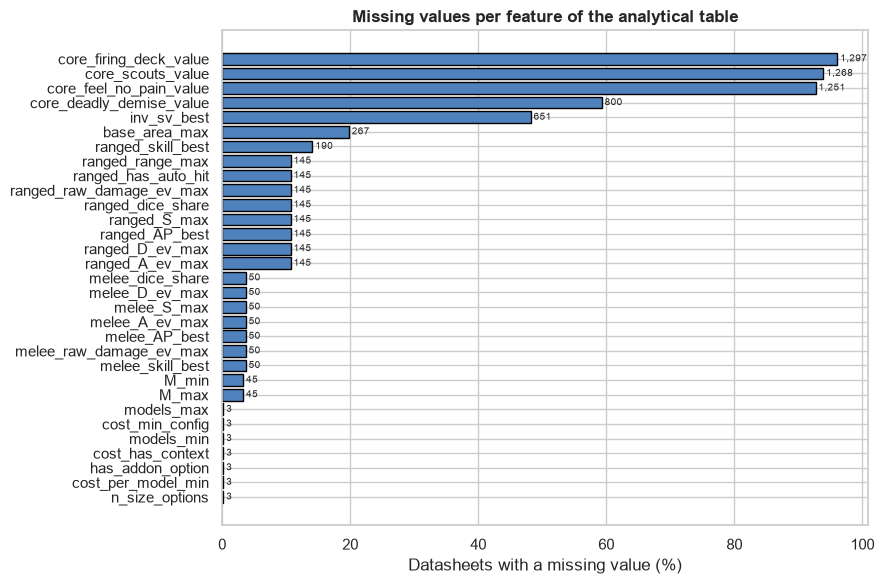

In [15]:
missing = features.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_table = pd.DataFrame({"missing": missing, "percent": (100 * missing / len(features)).round(1)})
display(missing_table)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(missing_table.index[::-1], missing_table["percent"][::-1], color=BAR_COLOR, edgecolor="black")
ax.bar_label(bars, labels=[f"{n:,}" for n in missing_table["missing"][::-1]], padding=2, fontsize=7)
ax.set_xlabel("Datasheets with a missing value (%)")
ax.set_title("Missing values per feature of the analytical table")
plt.tight_layout()
plt.show()

**Interpretation.** Most of the missing values are **structural**: the characteristic does not exist for that unit. They are not data-collection failures.
- The parameters of core abilities (59–96%) exist only when the unit has the ability.
- The invulnerable save (48%) exists only for units that have one.
- Base area (20%) is missing because hull-measured models have no base.
- The weapon features are missing for 10.7% of the datasheets (ranged) and 3.7% (melee). These are the units without weapons of that type: 126 without ranged and 31 without melee weapons, plus the 19 units without any weapon by design (6.5). Their weapon counts are 0; only the envelope (best strength, damage, …) is missing.
- Only 3 datasheets lack a points value: two Unaligned fortifications and one Imperial Knights character.

### 6.2 How `DS_Keywords` stores the roles of a unit, and repeated datasheets

`DS_Keywords` lists the roles of a unit (`Infantry`, `Vehicle`, `Fly`, …) under its `datasheet_id`. For some units the export repeats the whole block of roles. These rows are **not duplicates** in the sense of a data error: they are how the export stores the roles, and the information they carry is the **presence** of a role in a unit. The checks below show where the block is repeated and confirm that every count must be made **per unit**, not per row.

In [16]:
repeated_rows = query("""SELECT SUM(n - 1) AS repeated FROM (SELECT COUNT(*) AS n FROM raw.DS_Keywords
                         GROUP BY datasheet_id, keyword, model, is_faction_keyword)""")["repeated"].iloc[0]
print(f"DS_Keywords: {repeated_rows} rows repeat a role already listed for the same unit.")
example = query("""SELECT r.keyword, COUNT(*) AS rows FROM raw.DS_Keywords AS r
                   JOIN raw.Datasheets AS d ON d.id = r.datasheet_id
                   WHERE d.name = 'Hell Blade' AND d.faction_id = 'TS' AND r.keyword IS NOT NULL
                   GROUP BY r.keyword ORDER BY r.keyword""")
print("Example: roles of the Thousand Sons 'Hell Blade' and how many rows store each one")
display(example.set_index("keyword").T)
repeated_by_faction = query("""
    SELECT d.faction_id, SUM(k.n - 1) AS repeated_rows, COUNT(DISTINCT k.datasheet_id) AS datasheets
    FROM (SELECT datasheet_id, COUNT(*) AS n FROM raw.DS_Keywords
          GROUP BY datasheet_id, keyword, model, is_faction_keyword HAVING COUNT(*) > 1) AS k
    JOIN raw.Datasheets AS d ON d.id = k.datasheet_id
    GROUP BY d.faction_id ORDER BY repeated_rows DESC""")
display(repeated_by_faction)


def keywords_in_two_factions(source):
    """Keywords that pass the universality filter on the datasheets kept in the clean database (rows read from `source`)."""
    return set(query(f"""SELECT k.keyword FROM {source} AS k
                         JOIN datasheets AS d ON d.datasheet_id = CAST(k.datasheet_id AS INTEGER)
                         WHERE k.keyword IS NOT NULL
                         GROUP BY k.keyword HAVING COUNT(DISTINCT d.faction_id) >= {MIN_KEYWORD_FACTIONS}""")["keyword"])


all_rows = keywords_in_two_factions("raw.DS_Keywords")
one_row_per_role = keywords_in_two_factions("(SELECT DISTINCT * FROM raw.DS_Keywords)")
print(f"Universality filter on every row: {len(all_rows)} keywords; on one row per unit and role: "
      f"{len(one_row_per_role)}; same set: {all_rows == one_row_per_role}")

same_name = query("""
    SELECT d.datasheet_id, d.name, d.faction_id, s.name AS source, s.type AS source_type
    FROM datasheets AS d
    JOIN raw.Datasheets AS r ON r.id = d.datasheet_id
    LEFT JOIN raw.Sources AS s ON s.id = r.source_id
    WHERE (d.name, d.faction_id) IN (SELECT name, faction_id FROM datasheets
                                     GROUP BY name, faction_id HAVING COUNT(*) > 1)
    ORDER BY d.name, d.datasheet_id""")
print(f"Datasheets whose name is repeated inside the same faction: {len(same_name)} rows")
display(same_name)

DS_Keywords: 3843 rows repeat a role already listed for the same unit.
Example: roles of the Thousand Sons 'Hell Blade' and how many rows store each one


keyword,Aircraft,Chaos,Fly,Hell Blade,Thousand Sons,Tzeentch,Vehicle
rows,5,5,5,5,1,5,5


,faction_id,repeated_rows,datasheets
0,CD,1412,38
1,WE,619,24
2,TS,619,24
3,DG,619,24
4,CSM,478,22
5,SM,64,1
6,GC,32,2


Universality filter on every row: 137 keywords; on one row per unit and role: 137; same set: True
Datasheets whose name is repeated inside the same faction: 20 rows


,datasheet_id,name,faction_id,source,source_type
0,2705,Gladiator Lancer,SM,Space Marines,Codex
1,2787,Gladiator Lancer,SM,Black Templars,Codex Supplement
2,1667,Gladiator Reaper,SM,Space Marines,Codex
3,2789,Gladiator Reaper,SM,Black Templars,Codex Supplement
4,1825,Gladiator Valiant,SM,Space Marines,Codex
5,2788,Gladiator Valiant,SM,Black Templars,Codex Supplement
6,2568,Impulsor,SM,Space Marines,Codex
7,2786,Impulsor,SM,Black Templars,Codex Supplement
8,1104,Karanak,CD,Chaos Daemons,Index
9,4102,Karanak,CD,Legends: Legiones Daemonica,Datasheet


**Interpretation.**
- **`DS_Keywords` stores the roles of a unit, sometimes more than once.** The *Hell Blade* lists each of its roles (`Fly`, `Vehicle`, `Aircraft`, …) five times under the same `datasheet_id`. In the export, 3,843 rows repeat a role already listed for the same unit, concentrated in the Chaos factions: Chaos Daemons (1,412 rows in 38 datasheets), World Eaters, Thousand Sons and Death Guard (619 each), and Chaos Space Marines (478).
- **They all belong to the empty duplicates.** Among the datasheets kept in the clean database no role is repeated: every unit has one row per role.
- **What matters is the presence of the role.** The universality filter counts distinct factions, so it is the same on every row and on one row per unit and role (137 keywords). Any share must be computed **per unit**: Section 9.5 shows how much a count by rows differs.
- **10 pairs of datasheets share name and faction.** Nine are Space Marines units published twice, in the *Space Marines* codex and in the *Black Templars* supplement; one is *Karanak*, published both in an Index and as a Legends datasheet. They are not technical duplicates (different ids and sources, both with weapons), but they are near-copies of the same unit, so they must fall in the same validation fold. The groups of Section 9.8 take care of that.

### 6.3 Domain rules and suspicious values

Each rule states what the game allows. Violations are reported, not corrected.

In [17]:
DOMAIN_RULES = {
    "Toughness between 1 and 16": "T NOT BETWEEN 1 AND 16",
    "Wounds at least 1": "W < 1",
    "Save between 2+ and 7+": "Sv NOT BETWEEN 2 AND 7",
    "Invulnerable save between 2+ and 6+": "inv_sv NOT BETWEEN 2 AND 6",
    "Leadership between 4+ and 9+": "Ld NOT BETWEEN 4 AND 9",
    "Objective Control not negative": "OC < 0",
    "Movement between 1 and 20 inches": "M NOT BETWEEN 1 AND 20",
}
WEAPON_RULES = {
    "AP not positive": "AP > 0",
    "Skill between 2+ and 6+": "BS_WS NOT BETWEEN 2 AND 6",
    "Strength at least 1": "S_ev < 1",
    "Attacks at least 1": "A_min < 1",
    "Damage at least 1": "D_min < 1",
}
domain = []
for rule, condition in DOMAIN_RULES.items():
    domain.append({"table": "model_profiles", "rule": rule,
                   "violations": query(f"SELECT COUNT(*) AS n FROM model_profiles WHERE {condition}")["n"].iloc[0]})
for rule, condition in WEAPON_RULES.items():
    domain.append({"table": "weapon_profiles", "rule": rule,
                   "violations": query(f"SELECT COUNT(*) AS n FROM weapon_profiles WHERE {condition}")["n"].iloc[0]})
domain.append({"table": "unit_costs", "rule": "Cost positive",
               "violations": query("SELECT COUNT(*) AS n FROM unit_costs WHERE cost <= 0")["n"].iloc[0]})
print("Domain rules of the game: rows that break each rule (0 = the rule holds):")
display(pd.DataFrame(domain))

suspicious = query("""
    SELECT 'Save 7+ (cannot be rolled on a D6: no armour save)' AS observation, COUNT(*) AS profiles
    FROM model_profiles WHERE Sv = 7
    UNION ALL SELECT 'Objective Control 0', COUNT(*) FROM model_profiles WHERE OC = 0
    UNION ALL SELECT 'Movement ''-'' (immobile)', COUNT(*) FROM model_profiles WHERE M_status = 'structural'
    UNION ALL SELECT 'Movement 20+" (minimum move, aircraft)', COUNT(*) FROM model_profiles WHERE M_is_minimum = 1
    UNION ALL SELECT 'Wounds of 30 or more', COUNT(*) FROM model_profiles WHERE W >= 30""")
print("Values the game allows but that look unusual: number of model profiles:")
display(suspicious)
print("The largest models (Wounds of 30 or more), to check that they are real units:")
display(query("""SELECT d.faction_id, m.model_name, m.M_raw AS movement, m.Sv_raw AS save, m.W AS wounds,
                        m.OC AS objective_control
                 FROM model_profiles AS m JOIN datasheets AS d USING (datasheet_id)
                 WHERE m.W >= 30 ORDER BY m.W DESC LIMIT 8"""))

Domain rules of the game: rows that break each rule (0 = the rule holds):


,table,rule,violations
0,model_profiles,Toughness between 1 and 16,0
1,model_profiles,Wounds at least 1,0
2,model_profiles,Save between 2+ and 7+,0
3,model_profiles,Invulnerable save between 2+ and 6+,0
4,model_profiles,Leadership between 4+ and 9+,0
5,model_profiles,Objective Control not negative,0
6,model_profiles,Movement between 1 and 20 inches,0
7,weapon_profiles,AP not positive,0
8,weapon_profiles,Skill between 2+ and 6+,0
9,weapon_profiles,Strength at least 1,0


Values the game allows but that look unusual: number of model profiles:


,observation,profiles
0,Save 7+ (cannot be rolled on a D6: no armour save),47
1,Objective Control 0,142
2,Movement '-' (immobile),45
3,"Movement 20+"" (minimum move, aircraft)",68
4,Wounds of 30 or more,30


The largest models (Wounds of 30 or more), to check that they are real units:


,faction_id,model_name,movement,save,wounds,objective_control
0,TL,Warlord Titan,"10""",2+,100,30
1,UN,Imperial Fortress Walls,-,2+,80,0
2,TL,Warbringer Nemesis Titan,"12""",2+,80,20
3,TAU,Manta,"20+""",2+,60,0
4,TL,Reaver Titan,"12""",2+,60,20
5,AE,Phantom Titan,"14""",2+,55,20
6,NEC,Tomb Citadel Walls,-,2+,50,0
7,UN,Castellum Stronghold,-,2+,50,0


**Interpretation.**
- **No profile, weapon or cost breaks the game's domain rules.**
- Several values are suspicious but legitimate:
  - **Save 7+** (47 profiles) cannot be rolled on a six-sided die; it means "no armour save" (e.g. *Makari*, a gretchin, or the *Spore Mines*).
  - **OC 0** (142 profiles) is given to all 68 aircraft, 37 fortifications and a few support models such as servitors.
  - **Wounds of 30 or more** (30 profiles) are titans, gunships, the *Manta* and fortresses.

  They are real extremes, not errors, and they make many distributions heavily skewed (Section 7).

### 6.4 Format consistency

In [18]:
format_checks = pd.DataFrame([
    {"check": "Datasheet names with a typographic apostrophe (’)",
     "rows": query("SELECT COUNT(*) AS n FROM datasheets WHERE name LIKE '%’%'")["n"].iloc[0]},
    {"check": "Weapon names with a typographic apostrophe (’)",
     "rows": query("SELECT COUNT(*) AS n FROM weapon_profiles WHERE weapon_name LIKE '%’%'")["n"].iloc[0]},
    {"check": "Damaged descriptions with a non-breaking hyphen (U+2011)",
     "rows": query("SELECT COUNT(*) AS n FROM raw.Datasheets WHERE damaged_description LIKE '%‑%'")["n"].iloc[0]},
    {"check": "Unit composition lines with a non-breaking hyphen (U+2011)",
     "rows": query("SELECT COUNT(*) AS n FROM raw.DS_Unit_Comp WHERE description LIKE '%‑%'")["n"].iloc[0]},
    {"check": "Keyword rows with an empty keyword (all flagged as faction keyword)",
     "rows": query("SELECT COUNT(*) AS n FROM raw.DS_Keywords WHERE keyword IS NULL")["n"].iloc[0]},
    {"check": "Weapon BS/WS written as '3+' instead of '3'",
     "rows": query("SELECT COUNT(*) AS n FROM weapon_profiles WHERE BS_WS_raw LIKE '%+'")["n"].iloc[0]},
    {"check": "Ranged weapons with range 'N/A'",
     "rows": query("SELECT COUNT(*) AS n FROM weapon_profiles WHERE range_raw = 'N/A'")["n"].iloc[0]},
])
display(format_checks)
print("DS_Abilities.type labels (some are left in Russian by the export):")
display(query("SELECT type, COUNT(*) AS rows FROM raw.DS_Abilities GROUP BY type ORDER BY rows DESC"))
print("Keywords whose spelling differs only in case or plural form:")
keyword_names = query("""SELECT DISTINCT keyword FROM raw.DS_Keywords
                          WHERE is_faction_keyword = 'FALSE' AND keyword IS NOT NULL""")["keyword"]
normalised = keyword_names.str.lower().str.rstrip("s")
display(keyword_names[normalised.duplicated(keep=False)].sort_values().to_frame().T)

,check,rows
0,Datasheet names with a typographic apostrophe (’),24
1,Weapon names with a typographic apostrophe (’),145
2,Damaged descriptions with a non-breaking hyphen (U+2011),10
3,Unit composition lines with a non-breaking hyphen (U+2011),11
4,Keyword rows with an empty keyword (all flagged as facti...,300
5,Weapon BS/WS written as '3+' instead of '3',2
6,Ranged weapons with range 'N/A',1


DS_Abilities.type labels (some are left in Russian by the export):


,type,rows
0,Datasheet,2444
1,Core,1969
2,Faction,1407
3,Wargear,387
4,Wargear profile,230
5,Special (правая колонка),153
6,Fortification (левая колонка),86
7,Primarch,67
8,Без заголовка,1


Keywords whose spelling differs only in case or plural form:


,374,397,296,191,303,290,206,612,1279,730,389,387
keyword,Aspect Warrior,Aspect Warriors,Beast,Beasts,Burrower,Burrowers,Crusader,Crusaders,Hellflayer,Hellflayers,Warlock,Warlocks


**Interpretation.**
- The text fields mix typographic characters (`’` in 24 unit names and 145 weapon names, the non-breaking hyphen U+2011 in 21 descriptions). Grouping by name (9.8) and reading the damaged ranges (10.4) normalise them; without that, `T’au` and `T'au` would be two different strings.
- `DS_Abilities.type` contains three labels left in Russian by the exporter: "Special (right column)", "Fortification (left column)" and "untitled". They are layout labels and do not affect the `Core` filter.
- **Six keyword pairs differ only by a plural** (`Beast`/`Beasts`, `Warlock`/`Warlocks`, …). If keywords are used as features, these pairs should be merged so that the same rule concept is not split into two sparse columns.
- 2 weapons write the skill as `3+` instead of `3`, and one ranged weapon has range `N/A`. The parsers handle both.

### 6.5 Datasheets without weapon profiles: units without weapons or empty duplicates?

In the export, 304 datasheets with a model profile have no row in `DS_Wargear`. Before treating that as "the unit has no weapons", each one is checked in two ways:

1. **Is the unit duplicated, and does its duplicate have weapons?** A duplicate is another datasheet with the same name (case and spaces ignored). It counts as the same unit only if its model profile (Movement, Toughness, Save, invulnerable save, Wounds, Leadership, OC and base, profile by profile) is identical. Such **empty duplicates** were not loaded into the clean database (4.6). The first part of the code shows them.
2. **Is the unit, by its nature, a unit without weapons?** The game has such units, and they are recognised by their rules:
   - **buildings and fortifications**: keyword `Fortification`;
   - **deployment capsules**: ability *Drop Pod Assault*;
   - **explosive units** that act by blowing up (living mines, demolition vehicles): abilities *Floating Death* / *Bio-minefield* (Spore Mines) or *Demolition Charges* / *Unstable Payload* (Cyclops).

   The second part checks that **every datasheet left without weapons** in the clean database is one of them.

In [19]:
NATURE_RULES = [  # (nature, source of the evidence, values that identify it)
    ("building / fortification", "keyword", {"Fortification"}),
    ("deployment capsule (drop pod)", "ability", {"Drop Pod Assault"}),
    ("explosive unit (living mine, demolition vehicle)", "ability",
     {"Floating Death", "Bio-minefield", "Demolition Charges", "Unstable Payload"}),
]
unit_keywords = query("""SELECT DISTINCT CAST(datasheet_id AS INTEGER) AS datasheet_id, keyword FROM raw.DS_Keywords
                         WHERE keyword IS NOT NULL""").groupby("datasheet_id")["keyword"].agg(set)
unit_abilities = query("""SELECT DISTINCT CAST(d.datasheet_id AS INTEGER) AS datasheet_id, COALESCE(a.name, d.name) AS ability
                          FROM raw.DS_Abilities AS d LEFT JOIN (SELECT DISTINCT id, name FROM raw.Abilities) AS a
                          ON a.id = d.ability_id""").groupby("datasheet_id")["ability"].agg(set)


def unit_nature(datasheet_id):
    """Nature of a unit without weapons and the rule that shows it, or (None, None)."""
    for nature, source, values in NATURE_RULES:
        found = (unit_keywords if source == "keyword" else unit_abilities).get(datasheet_id, set()) & values
        if found:
            return nature, f"{source}: {', '.join(sorted(found))}"
    return None, None


# --- 1) empty duplicates, not loaded into the clean database (4.6)
removed = removed_duplicates.copy()
removed.index = removed.index.astype(int)
removed["nature"] = [unit_nature(datasheet_id)[0] for datasheet_id in removed.index]
print(f"Empty duplicates not loaded into the clean database: {len(removed)} datasheets")
display(removed.groupby("faction_id").agg(datasheets=("name", "size"),
                                          weapons_stored_in=("weapons_stored_in", lambda s: ", ".join(sorted(set(", ".join(s).split(", ")))))
        ).sort_values("datasheets", ascending=False).T)
print("Empty duplicates whose nature alone would suggest a unit without weapons (their duplicate does have weapons):")
display(removed[removed["nature"].notna()][["name", "faction_id", "nature", "weapons_stored_in"]])

# --- 2) datasheets left without weapons in the clean database
loadout = query("SELECT CAST(id AS INTEGER) AS datasheet_id, loadout FROM raw.Datasheets").set_index("datasheet_id")["loadout"]
name_key = features["name"].str.lower().str.strip()
checks = []
for datasheet_id, unit in features[features["has_wargear"] == 0].iterrows():
    duplicates = features[(name_key == name_key[datasheet_id]) & (features.index != datasheet_id)]
    nature, evidence = unit_nature(datasheet_id)
    text = loadout.get(datasheet_id)
    checks.append({
        "datasheet_id": datasheet_id, "name": unit["name"], "faction_id": unit["faction_id"],
        "nature": nature, "evidence": evidence,
        "duplicates": len(duplicates), "duplicates_with_weapons": int((duplicates["has_wargear"] == 1).sum()),
        "loadout_says_nothing": int(pd.isna(text) or "nothing" in text or text.strip() == "-"),
    })
no_weapons = pd.DataFrame(checks).set_index("datasheet_id")
no_weapons["verdict"] = np.where(no_weapons["nature"].notna() & (no_weapons["duplicates_with_weapons"] == 0),
                                 "no weapons by design", "unexplained")
if (no_weapons["verdict"] == "unexplained").any():
    raise ValueError("Some datasheets without weapons are not units without weapons by design.")
no_weapon_verdict = no_weapons["verdict"]
print(f"Datasheets left without weapon profiles: {len(no_weapons)}; all of them are units without weapons by design.")
display(no_weapons[["name", "faction_id", "nature", "evidence", "duplicates", "loadout_says_nothing"]]
        .sort_values(["nature", "name"]))

Empty duplicates not loaded into the clean database: 285 datasheets


faction_id,GC,CD,DG,WE,CSM,TS,QT,DRU,QI,SM
datasheets,101,38,30,28,26,26,17,13,5,1
weapons_stored_in,"AM, TYR","CSM, TS","AdM, CSM, SM","AdM, CSM, SM","AdM, DG, EC, SM, TS, WE","AdM, CSM, SM",CSM,AE,AdM,AoI


Empty duplicates whose nature alone would suggest a unit without weapons (their duplicate does have weapons):


,name,faction_id,nature,weapons_stored_in
3956,Earthshaker Platform,GC,building / fortification,AM
3957,Hydra Platform,GC,building / fortification,AM
3958,Manticore Platform,GC,building / fortification,AM
3959,Sabre Weapons Battery,GC,building / fortification,AM


Datasheets left without weapon profiles: 19; all of them are units without weapons by design.


,name,faction_id,nature,evidence,duplicates,loadout_says_nothing
datasheet_id,,,,,,
2619,Aegis Defence Line,AM,building / fortification,keyword: Fortification,1,1
3955,Aegis Defence Line,GC,building / fortification,keyword: Fortification,1,1
2068,Battle Sanctum,AS,building / fortification,keyword: Fortification,0,1
1470,Feculent Gnarlmaw,CD,building / fortification,keyword: Fortification,0,1
1545,Mekboy Workshop,ORK,building / fortification,keyword: Fortification,0,1
458,Remote Sensor Tower,TAU,building / fortification,keyword: Fortification,0,1
1588,Skull Altar,CD,building / fortification,keyword: Fortification,0,1
923,Skyshield Landing Pad,UN,building / fortification,keyword: Fortification,0,1
436,Tidewall Shieldline,TAU,building / fortification,keyword: Fortification,0,0


**Interpretation: the 285 empty duplicates were noise; the 19 datasheets left without weapons are units without weapons by design.**
- **The empty duplicates (not loaded, 4.6).** Each one has a duplicate with the same name and an **identical model profile** that does have weapon profiles. Wahapedia stores the weapons only on one copy of a shared unit; the other copies have none. Examples:
  - 101 Genestealer Cults datasheets (*Chimera*, *Catachan Jungle Fighters*, …), whose weapons are stored on the Astra Militarum or Tyranids copy;
  - 110 datasheets of the Chaos legions (Death Guard, World Eaters, Thousand Sons, Chaos Space Marines), whose weapons are stored on the copy of Chaos Space Marines, another legion, the Space Marines or the Adeptus Mechanicus;
  - 38 Chaos Daemons units (weapons on the Chaos Space Marines or Thousand Sons copy), and smaller sets in the Knights, Drukhari and Inquisition.

  An empty copy describes the same unit as its duplicate, without weapons and under another label, so it only adds noise. **4 fortifications** were among them: *Earthshaker Platform*, *Hydra Platform*, *Manticore Platform* and *Sabre Weapons Battery* (Genestealer Cults) are gun emplacements whose duplicates have weapons. Their nature alone would have marked them, wrongly, as units without weapons.
- **The 19 datasheets left without weapons** all match a rule of the game:
  - **13 buildings and fortifications** (*Aegis Defence Line*, *Void Shield Generator*, *Webway Gate*, *Skull Altar*, …);
  - **2 drop pods** (*Drop Pod*, *Dreadnought Drop Pod*);
  - **4 explosive units**: *Spore Mines* and *Mucolid Spores* (living mines) and the *Cyclops Demolition Vehicle* of the Astra Militarum and the Genestealer Cults.

  18 of them have a `loadout` that says "equipped with: nothing" or is empty; the *Tidewall Shieldline* only offers an optional defence platform. Four of them are duplicated (*Aegis Defence Line* and *Cyclops* in AM and GC), but the duplicate has no weapons either.
- **Consequences.**
  - The weapon counts of these 19 units are a true **0**; their weapon envelopes are structurally missing.
  - `has_wargear` no longer measures how the export was built. It marks only these 19 units and is equal to "ranged and melee counts both 0", so it stays out of `X` as redundant.

### 6.6 Taxonomy of missing and special values

A missing value is not one thing. The table classifies, for the parsed characteristics, **why** a value is absent, because each cause needs a different treatment in Data Preparation (and none of them is "impute 0").

In [20]:
taxonomy = pd.DataFrame([
    {"variable": "Movement (M)", "cause": "structural: '-' (immobile model, e.g. fortifications)",
     "rows": query("SELECT COUNT(*) AS n FROM model_profiles WHERE M_status = 'structural'")["n"].iloc[0],
     "treatment": "indicator M_immobile; never 0 inches by imputation"},
    {"variable": "Movement (M)", "cause": "special value: '20+\"' (minimum move of aircraft)",
     "rows": query("SELECT COUNT(*) AS n FROM model_profiles WHERE M_is_minimum = 1")["n"].iloc[0],
     "treatment": "value 20 + indicator M_is_minimum"},
    {"variable": "Invulnerable save", "cause": "structural: '-' (the model has none)",
     "rows": query("SELECT COUNT(*) AS n FROM model_profiles WHERE inv_sv_status = 'structural'")["n"].iloc[0],
     "treatment": "indicator has_inv_sv; value left missing (not 0, not 7)"},
    {"variable": "Invulnerable save / Toughness", "cause": "special value: '*' (conditional rule)",
     "rows": query("""SELECT SUM(inv_sv_has_rule) + SUM(T_has_rule) AS n FROM model_profiles""")["n"].iloc[0],
     "treatment": "keep the number + flag"},
    {"variable": "Weapon skill (BS/WS)", "cause": "not applicable: 'N/A' (weapon hits automatically)",
     "rows": query("SELECT COUNT(*) AS n FROM weapon_profiles WHERE BS_WS_status = 'not_applicable'")["n"].iloc[0],
     "treatment": "indicator ranged_has_auto_hit"},
    {"variable": "Range", "cause": "not applicable: melee weapon",
     "rows": query("SELECT COUNT(*) AS n FROM weapon_profiles WHERE weapon_type = 'Melee'")["n"].iloc[0],
     "treatment": "range features computed on ranged weapons only"},
    {"variable": "Attacks / Damage / Strength", "cause": "dice expression (a direct numeric cast would make it missing)",
     "rows": query("""SELECT SUM(A_status = 'dice') + SUM(D_status = 'dice') + SUM(S_status = 'dice') AS n
                      FROM weapon_profiles""")["n"].iloc[0],
     "treatment": "expected value, minimum and maximum"},
    {"variable": "All weapon features", "cause": "structural: unit without weapons by design (fortification, drop pod, explosive unit; 6.5)",
     "rows": int((no_weapon_verdict == "no weapons by design").sum()),
     "treatment": "weapon counts = 0; weapon envelope missing"},
    {"variable": "Ranged / melee features", "cause": "structural: datasheet without weapons of that type",
     "rows": int(((features["ranged_n_profiles"] == 0) & (features["has_wargear"] == 1)).sum()
                 + ((features["melee_n_profiles"] == 0) & (features["has_wargear"] == 1)).sum()),
     "treatment": "count = 0; envelope missing"},
    {"variable": "Base area", "cause": "structural: 'Use model' (measured to the hull) or no official base",
     "rows": query("SELECT COUNT(*) AS n FROM model_profiles WHERE base_kind IN ('hull', 'no_official_base')")["n"].iloc[0],
     "treatment": "indicator has_hull; area missing"},
    {"variable": "Base area", "cause": "missing: empty cell in the export",
     "rows": query("SELECT COUNT(*) AS n FROM model_profiles WHERE base_kind = 'missing'")["n"].iloc[0],
     "treatment": "true missing value: impute inside the pipeline"},
    {"variable": "Costs", "cause": "missing: datasheet without a points value",
     "rows": int(features["cost_min_config"].isna().sum()),
     "treatment": "true missing value"},
    {"variable": "Role", "cause": "missing: empty cell",
     "rows": int((features["role"] == "Unknown").sum()), "treatment": "category 'Unknown'"},
    {"variable": "Any parsed characteristic", "cause": "parsing failure",
     "rows": 0, "treatment": "the build stops if any appears (4.5)"},
])
display(taxonomy)

,variable,cause,rows,treatment
0,Movement (M),"structural: '-' (immobile model, e.g. fortifications)",45,indicator M_immobile; never 0 inches by imputation
1,Movement (M),"special value: '20+""' (minimum move of aircraft)",68,value 20 + indicator M_is_minimum
2,Invulnerable save,structural: '-' (the model has none),691,"indicator has_inv_sv; value left missing (not 0, not 7)"
3,Invulnerable save / Toughness,special value: '*' (conditional rule),3,keep the number + flag
4,Weapon skill (BS/WS),not applicable: 'N/A' (weapon hits automatically),413,indicator ranged_has_auto_hit
5,Range,not applicable: melee weapon,2230,range features computed on ranged weapons only
6,Attacks / Damage / Strength,dice expression (a direct numeric cast would make it mis...,2178,"expected value, minimum and maximum"
7,All weapon features,structural: unit without weapons by design (fortificatio...,19,weapon counts = 0; weapon envelope missing
8,Ranged / melee features,structural: datasheet without weapons of that type,157,count = 0; envelope missing
9,Base area,structural: 'Use model' (measured to the hull) or no off...,262,indicator has_hull; area missing


**Interpretation.** Each cause leads to a different treatment, and none of them is "impute 0":
- **Structural** absences (no invulnerable save, immobile, no ranged weapon, a unit without weapons by design) carry information. They become explicit indicators or counts of 0, and the value stays missing; in the game, "no invulnerable save" is not the same as "invulnerable save 0+".
- **Not applicable** values (`N/A` skill, melee range) are excluded from the statistic they would distort.
- **Special values** (`20+"`, `5*`) keep the number plus a flag.
- **True missing values** are few (9 base sizes, 3 costs) and can be imputed inside the pipeline.

## 7. Univariate analysis

### 7.1 Model characteristics (one observation per model profile)

Summary of each characteristic over the model profiles (count = profiles where it exists):


,count,mean,std,min,25%,50%,75%,max
Movement,1380.000,9.021,3.740,3.000,6.000,8.000,12.000,20.000
Toughness,1425.000,6.606,3.160,1.000,4.000,6.000,9.000,16.000
Save,1425.000,3.399,1.305,2.000,2.000,3.000,4.000,7.000
Invulnerable save,734.000,4.606,0.719,2.000,4.000,4.000,5.000,6.000
Wounds,1425.000,8.127,8.169,1.000,3.000,5.000,11.000,100.000
Leadership,1425.000,6.511,0.642,5.000,6.000,6.000,7.000,8.000
Objective Control,1425.000,2.260,2.473,0.000,1.000,1.000,3.000,30.000


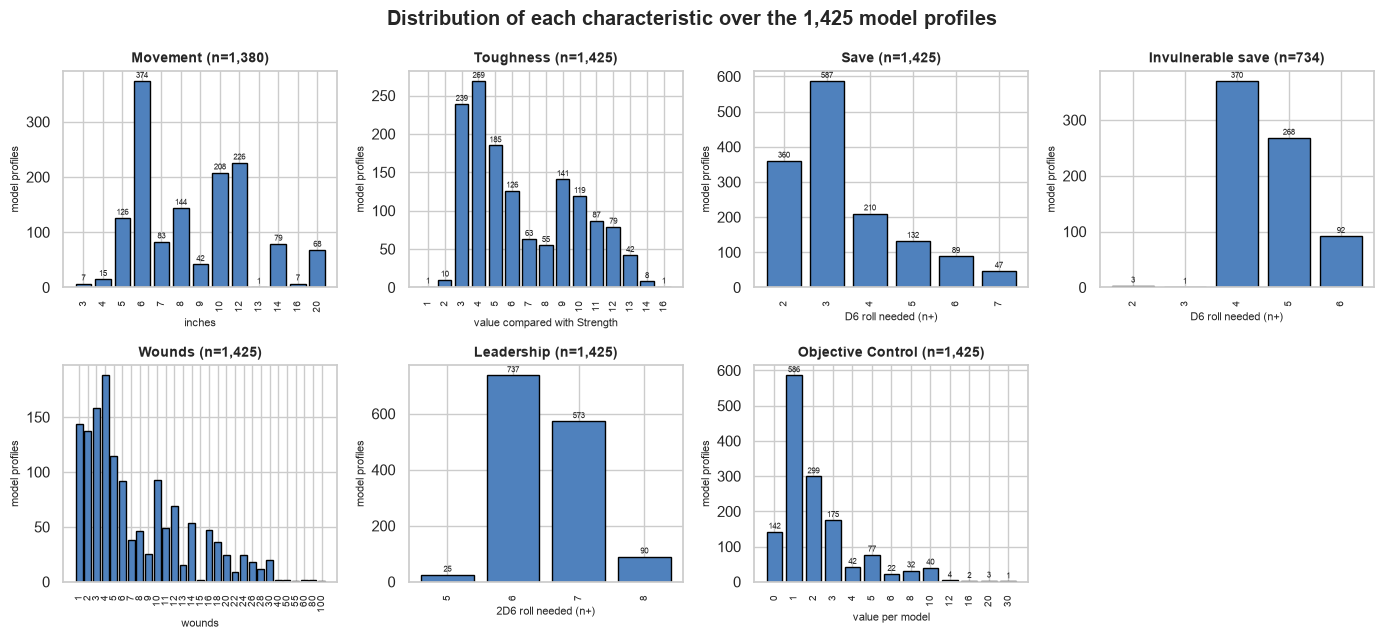

In [21]:
profile_columns = ["M", "T", "Sv", "inv_sv", "W", "Ld", "OC"]
PROFILE_UNITS = {"M": "inches", "T": "value compared with Strength", "Sv": "D6 roll needed (n+)",
                 "inv_sv": "D6 roll needed (n+)", "W": "wounds", "Ld": "2D6 roll needed (n+)",
                 "OC": "value per model"}
print("Summary of each characteristic over the model profiles (count = profiles where it exists):")
display(profiles[profile_columns].describe().T.rename(index=STAT_NAMES))

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for ax, column in zip(axes.ravel(), profile_columns):
    counts = profiles[column].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(int).astype(str), counts.values, color=BAR_COLOR, edgecolor="black")
    if len(counts) <= 15:
        ax.bar_label(bars, fontsize=6, padding=1)
    ax.set_title(f"{STAT_NAMES[column]} (n={profiles[column].notna().sum():,})", fontsize=10)
    ax.set_xlabel(PROFILE_UNITS[column], fontsize=8)
    ax.set_ylabel("model profiles", fontsize=8)
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle(f"Distribution of each characteristic over the {len(profiles):,} model profiles", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation (profile level).**
- **What is not plotted.** Each panel counts only the profiles where the characteristic exists (the `n` of its title): Movement leaves out the 45 immobile models and the invulnerable save the 691 profiles without one. These are structural absences (6.6), not missing data.
- **Movement** clusters at 6" (infantry), 10–12" (bikes, vehicles, jump troops) and 20"+ (aircraft).
- **Toughness** is bimodal: 3–5 for infantry and 9–12 for vehicles and monsters.
- **Wounds** is extremely skewed: the median is 5, but titans reach 100. A log scale or rank-based methods will be needed.
- **Save** 3+ is the most common value. Only 734 of 1,425 profiles have an invulnerable save, mostly 4+ or 5+.
- **Leadership** takes only four values (5+ to 8+), almost all 6+ or 7+. **OC** is usually 1–2.
- These are the published *profiles*. Section 9 moves to the datasheet level, where every datasheet counts once.

### 7.2 Weapon profiles

,profiles,datasheets,A_ev_median,S_median,AP_median,D_ev_median,attacks_with_dice,damage_with_dice
weapon_type,,,,,,,,
Melee,2230,1301,4.000,6.000,-1.000,1.000,0.005,0.057
Ranged,4422,1206,2.000,6.000,-1.000,2.000,0.251,0.209


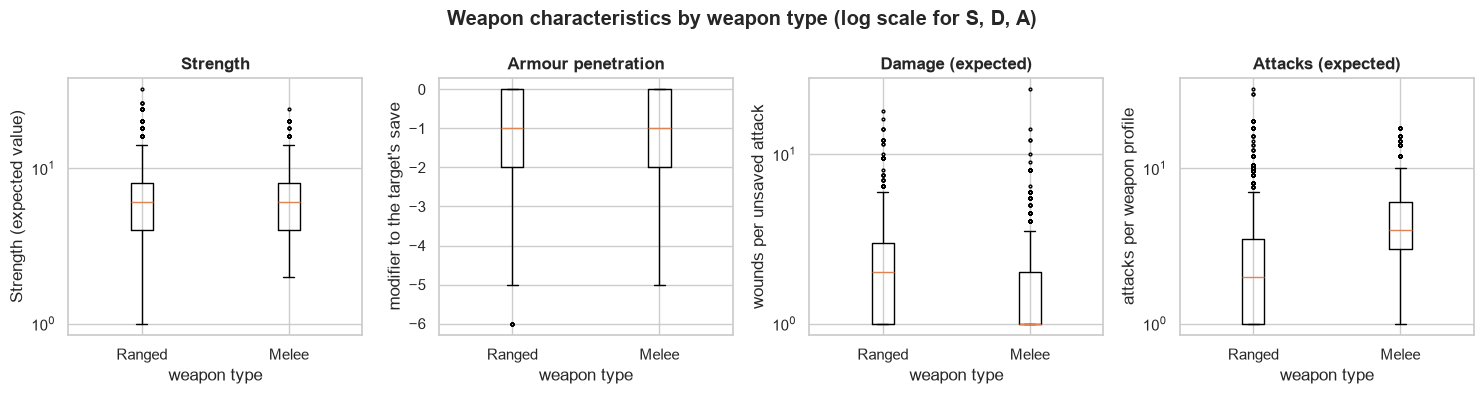

In [22]:
weapon_summary = weapons.groupby("weapon_type").agg(
    profiles=("line", "size"), datasheets=("datasheet_id", "nunique"),
    A_ev_median=("A_ev", "median"), S_median=("S_ev", "median"), AP_median=("AP", "median"),
    D_ev_median=("D_ev", "median"), attacks_with_dice=("A_status", lambda s: (s == "dice").mean()),
    damage_with_dice=("D_status", lambda s: (s == "dice").mean()))
display(weapon_summary)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (column, label, unit) in zip(axes, [("S_ev", "Strength", "Strength (expected value)"),
                                            ("AP", "Armour penetration", "modifier to the target's save"),
                                            ("D_ev", "Damage (expected)", "wounds per unsaved attack"),
                                            ("A_ev", "Attacks (expected)", "attacks per weapon profile")]):
    data = [weapons.loc[weapons["weapon_type"] == kind, column].dropna() for kind in ["Ranged", "Melee"]]
    ax.boxplot(data, tick_labels=["Ranged", "Melee"], showfliers=True, flierprops={"markersize": 2})
    ax.set_title(label)
    ax.set_xlabel("weapon type")
    ax.set_ylabel(unit)
    if column in ("S_ev", "A_ev", "D_ev"):
        ax.set_yscale("log")
fig.suptitle("Weapon characteristics by weapon type (log scale for S, D, A)", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Shape of the profiles.** There are 4,422 ranged and 2,230 melee profiles. Ranged profiles have few attacks (median 2) and higher damage (median 2). Melee profiles have more attacks (median 4) and damage 1. AP is −1 in the median profile of both types.
- **Dice are concentrated in ranged weapons**: 25% of ranged Attacks and 21% of ranged Damage values are dice expressions, against 0.5% and 6% in melee. Dropping dice expressions would therefore lose information selectively, mainly from shooting weapons. Section 10.3 measures the effect.
- **Weapon lists are not loadouts.** The lists mix weapons that are carried together, alternatives and optional upgrades. That is why the datasheet-level features use the strongest profile of each type and the number of profiles, not means.

### 7.3 Points cost and unit size

,count,mean,std,min,25%,50%,75%,max
cost_min_config,1347.000,150.293,190.995,20.000,75.000,100.000,165.000,3500.000
models_min,1347.000,2.206,2.367,1.000,1.000,1.000,3.000,16.000
models_max,1347.000,3.139,3.932,1.000,1.000,1.000,4.000,22.000
n_size_options,1347.000,1.252,0.526,1.000,1.000,1.000,1.000,4.000
cost_per_model_min,1347.000,128.192,198.381,3.636,36.667,80.000,150.000,3500.000


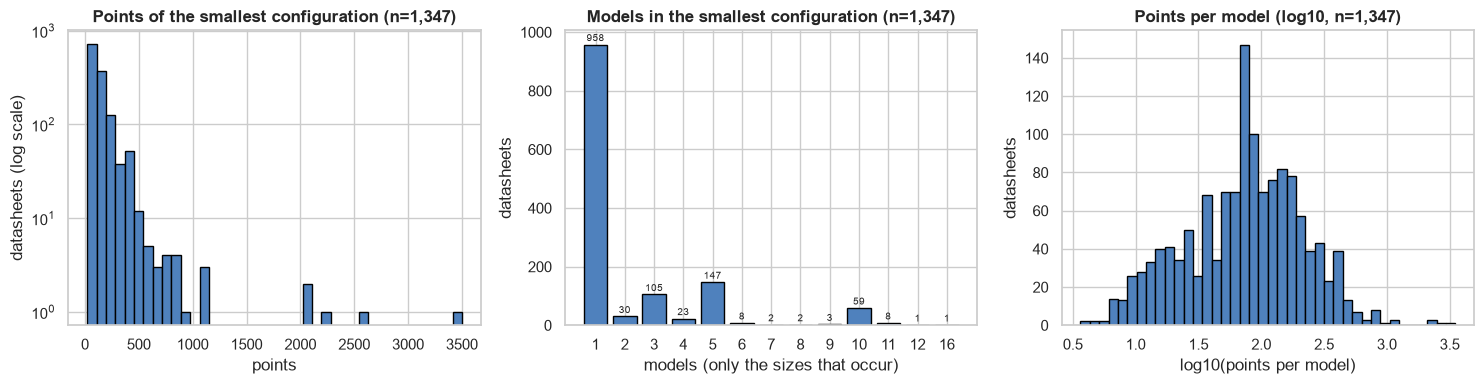

In [23]:
display(features[["cost_min_config", "models_min", "models_max", "n_size_options", "cost_per_model_min"]].describe().T)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
costed = features["cost_min_config"].dropna()
axes[0].hist(costed, bins=40, color=BAR_COLOR, edgecolor="black")
axes[0].set_yscale("log")
axes[0].set_title(f"Points of the smallest configuration (n={len(costed):,})")
axes[0].set_xlabel("points")
axes[0].set_ylabel("datasheets (log scale)")
size_counts = features["models_min"].value_counts().sort_index()
size_bars = axes[1].bar(size_counts.index.astype(int).astype(str), size_counts.values, color=BAR_COLOR, edgecolor="black")
axes[1].bar_label(size_bars, fontsize=7, padding=1)
axes[1].set_title(f"Models in the smallest configuration (n={size_counts.sum():,})")
axes[1].set_xlabel("models (only the sizes that occur)")
axes[1].set_ylabel("datasheets")
axes[2].hist(np.log10(features["cost_per_model_min"].dropna()), bins=40, color=BAR_COLOR, edgecolor="black")
axes[2].set_title(f"Points per model (log10, n={features['cost_per_model_min'].notna().sum():,})")
axes[2].set_xlabel("log10(points per model)")
axes[2].set_ylabel("datasheets")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Points.** The smallest legal configuration costs a median of **100 points** (IQR 75–165). A few titans cost thousands (maximum 3,500).
- **Unit size.** **71%** of datasheets (958) start at a single model; the rest are squads of 3, 5 or 10.
- **Points per model** span three orders of magnitude, from about 4 for a horde model to 3,500 for a titan, and are roughly log-normal. The log scale is the natural one for modelling.
- **Size options.** 78% of datasheets have a single size option; the others offer 2–4 sizes. Each of those sizes is a real unit with a real price, which is why a mean price is meaningless (10.2).

### 7.4 Keywords and core abilities

Non-faction keywords: 1305; present in a single faction: 1170 (89.7%)
Present in >= 2 factions: 135 keywords
Most frequent non-faction keywords:


keyword,Infantry,Imperium,Character,Vehicle,Grenades,Chaos,Fly,Smoke,Epic Hero,Walker,Daemon,Transport,Psyker,Aeldari,Mounted
datasheets,625,608,483,476,341,292,282,186,179,147,141,135,120,118,107
factions,23,10,24,24,17,7,20,17,22,20,8,21,15,2,19


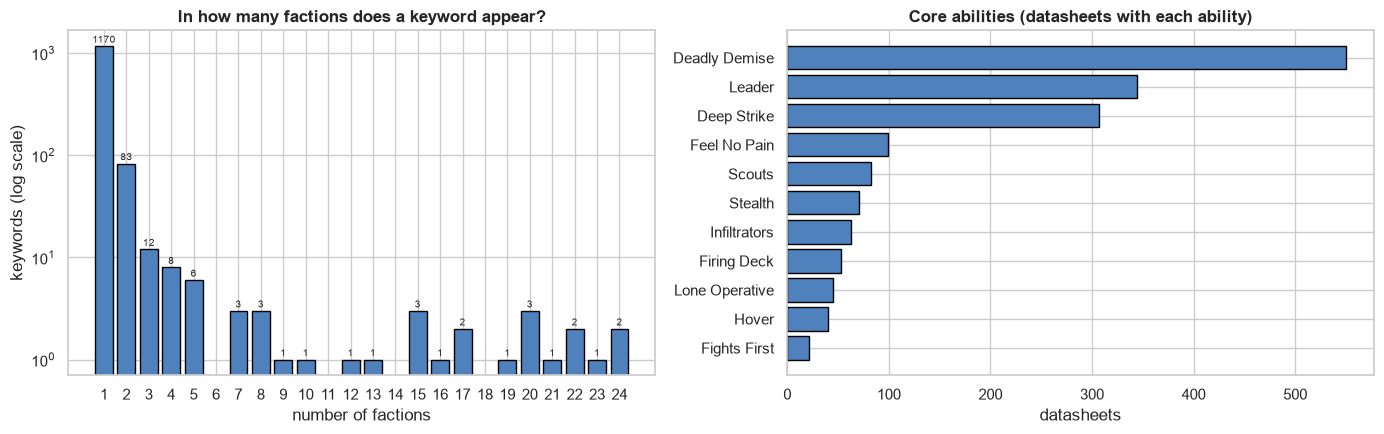

In [24]:
# full vocabulary, before the universality filter: raw keywords of the datasheets kept in the clean database
keyword_spread = query("""
    SELECT k.keyword, COUNT(DISTINCT k.datasheet_id) AS datasheets, COUNT(DISTINCT d.faction_id) AS factions
    FROM raw.DS_Keywords AS k JOIN datasheets AS d ON d.datasheet_id = CAST(k.datasheet_id AS INTEGER)
    WHERE k.is_faction_keyword = 'FALSE' AND k.keyword IS NOT NULL
    GROUP BY k.keyword""")
print(f"Non-faction keywords: {len(keyword_spread)}; present in a single faction: "
      f"{(keyword_spread['factions'] == 1).sum()} ({(keyword_spread['factions'] == 1).mean():.1%})")
print(f"Present in >= {MIN_KEYWORD_FACTIONS} factions: {(keyword_spread['factions'] >= MIN_KEYWORD_FACTIONS).sum()} keywords")
print("Most frequent non-faction keywords:")
display(keyword_spread.sort_values("datasheets", ascending=False).head(15).set_index("keyword").T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
spread_counts = keyword_spread["factions"].value_counts().sort_index()
spread_bars = axes[0].bar(spread_counts.index, spread_counts.values, color=BAR_COLOR, edgecolor="black")
axes[0].bar_label(spread_bars, fontsize=7, padding=1)
axes[0].set_yscale("log")
axes[0].set_xticks(range(1, int(spread_counts.index.max()) + 1))
axes[0].set_title("In how many factions does a keyword appear?")
axes[0].set_xlabel("number of factions")
axes[0].set_ylabel("keywords (log scale)")
ability_counts = core["ability_name"].value_counts()
axes[1].barh(ability_counts.index[::-1], ability_counts.values[::-1], color=BAR_COLOR, edgecolor="black")
axes[1].set_title("Core abilities (datasheets with each ability)")
axes[1].set_xlabel("datasheets")
plt.tight_layout()
plt.show()

**Interpretation.**
- Of 1,305 keywords that are **not** flagged as faction keywords, **1,170 (89.7%) appear in a single faction**. Most of them are unit names in disguise (`Warboss`, `Ghazghkull Thraka`). This is the problem the universality filter addresses: the clean `DS_Keywords` keeps only the keywords present in at least two factions (4.6).
- The most common keywords are true rule categories: `Infantry` (625 datasheets, 23 factions), `Character`, `Vehicle`, `Grenades`, `Fly`.
- `Imperium` (608 datasheets, 10 factions) and `Chaos` (292, 7 factions) are not flagged as faction keywords, but they **name the alliance** a faction belongs to. They would pass a "present in ≥ 2 factions" filter while still splitting the target space into Imperium / Chaos / Xenos. They must be treated as allegiance labels, not as mechanics (10.8).
- **Core abilities.** *Deadly Demise* (550 datasheets, mostly vehicles that explode) and *Leader* (344) are the most frequent; *Fights First* is the rarest (21).

### 7.5 Battlefield role and bases

In [25]:
display(features["role"].value_counts().rename("datasheets").to_frame().T)
display(query("SELECT base_kind, is_flying_base, COUNT(*) AS profiles FROM model_profiles "
              "GROUP BY base_kind, is_flying_base ORDER BY profiles DESC"))

role,Other,Characters,Battleline,Dedicated Transports,Fortifications
datasheets,722,483,62,42,41


,base_kind,is_flying_base,profiles
0,round,0,877
1,hull,0,259
2,oval,0,164
3,oval,1,57
4,round,1,56
5,missing,0,9
6,no_official_base,0,3


**Interpretation.**
- **Role.** `Other` covers 53% of the datasheets, so the role mainly separates characters, battleline units, transports and fortifications from "everything else". It is a coarse feature.
- **Bases.** 259 profiles have no base (`Use model`: vehicles measured to the hull). 113 use a flying base, which is a physical property of the miniature and is related but not equal to the `Fly` rule (9.6).

## 8. Target variable: `faction_id`

faction_id,SM,AM,AE,ORK,CSM,CD,TAU,NEC,TYR,AoI,DG,AdM,AS,GC,TS,AC,WE,GK,DRU,EC,QI,LoV,QT,UN,TL
faction_name,Space Marines,Astra Militarum,Aeldari,Orks,Chaos Space Marines,Chaos Daemons,T’au Empire,Necrons,Tyranids,Imperial Agents,Death Guard,Adeptus Mechanicus,Adepta Sororitas,Genestealer Cults,Thousand Sons,Adeptus Custodes,World Eaters,Grey Knights,Drukhari,Emperor’s Children,Imperial Knights,Leagues of Votann,Chaos Knights,Unaligned Forces,Adeptus Titanicus
datasheets,269,128,93,87,81,68,62,60,55,43,37,36,36,35,34,31,30,29,27,22,22,21,20,20,4
share,0.199,0.095,0.069,0.064,0.060,0.050,0.046,0.044,0.041,0.032,0.027,0.027,0.027,0.026,0.025,0.023,0.022,0.021,0.020,0.016,0.016,0.016,0.015,0.015,0.003


Classes: 25 | imbalance ratio (largest / smallest): 269 / 4 = 67.2
Majority-class baseline (SM): accuracy = 0.199, macro F1 = 0.013, balanced accuracy = 0.040


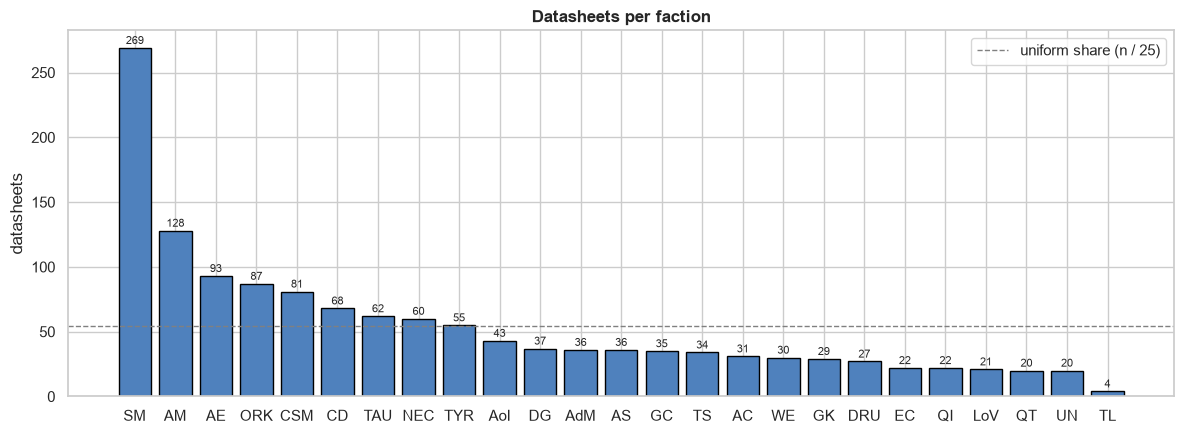

In [26]:
target_counts = features["faction_id"].value_counts()
target_table = pd.DataFrame({"faction_name": features.groupby("faction_id")["faction_name"].first(),
                             "datasheets": target_counts})
target_table["share"] = target_table["datasheets"] / target_table["datasheets"].sum()
target_table = target_table.sort_values("datasheets", ascending=False)
display(target_table.T)

majority = target_table.index[0]
majority_share = target_table["share"].iloc[0]
# Majority baseline: precision = majority share, recall = 1 for the majority class, 0 elsewhere
majority_f1 = 2 * majority_share / (1 + majority_share)
print(f"Classes: {len(target_table)} | imbalance ratio (largest / smallest): "
      f"{target_table['datasheets'].max()} / {target_table['datasheets'].min()} = "
      f"{target_table['datasheets'].max() / target_table['datasheets'].min():.1f}")
print(f"Majority-class baseline ({majority}): accuracy = {majority_share:.3f}, "
      f"macro F1 = {majority_f1 / len(target_table):.3f}, balanced accuracy = {1 / len(target_table):.3f}")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(target_table.index, target_table["datasheets"], color=BAR_COLOR, edgecolor="black")
ax.axhline(len(features) / len(target_table), color="grey", linestyle="--", linewidth=1,
           label="uniform share (n / 25)")
for position, value in enumerate(target_table["datasheets"]):
    ax.text(position, value + 3, str(value), ha="center", fontsize=8)
ax.set_title("Datasheets per faction")
ax.set_ylabel("datasheets")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.**
- **Imbalance.** The 25 classes are strongly imbalanced: Space Marines have 269 datasheets (19.9%), Adeptus Titanicus only **4**, a ratio of 67.2. Fifteen factions have fewer than 40 datasheets. Removing the empty duplicates reduced several classes: Genestealer Cults from 136 to 35, the Chaos legions by 26 to 30 each, Chaos Daemons from 106 to 68.
- **Majority baseline.** Predicting always "Space Marines" gives accuracy 0.199 but **macro F1 0.013** and balanced accuracy 0.04. That gap is why **macro F1** is the primary metric: it weighs every faction equally, so a model cannot look good by learning only the large factions. Balanced accuracy, weighted F1, per-class recall with support, and the confusion matrix complement it.
- **Smallest class.** With 4 datasheets, Adeptus Titanicus will have about one test example per fold. Its per-class metrics will be extremely unstable and must be reported with their support.
- **Shared units.** Imperial Agents, the Chaos legions and the Grey Knights still share some units with other factions, now with weapons on both sides (9.8). Part of their confusion with other classes will be **irreducible** with mechanical features.

## 9. Bivariate and multivariate analysis

### 9.1 Which characteristics differ between factions? (Q4, Q5)

For each numeric feature the effect size **ε²** of the Kruskal–Wallis test measures how much of the rank variance is explained by the faction (0 = none, 1 = all). A rank-based measure is used because most characteristics are discrete and skewed. The 95% interval comes from a bootstrap over datasheets. With 25 classes and many features, p-values would all be tiny and uninformative; the effect size and its uncertainty are what matter.

,feature,epsilon2,ci_low,ci_high,n
0,Ld_best,0.589,0.551,0.639,1350
1,ranged_skill_best,0.518,0.485,0.571,1160
2,inv_sv_best,0.344,0.298,0.425,699
3,Sv_best,0.274,0.247,0.329,1350
4,melee_skill_best,0.198,0.172,0.253,1300
5,melee_S_max,0.193,0.173,0.250,1300
6,ranged_n_profiles,0.190,0.167,0.238,1350
7,base_area_max,0.185,0.163,0.245,1083
8,T_max,0.181,0.156,0.234,1350
9,ranged_range_max,0.171,0.149,0.226,1205


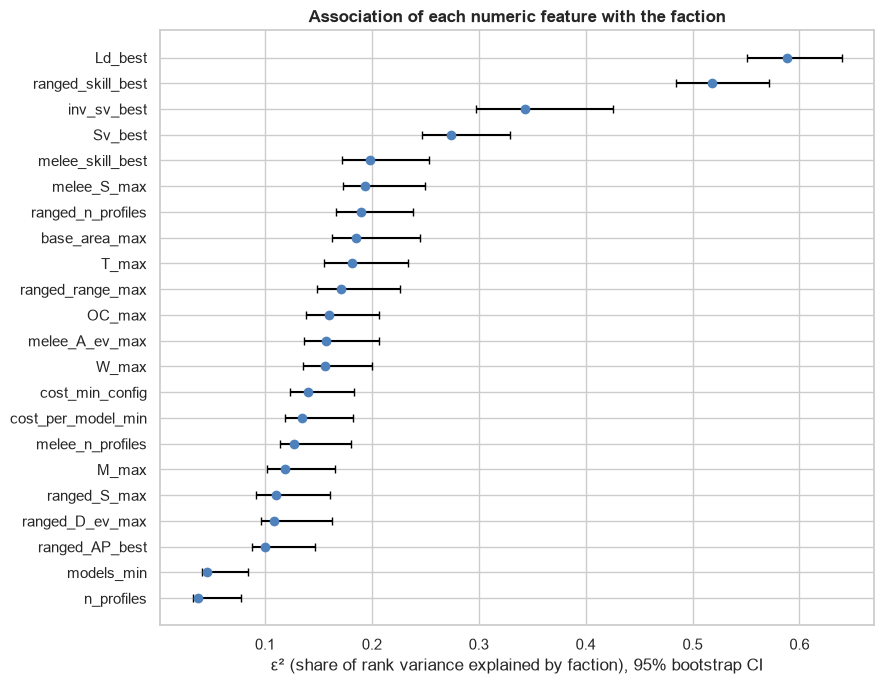

In [27]:
EFFECT_FEATURES = ["M_max", "T_max", "Sv_best", "W_max", "Ld_best", "OC_max", "n_profiles", "base_area_max",
                   "cost_min_config", "models_min", "cost_per_model_min", "ranged_n_profiles", "melee_n_profiles",
                   "ranged_range_max", "ranged_S_max", "ranged_AP_best", "ranged_D_ev_max", "ranged_skill_best",
                   "melee_S_max", "melee_A_ev_max", "melee_skill_best", "inv_sv_best"]
effects = []
for column in EFFECT_FEATURES:
    point, low, high = epsilon_squared_with_ci(features[column], features["faction_id"])
    effects.append({"feature": column, "epsilon2": point, "ci_low": low, "ci_high": high,
                    "n": int(features[column].notna().sum())})
effects = pd.DataFrame(effects).sort_values("epsilon2", ascending=False).reset_index(drop=True)
display(effects)

fig, ax = plt.subplots(figsize=(9, 7))
order = effects.iloc[::-1]
ax.errorbar(order["epsilon2"], order["feature"],
            xerr=np.clip(np.vstack([order["epsilon2"] - order["ci_low"], order["ci_high"] - order["epsilon2"]]), 0, None),
            fmt="o", color=BAR_COLOR, ecolor="black", capsize=3)
ax.set_xlabel("ε² (share of rank variance explained by faction), 95% bootstrap CI")
ax.set_title("Association of each numeric feature with the faction")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Two characteristics stand out.** **Leadership** (ε² = 0.59, 95% CI 0.55–0.64) and the **best ranged skill** (0.52, CI 0.48–0.57) are far more associated with the faction than anything else. Both are largely set per faction by the game design: Orks shoot on 5+, most Space Marines on 3+, Tyranids have Leadership 8+. They will probably be among the most useful mechanical features. The design also means that factions sharing a "template" (the Chaos legions, for instance) will be hard to separate with them.
- **A middle group** — invulnerable save, armour save, melee skill and strength, number of ranged profiles, base, Toughness, range, OC, Wounds — lies between 0.15 and 0.34. Its intervals overlap heavily, so **no ranking inside that group is supported by the data**.
- **Size and composition variables** (`models_min`, `n_profiles`) have small effects (< 0.05): unit size alone says little about the faction.
- **Limits of the measure.** These are **univariate** associations. They say nothing about the gain of one feature once the others are known, and they do not show predictive power (no model has been trained). The weapon envelopes are computed only on datasheets with weapons of that type (n = 1,160–1,300).

### 9.2 Faction profiles

Median of selected features per faction. The colour is the **rank** of each faction's median among the 25 factions (0 = lowest, 1 = highest), so that one extreme faction (Adeptus Titanicus) does not flatten the scale and features in different units share one colour scale. The numbers in the cells are the actual medians. For `Sv_best`, `Ld_best` and `ranged_AP_best` a **lower** number is better in the game.

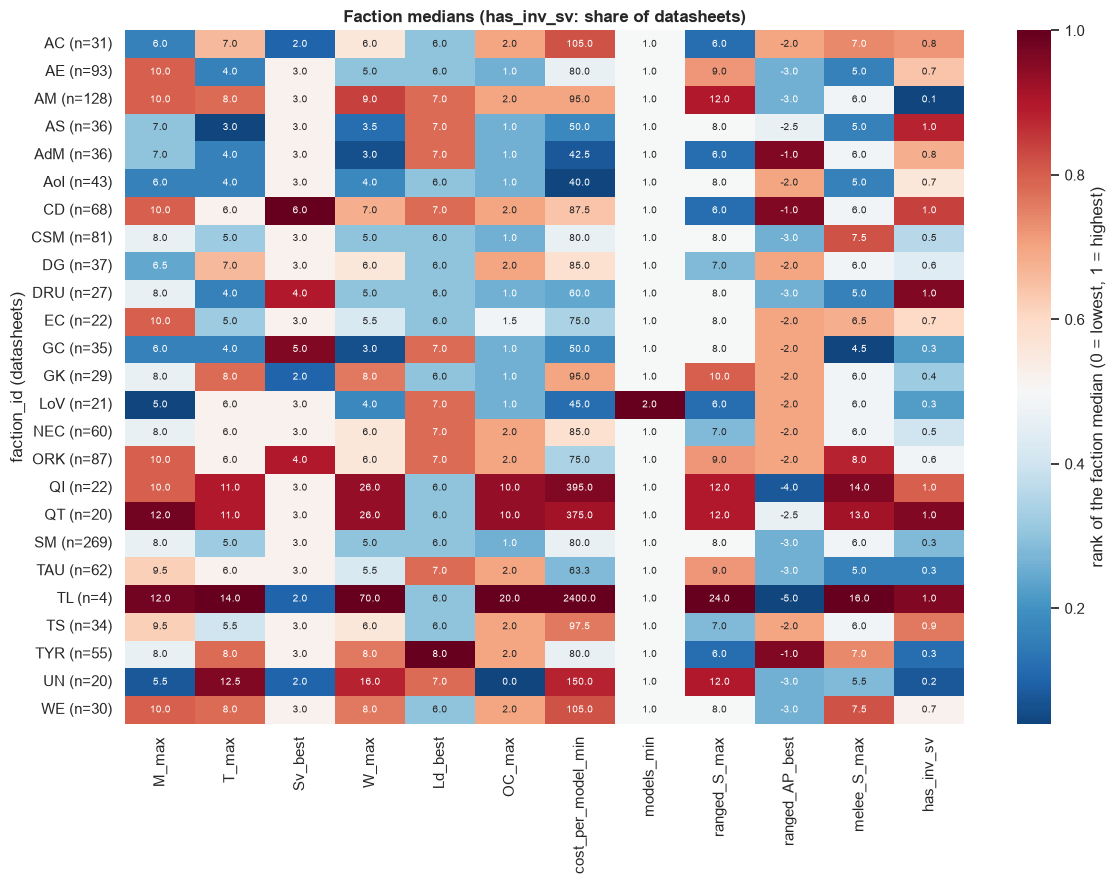

Columns of the heatmap:


,abbreviation,full name
0,M_max,"Movement (maximum), median of the faction"
1,T_max,"Toughness (maximum), median of the faction"
2,Sv_best,"Save (best), median of the faction"
3,W_max,"Wounds (maximum), median of the faction"
4,Ld_best,"Leadership (best), median of the faction"
5,OC_max,"Objective Control (maximum), median of the faction"
6,cost_per_model_min,"Points per model (smallest configuration), median of the..."
7,models_min,"Models in the smallest configuration, median of the faction"
8,ranged_S_max,"Ranged weapons: Strength (maximum), median of the faction"
9,ranged_AP_best,"Ranged weapons: Armour penetration (best), median of the..."


In [28]:
PROFILE_FEATURES = ["M_max", "T_max", "Sv_best", "W_max", "Ld_best", "OC_max", "cost_per_model_min", "models_min",
                    "ranged_S_max", "ranged_AP_best", "melee_S_max", "has_inv_sv"]
medians = features.groupby("faction_id")[PROFILE_FEATURES].median()
medians.loc[:, "has_inv_sv"] = features.groupby("faction_id")["has_inv_sv"].mean()  # share, not median
median_ranks = medians.rank(pct=True)
fig, ax = plt.subplots(figsize=(12, 9))
datasheets_per_faction = features["faction_id"].value_counts()
sns.heatmap(median_ranks, annot=medians.round(1), fmt="", cmap="RdBu_r", center=0.5, ax=ax,
            yticklabels=[f"{f} (n={datasheets_per_faction[f]})" for f in median_ranks.index],
            cbar_kws={"label": "rank of the faction median (0 = lowest, 1 = highest)"}, annot_kws={"fontsize": 7})
ax.set_title("Faction medians (has_inv_sv: share of datasheets)")
ax.set_xlabel("")
ax.set_ylabel("faction_id (datasheets)")
plt.tight_layout()
plt.show()

print("Columns of the heatmap:")
display(pd.DataFrame({"abbreviation": PROFILE_FEATURES,
                      "full name": [full_name(c) + (", share of datasheets" if c == "has_inv_sv" else ", median of the faction")
                                    for c in PROFILE_FEATURES]}))

**Interpretation.** The faction medians match the factions' design themes in the game; these are descriptive observations, not tests:
- **Adeptus Titanicus** is extreme in every size feature (median Toughness 14, Wounds 70, OC 20, 2,400 points per model). **Imperial and Chaos Knights** follow (Wounds 26, OC 10, about 375–395 points per model).
- **Chaos Daemons** have the worst median armour save (6+) but 97% of their datasheets have an invulnerable save. **Astra Militarum** rarely has one (10%).
- **Imperial Agents, Adeptus Mechanicus and the Leagues of Votann** have the cheapest units per model (40–45 points).
- **Tyranids** have the worst median Leadership (8+).
- Many factions share the same medians in several columns (Save 3+, OC 1–2, one model). The differences are often in a few characteristics and in the tails, not in the typical unit. That is consistent with the moderate effect sizes of 9.1.

### 9.3 Melee versus ranged (Q5)

,faction_name,profiles,melee,melee_share,ci_low,ci_high
faction_id,,,,,,
UN,Unaligned Forces,58,4,0.069,0.027,0.164
AM,Astra Militarum,822,182,0.221,0.194,0.251
TL,Adeptus Titanicus,36,8,0.222,0.117,0.381
TAU,T’au Empire,288,68,0.236,0.191,0.288
GK,Grey Knights,174,44,0.253,0.194,0.322
SM,Space Marines,1634,484,0.296,0.275,0.319
AE,Aeldari,476,148,0.311,0.271,0.354
GC,Genestealer Cults,114,36,0.316,0.238,0.406
AoI,Imperial Agents,282,92,0.326,0.274,0.383


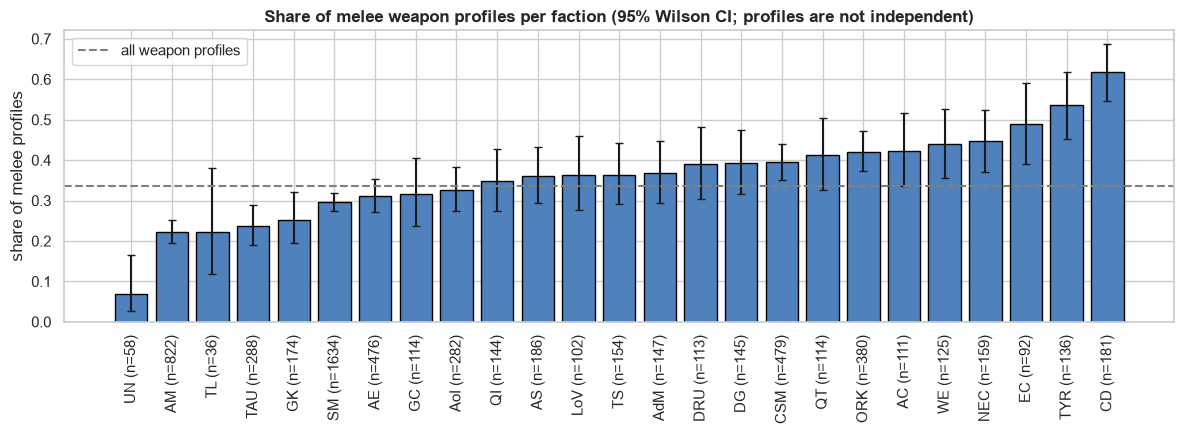

In [29]:
weapon_mix = weapons.merge(sheets[["datasheet_id", "faction_id"]], on="datasheet_id")
mix = weapon_mix.groupby("faction_id").agg(profiles=("line", "size"),
                                            melee=("weapon_type", lambda s: int((s == "Melee").sum())))
mix["melee_share"] = mix["melee"] / mix["profiles"]
mix["ci_low"], mix["ci_high"] = wilson_interval(mix["melee"], mix["profiles"])
mix = mix.sort_values("melee_share")
mix.insert(0, "faction_name", FACTION_NAMES.reindex(mix.index))
display(mix)
fig, ax = plt.subplots(figsize=(12, 4.5))
positions = np.arange(len(mix))
errors = np.clip(np.vstack([mix["melee_share"] - mix["ci_low"], mix["ci_high"] - mix["melee_share"]]), 0, None)
ax.bar(positions, mix["melee_share"], yerr=errors, capsize=3, color=BAR_COLOR, edgecolor="black")
ax.axhline((weapons["weapon_type"] == "Melee").mean(), color="grey", linestyle="--", label="all weapon profiles")
ax.set_xticks(positions, [f"{f} (n={n})" for f, n in zip(mix.index, mix["profiles"])], rotation=90)
ax.set_ylabel("share of melee profiles")
ax.set_title("Share of melee weapon profiles per faction (95% Wilson CI; profiles are not independent)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.**
- **Two ends.** The share of melee profiles ranges from 7% (Unaligned Forces, mostly fortifications) and 22–24% (Astra Militarum, Adeptus Titanicus, T'au) to 54% (Tyranids) and 62% (Chaos Daemons). This matches the "shooting army versus close-combat army" themes of the factions.
- **The intervals are too narrow.** The Wilson intervals treat every weapon profile as independent, which they are not: profiles of the same datasheet, and of shared units, are correlated. The intervals should be read as a lower bound of the uncertainty.
- **Overlap.** Most factions lie between 30% and 45% with overlapping intervals; the share separates only the extremes.

### 9.4 Points cost: elite versus horde (Q5)

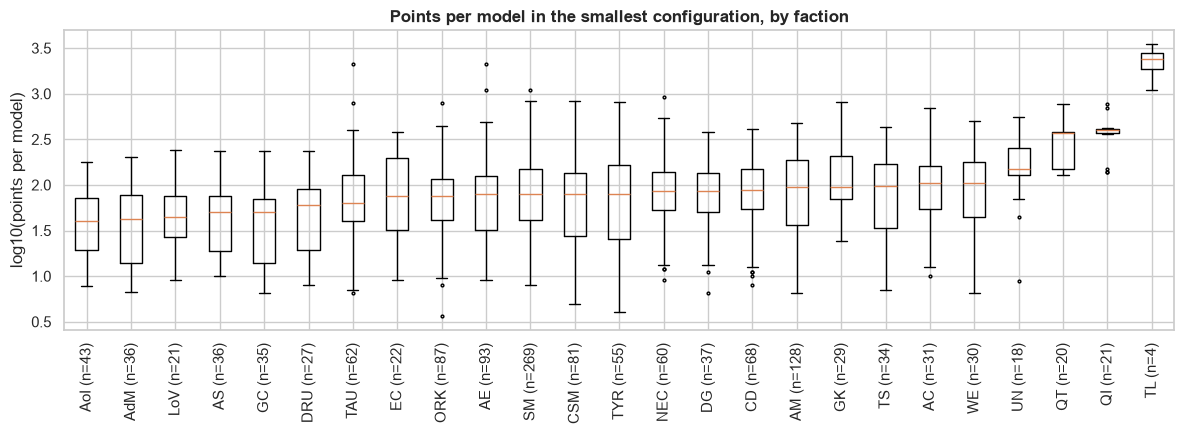

,cost_min_config,cost_per_model_min,W_max,T_max,Sv_best,OC_max,ranged_D_ev_max,melee_S_max,models_min
cost_min_config,1.000,0.737,0.683,0.741,-0.551,0.480,0.456,0.592,-0.175
cost_per_model_min,0.737,1.000,0.939,0.815,-0.537,0.479,0.414,0.587,-0.772


In [30]:
cost_order = features.groupby("faction_id")["cost_per_model_min"].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 4.5))
costed_per_faction = features.groupby("faction_id")["cost_per_model_min"].count()
ax.boxplot([np.log10(features.loc[features["faction_id"] == f, "cost_per_model_min"].dropna()) for f in cost_order],
           tick_labels=[f"{f} (n={costed_per_faction[f]})" for f in cost_order], flierprops={"markersize": 2})
ax.set_ylabel("log10(points per model)")
ax.set_title("Points per model in the smallest configuration, by faction")
ax.tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

cost_correlations = features[["cost_min_config", "cost_per_model_min", "W_max", "T_max", "Sv_best", "OC_max",
                              "ranged_D_ev_max", "melee_S_max", "models_min"]].corr(method="spearman")
display(cost_correlations.loc[["cost_min_config", "cost_per_model_min"]])

**Interpretation.**
- **Points per model.** Across factions the median spans from about 40 points (Imperial Agents, Adeptus Mechanicus, Leagues of Votann) to about 375–395 (Chaos and Imperial Knights) and 2,400 (Titanicus). The **elite versus horde** contrast exists, but most factions overlap widely: every faction has both cheap and expensive units.
- **What drives cost.** Points per model are strongly associated with the model's size: Spearman ρ = 0.94 with maximum Wounds and 0.82 with Toughness. They are negatively associated with the minimum number of models (ρ = −0.77): hordes are cheap per model.
- **Redundancy.** Cost is therefore largely redundant with the size characteristics (see 9.7). Its extra value for classification would come from the *price* that each faction pays for similar statistics, which the interaction below measures.

**Interaction: the price of the same size in each faction.** Points per model grow with the size of the model, so the boxplot above mixes two things: how large a faction's models are, and how much the faction pays for a given size. A common fit of log10(points per model) on log10(maximum Wounds) over all datasheets separates them. The residual of each datasheet is its price **relative to a model of the same Wounds** (0 = the common fit, +0.3 ≈ twice the price). If the faction explains the residual, the price per size carries information that Wounds alone does not.

Common fit on 1,347 datasheets: log10(points per model) = 0.99 + 1.14 · log10(W_max), R² = 0.88


,epsilon2,ci_low,ci_high
quantity,,,
log10(points per model),0.135,0.119,0.177
log10(W_max),0.158,0.139,0.209
price residual for the same Wounds,0.102,0.087,0.147


Factions that pay the least and the most for the same Wounds (median residual; price relative to the common fit):


,faction_name,n,median_residual,price_vs_common_fit
faction_id,,,,
ORK,Orks,87,-0.094,0.806
TYR,Tyranids,55,-0.091,0.811
QT,Chaos Knights,20,-0.048,0.896
CD,Chaos Daemons,68,-0.034,0.924
QI,Imperial Knights,21,-0.033,0.926
GC,Genestealer Cults,35,0.061,1.151
AE,Aeldari,93,0.070,1.176
GK,Grey Knights,29,0.070,1.176
AC,Adeptus Custodes,31,0.116,1.308


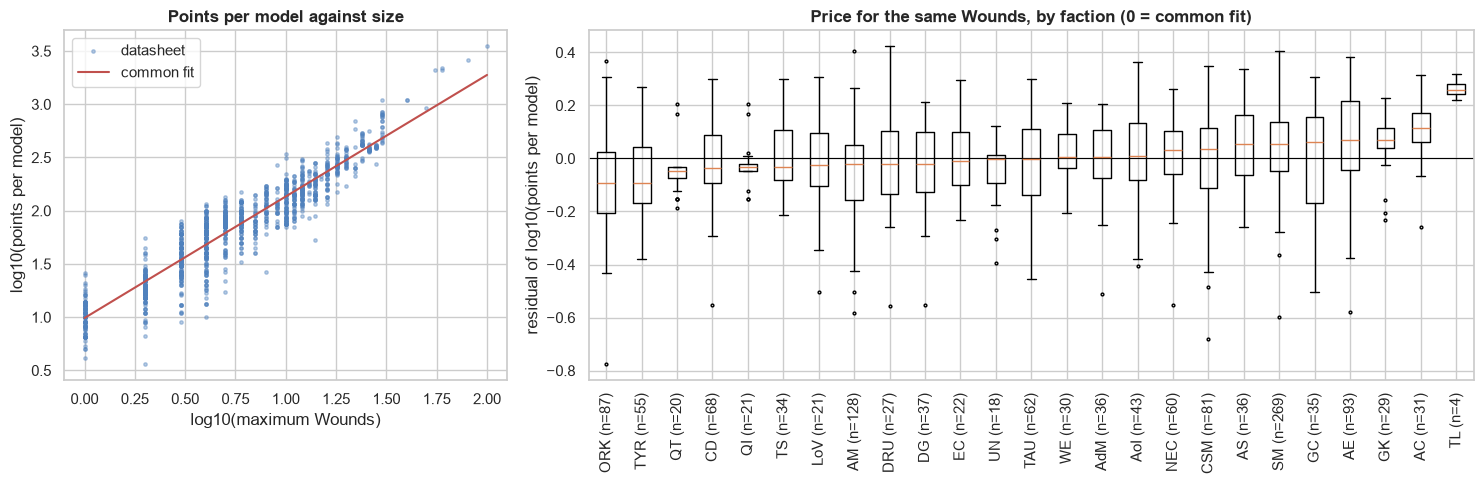

In [31]:
size_price = features[["faction_id", "W_max", "cost_per_model_min"]].dropna()
log_wounds = np.log10(size_price["W_max"])
log_price = np.log10(size_price["cost_per_model_min"])
slope, intercept = np.polyfit(log_wounds, log_price, 1)
size_price["price_residual"] = log_price - (intercept + slope * log_wounds)
print(f"Common fit on {len(size_price):,} datasheets: log10(points per model) = {intercept:.2f} + {slope:.2f} · log10(W_max), "
      f"R² = {np.corrcoef(log_wounds, log_price)[0, 1] ** 2:.2f}")

interaction_rng = np.random.default_rng(RANDOM_STATE)  # own generator: the later bootstrap intervals do not change
price_effects = []
for label, values in [("log10(points per model)", log_price), ("log10(W_max)", log_wounds),
                      ("price residual for the same Wounds", size_price["price_residual"])]:
    point, low, high = epsilon_squared_with_ci(values, size_price["faction_id"], generator=interaction_rng)
    price_effects.append({"quantity": label, "epsilon2": point, "ci_low": low, "ci_high": high})
price_effects = pd.DataFrame(price_effects).set_index("quantity")
display(price_effects)

residual_by_faction = (size_price.groupby("faction_id")["price_residual"]
                       .agg(n="size", median_residual="median").sort_values("median_residual"))
residual_by_faction["price_vs_common_fit"] = 10 ** residual_by_faction["median_residual"]
residual_by_faction.insert(0, "faction_name", FACTION_NAMES.reindex(residual_by_faction.index))
print("Factions that pay the least and the most for the same Wounds (median residual; price relative to the common fit):")
display(pd.concat([residual_by_faction.head(5), residual_by_faction.tail(5)]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].scatter(log_wounds, log_price, s=6, alpha=0.4, color=BAR_COLOR, label="datasheet")
grid = np.linspace(log_wounds.min(), log_wounds.max(), 50)
axes[0].plot(grid, intercept + slope * grid, color=ALT_COLOR, label="common fit")
axes[0].set_xlabel("log10(maximum Wounds)")
axes[0].set_ylabel("log10(points per model)")
axes[0].set_title("Points per model against size")
axes[0].legend()
axes[1].boxplot([size_price.loc[size_price["faction_id"] == f, "price_residual"] for f in residual_by_faction.index],
                tick_labels=[f"{f} (n={n})" for f, n in residual_by_faction["n"].items()], flierprops={"markersize": 2})
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("residual of log10(points per model)")
axes[1].set_title("Price for the same Wounds, by faction (0 = common fit)")
axes[1].tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

**Interpretation.**
- **Size explains most of the price.** The common log–log fit on 1,347 datasheets explains R² = 0.88 of the points per model: each doubling of Wounds multiplies the price by about 2.2 (slope 1.14).
- **The faction still matters at equal size.** The residual, the price relative to a model with the same Wounds, keeps ε² = 0.10 (95% CI 0.09–0.15) with the faction, against 0.13 for the raw points per model and 0.16 for Wounds. The price for the same size is therefore a distinct and weaker signal, not a copy of Wounds.
- **Who pays what.** Orks and Tyranids pay about 0.81 times the common price for a model of the same Wounds; Adeptus Custodes about 1.31 times, Grey Knights and Aeldari 1.18 times. Adeptus Titanicus (1.82 times) rests on 4 datasheets and is anecdotal.
- **Caveats.** Wounds is only one dimension of a model's value (saves, weapons and abilities also raise the price), so the residual mixes the faction's pricing with every other characteristic. It is an association, not a pricing rule of the game. Used as a feature, the fit must be estimated on the training fold only.

### 9.5 Keywords: the share of `Fly` per unit (Q6)

`Fly` is the clearest mechanical keyword. Its share is computed **per unit** (a unit either has the role or not, 6.2), with a 95% Wilson interval. The first line of the output shows, on the whole export, what a count by rows of `DS_Keywords` would give instead.

Whole export, Thousand Sons: 51 Fly rows / 60 datasheets = 85.0% (count by rows); per unit: 20 / 60 = 33.3%


,faction_id,faction_name,datasheets,with_fly,share,ci_low,ci_high
0,TAU,T’au Empire,62,37,0.597,0.473,0.710
4,TS,Thousand Sons,34,12,0.353,0.215,0.521
10,SM,Space Marines,269,46,0.171,0.131,0.221
18,AM,Astra Militarum,128,10,0.078,0.043,0.138
20,GC,Genestealer Cults,35,0,0.000,0.000,0.099


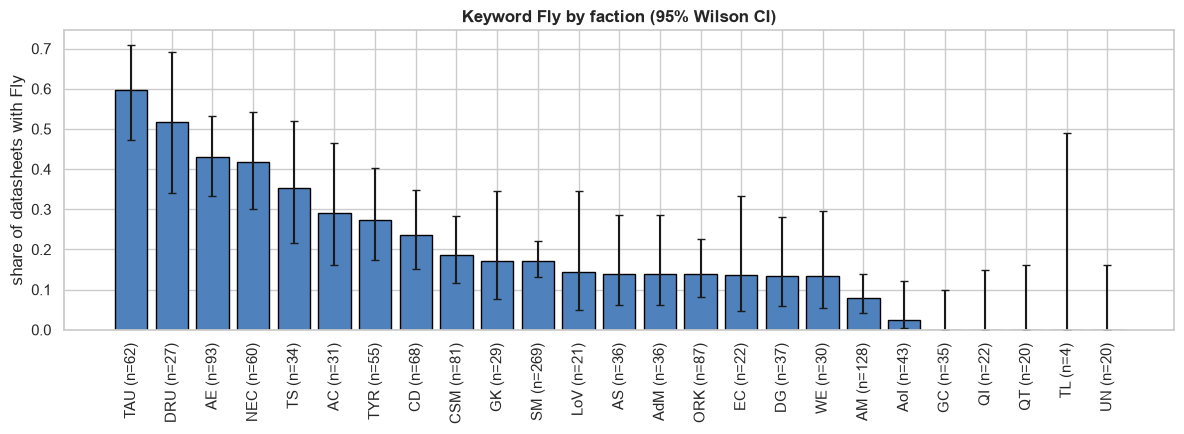

In [32]:
fly = query("""
    SELECT d.faction_id,
           COUNT(*) AS datasheets,
           SUM(EXISTS (SELECT 1 FROM keywords AS k WHERE k.datasheet_id = d.datasheet_id AND k.keyword = 'Fly'))
               AS with_fly
    FROM datasheet_features AS d
    GROUP BY d.faction_id""")
# count by rows on the whole export (before the empty duplicates were removed), for comparison
export_ts = query("""SELECT COUNT(*) AS datasheets,
                            SUM(EXISTS (SELECT 1 FROM raw.DS_Keywords AS k WHERE k.datasheet_id = d.id AND k.keyword = 'Fly'))
                                AS units_with_fly,
                            (SELECT COUNT(*) FROM raw.DS_Keywords AS k JOIN raw.Datasheets AS x ON x.id = k.datasheet_id
                             WHERE x.faction_id = 'TS' AND k.keyword = 'Fly') AS fly_rows
                     FROM raw.Datasheets AS d WHERE d.faction_id = 'TS'""").iloc[0]
print(f"Whole export, Thousand Sons: {export_ts['fly_rows']} Fly rows / {export_ts['datasheets']} datasheets = "
      f"{export_ts['fly_rows'] / export_ts['datasheets']:.1%} (count by rows); per unit: "
      f"{export_ts['units_with_fly']} / {export_ts['datasheets']} = {export_ts['units_with_fly'] / export_ts['datasheets']:.1%}")
fly["share"] = fly["with_fly"] / fly["datasheets"]
fly["ci_low"], fly["ci_high"] = wilson_interval(fly["with_fly"], fly["datasheets"])
fly = fly.sort_values("share", ascending=False).reset_index(drop=True)
fly.insert(1, "faction_name", fly["faction_id"].map(FACTION_NAMES))
display(fly[fly["faction_id"].isin(["TS", "TAU", "SM", "AM", "GC"])])

fig, ax = plt.subplots(figsize=(12, 4.5))
positions = np.arange(len(fly))
errors = np.clip(np.vstack([fly["share"] - fly["ci_low"], fly["ci_high"] - fly["share"]]), 0, None)
ax.bar(positions, fly["share"], yerr=errors, capsize=3, color=BAR_COLOR, edgecolor="black")
ax.set_xticks(positions, [f"{f} (n={n})" for f, n in zip(fly["faction_id"], fly["datasheets"])], rotation=90)
ax.set_ylabel("share of datasheets with Fly")
ax.set_title("Keyword Fly by faction (95% Wilson CI)")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Counting rows instead of units inflates the share.** On the whole export, the Thousand Sons have 51 `Fly` rows for 60 datasheets, which would read as 85.0%, but only 20 of the 60 units (33.3%) have the role. The block of roles of their empty duplicates was stored several times (6.2).
- **On the clean data**, 12 of the 34 Thousand Sons units have `Fly` (**35.3%**, 95% CI 21–52%). No role is repeated any more, so a count by rows and a count by units give the same share in every faction.
- **T'au, Space Marines and Astra Militarum** had no repeated rows even in the whole export: 59.7%, 17.1% and 7.8% of their units have `Fly`.
- **Genestealer Cults** drop from 3.7% to **0%**: their units with `Fly` were empty duplicates of other factions' units.
- **What `Fly` actually does.** It remains a relevant keyword: T'au (60%), Drukhari (52%), Aeldari and Necrons (42–43%) stand out, while the Knights, titans and the Genestealer Cults never fly. Its association with the faction is moderate (Cramér's V ≈ 0.34, Section 10.7): it helps to separate a few factions, not to identify them.

### 9.6 `Fly` keyword versus flying base

The clean database keeps two flying indicators: `kw_FLY` (the rule) and `is_flying_base` (the physical stand of the miniature). Are they the same information? The two are cross-tabulated per datasheet.

In [33]:
features["kw_fly"] = features.index.isin(query("SELECT DISTINCT datasheet_id FROM keywords WHERE keyword = 'Fly'")
                                         ["datasheet_id"]).astype(int)
display(pd.crosstab(features["kw_fly"].map({0: "no Fly keyword", 1: "Fly keyword"}),
                    features["is_flying_base"].map({0: "no flying base", 1: "flying base"}), margins=True))
print(f"Cramér's V (kw_fly vs is_flying_base): {cramers_v_from_table(pd.crosstab(features['kw_fly'], features['is_flying_base'])):.2f}")

is_flying_base,flying base,no flying base,All
kw_fly,,,
Fly keyword,111,171,282
no Fly keyword,1,1067,1068
All,112,1238,1350


Cramér's V (kw_fly vs is_flying_base): 0.58


**Interpretation.**
- **They are not the same information.** The two features are related (V = 0.58) but not equal. In the clean data **171** datasheets have the `Fly` keyword without a flying base, and only 1 (*Corsair Cloud Dancer Band*) has a flying base without the keyword.
- **The flying base is almost a subset of `Fly`.** It separates light fliers (jetbikes, drones on transparent stands) from heavy fliers (grav-tanks, aircraft on large bases or hulls).
- **Keeping both is reasonable.** The model can learn the distinction, but the strong overlap means their importances will be shared.

### 9.7 Redundancy between numeric features

,feature_a,feature_b,rho
49,T_max,T_min,0.997
21,M_max,M_min,0.992
160,OC_max,OC_min,0.990
104,W_max,W_min,0.988
78,Sv_best,Sv_worst,0.986
269,models_min,models_max,0.952
293,cost_per_model_min,W_min,0.944
91,W_max,cost_per_model_min,0.939
394,ranged_S_max,ranged_D_ev_max,0.884
617,T_min,W_min,0.883


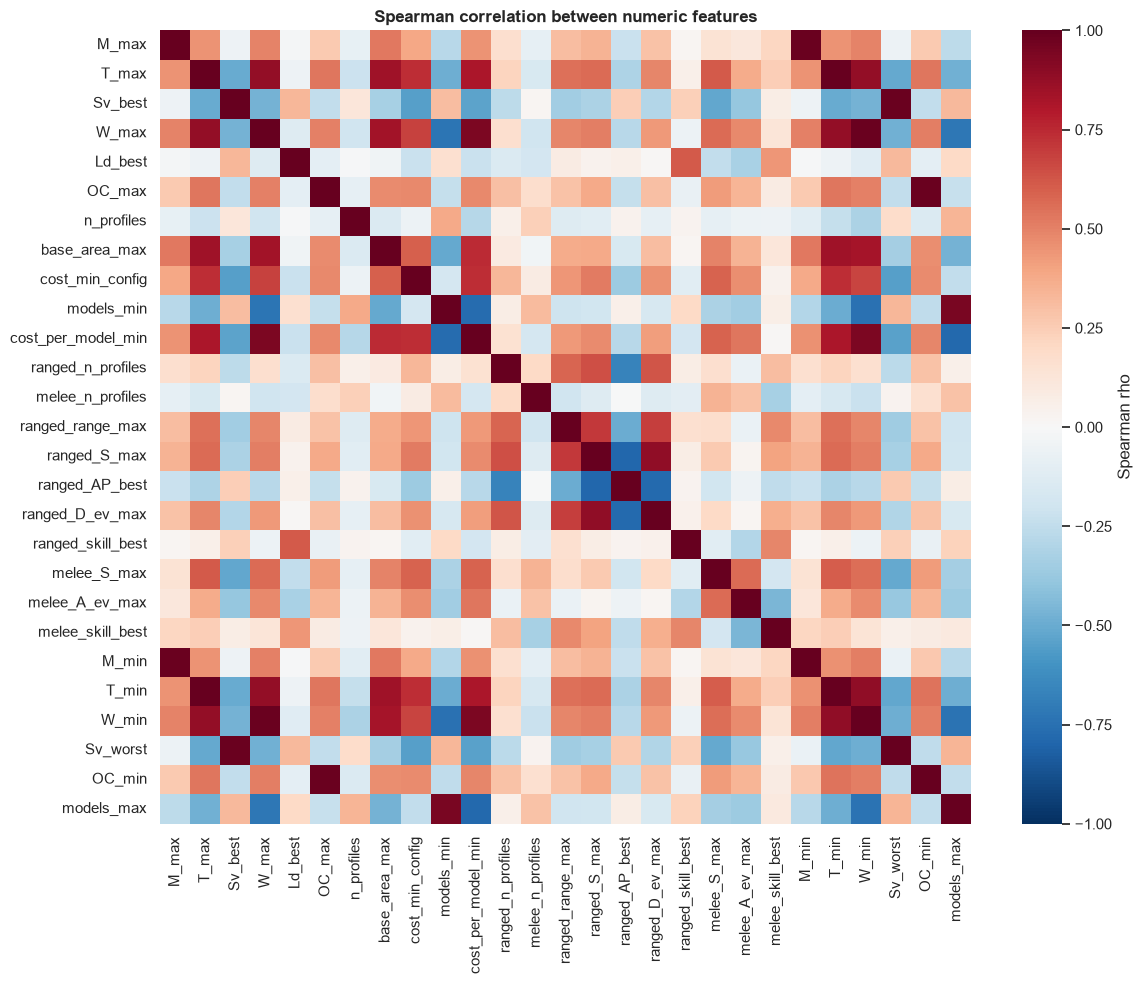

In [34]:
NUMERIC_FOR_CORRELATION = [c for c in EFFECT_FEATURES if c != "inv_sv_best"] + ["M_min", "T_min", "W_min",
                                                                               "Sv_worst", "OC_min", "models_max"]
spearman = features[NUMERIC_FOR_CORRELATION].corr(method="spearman")
pairs = (spearman.where(np.triu(np.ones(spearman.shape, dtype=bool), k=1)).stack()
         .rename("rho").reset_index().rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
display(pairs[pairs["rho"].abs() >= 0.8].sort_values("rho", key=np.abs, ascending=False))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(spearman, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Spearman rho"})
ax.set_title("Spearman correlation between numeric features")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Minimum and maximum of the same characteristic** are almost identical (ρ ≈ 0.99), because 95% of datasheets have a single profile. Keeping both doubles features without information. A better encoding is the maximum plus a **spread** (`max − min`) or the `multi_profile` flag.
- **A strong "size" factor** links Toughness, Wounds, base area and points per model (ρ 0.82–0.94). Linear models will need regularisation or a reduced set. Trees will split the importance among them.
- **Within the weapon features**, ranged strength and ranged damage are strongly linked (ρ = 0.88), as expected for heavy weapons.
- **No pair is perfectly redundant.** None of these correlations justify dropping a feature *now*: redundancy is a matter for feature selection inside the modelling pipeline, using training data only.

### 9.8 Are datasheets independent observations? Related units and identical rows (Q7)

Several units are published in more than one faction (`Chaos Rhino`, `Land Raider`, …). Two kinds of relation matter for validation:

1. **Same unit, several datasheets:** the same name (after normalising case, apostrophes and hyphens) appears in several factions or sources.
2. **Same mechanics, different name:** two datasheets have exactly the same model profiles and weapon profiles (names ignored), e.g. a loyalist and a traitor version of the same tank.

Both relations are merged with a union-find into a canonical **`GroupId`**: datasheets connected by either relation, directly or through a chain, share a group.

In [35]:
def row_signature(frame):
    """One text key per row: values joined with '|', missing values written as 'NA'."""
    return frame.astype(object).where(frame.notna(), "NA").astype(str).agg("|".join, axis=1)


def normalise_name(name):
    """Canonical form of a datasheet name for grouping."""
    text = clean_text(name).lower()
    return re.sub(r"[^a-z0-9]+", " ", text).strip()


profile_signature = (profiles.sort_values(["datasheet_id", "line"])
                     .assign(sig=lambda d: row_signature(d[["M_raw", "T_raw", "Sv_raw", "inv_sv_raw", "W", "Ld_raw", "OC"]]))
                     .groupby("datasheet_id")["sig"].agg(lambda s: ";".join(sorted(s))))
weapon_signature = (weapons.assign(sig=lambda d: row_signature(d[["weapon_type", "range_raw", "A_raw", "BS_WS_raw",
                                                                  "S_raw", "AP", "D_raw"]]))
                    .groupby("datasheet_id")["sig"].agg(lambda s: ";".join(sorted(s))))
groups_frame = pd.DataFrame(index=features.index)
groups_frame["name_key"] = features["name"].map(normalise_name)
groups_frame["mechanics_key"] = profile_signature.reindex(features.index) + "#" + weapon_signature.reindex(features.index).fillna("")

parent = {datasheet: datasheet for datasheet in groups_frame.index}


def find(node):
    while parent[node] != node:
        parent[node] = parent[parent[node]]
        node = parent[node]
    return node


def union(a, b):
    root_a, root_b = find(a), find(b)
    if root_a != root_b:
        parent[max(root_a, root_b)] = min(root_a, root_b)


for key_column in ["name_key", "mechanics_key"]:
    for members in groups_frame.groupby(key_column).groups.values():
        members = list(members)
        for other in members[1:]:
            union(members[0], other)
groups_frame["GroupId"] = [find(datasheet) for datasheet in groups_frame.index]
features["GroupId"] = groups_frame["GroupId"]

group_sizes = features.groupby("GroupId").agg(size=("faction_id", "size"), factions=("faction_id", "nunique"))
relation_counts = pd.DataFrame([
    {"relation": "datasheets sharing a normalised name with another datasheet",
     "datasheets": int(groups_frame["name_key"].duplicated(keep=False).sum())},
    {"relation": "datasheets with identical profiles and weapons to another datasheet",
     "datasheets": int(groups_frame["mechanics_key"].duplicated(keep=False).sum())},
    {"relation": "…of which with a different name",
     "datasheets": int((groups_frame["mechanics_key"].duplicated(keep=False)
                        & ~groups_frame.groupby("mechanics_key")["name_key"].transform("nunique").eq(1)).sum())},
    {"relation": "datasheets in a group of size > 1", "datasheets": int(group_sizes.loc[group_sizes["size"] > 1, "size"].sum())},
    {"relation": "datasheets in a group that spans several factions",
     "datasheets": int(group_sizes.loc[group_sizes["factions"] > 1, "size"].sum())},
])
print(f"{features['GroupId'].nunique()} groups for {len(features)} datasheets "
      f"(largest group: {group_sizes['size'].max()} datasheets)")
print("How many datasheets are related to another datasheet, by type of relation:")
with pd.option_context("display.max_colwidth", 100):
    display(relation_counts)
print("Number of groups by group size (size 1 = a datasheet related to no other; size 4 = four related datasheets):")
display(group_sizes["size"].value_counts().sort_index().rename_axis("group size").rename("groups").to_frame().T)

largest = group_sizes.sort_values("size", ascending=False).head(6).index
print("The six largest groups: names of the units they contain and the factions that publish them:")
display(features.loc[features["GroupId"].isin(largest), ["GroupId", "name", "faction_id"]]
        .sort_values(["GroupId", "faction_id"]).groupby("GroupId")
        .agg(names=("name", lambda s: ", ".join(sorted(set(s)))[:90]), factions=("faction_id", lambda s: ", ".join(sorted(set(s))))))

1207 groups for 1350 datasheets (largest group: 5 datasheets)
How many datasheets are related to another datasheet, by type of relation:


,relation,datasheets
0,datasheets sharing a normalised name with another datasheet,179
1,datasheets with identical profiles and weapons to another datasheet,158
2,…of which with a different name,80
3,datasheets in a group of size > 1,251
4,datasheets in a group that spans several factions,223


Number of groups by group size (size 1 = a datasheet related to no other; size 4 = four related datasheets):


group size,1,2,3,4,5
groups,1099,90,5,9,4


The six largest groups: names of the units they contain and the factions that publish them:


,names,factions
GroupId,,
119,"Librarian, Librarian In Phobos Armour, Sorcerer","CSM, EC, SM, TS"
956,Chaos Rhino,"CSM, DG, EC, TS, WE"
960,Chaos Spawn,"CSM, DG, EC, TS, WE"
962,Chaos Land Raider,"CSM, DG, EC, TS, WE"
963,Chaos Predator Destructor,"CSM, DG, TS, WE"
968,Maulerfiend,"CSM, EC, TS, WE"


**Interpretation: datasheets are still not independent observations.**
- **179 datasheets** share a normalised name with another datasheet.
- **158** have exactly the same model and weapon profiles as another, **80** of them under a different name, e.g. the *Thunderhawk Gunship* of the Space Marines and the Grey Knights, or the *Librarian* and the *Sorcerer*.
- **Groups.** The union of both relations gives **1,207 groups**. 251 datasheets belong to a group of two or more, and **223 belong to a group that spans several factions**. Examples:
  - the Chaos vehicles and monsters (*Chaos Rhino*, *Chaos Land Raider*, *Chaos Spawn*, *Helbrute*, *Defiler*, …) shared by Chaos Space Marines and the legions, now with weapons in every copy;
  - the *Rhino* and *Land Raider* families of the Space Marines, Grey Knights, Custodes and Imperial Agents.
- **Removing the empty duplicates reduced the structure a lot** (from 693 to 223 datasheets in cross-faction groups), but did not remove it: the shared units with weapons on both sides remain.
- **Consequence for evaluation.** With a random split, versions of the same unit fall on both sides and the model is evaluated on units it has already seen. Section 11.5 quantifies this effect.

## 10. Exploratory feature engineering (Q8)

### 10.1 Why not the mean of the model profiles?

For the datasheets with several profiles, the mean of a characteristic usually equals **no model of the unit**. The example below is one of them; the table counts how often the mean profile is not a real profile.

In [36]:
multi = profiles[profiles["datasheet_id"].isin(profile_features.index[profile_features["n_profiles"] > 1])]
example_id = multi.groupby("datasheet_id").size().idxmax()
example = multi.loc[multi["datasheet_id"] == example_id, ["model_name", "M", "T", "Sv", "W", "Ld", "OC"]]
display(pd.concat([example, example[["M", "T", "Sv", "W", "Ld", "OC"]].mean().to_frame("unweighted mean").T
                    .assign(model_name="—")]))

real_value = []
for column in ["T", "W", "Sv", "OC"]:
    per_sheet = multi.groupby("datasheet_id")[column]
    mean_is_real = per_sheet.apply(lambda s: bool(np.isclose(s.mean(), s).any()))
    real_value.append({"characteristic": column, "multi_profile_datasheets": len(mean_is_real),
                       "mean_equals_a_real_profile": int(mean_is_real.sum()),
                       "mean_is_fictional": int((~mean_is_real).sum())})
display(pd.DataFrame(real_value))

,model_name,M,T,Sv,W,Ld,OC
413,BEASTMASTER,12.000,4.000,6.000,3.000,6.000,1.000
414,CLAWED FIEND,12.000,4.000,6.000,5.000,8.000,1.000
415,KHYMERAE,12.000,4.000,6.000,2.000,8.000,1.000
416,RAZORWING FLOCK,12.000,4.000,6.000,3.000,8.000,1.000
unweighted mean,—,12.000,4.000,6.000,3.250,7.500,1.000


,characteristic,multi_profile_datasheets,mean_equals_a_real_profile,mean_is_fictional
0,T,69,61,8
1,W,69,7,62
2,Sv,69,54,15
3,OC,69,56,13


**Interpretation.**
- **The example.** The *Beastmaster* unit has four model types. Its "mean model" has 3.25 Wounds and Leadership 7.5, values that no model in the game has. An unweighted mean gives every multi-profile datasheet such a fictional model.
- **How often this happens.** Among the 69 multi-profile datasheets, the mean Wounds is a value of **no** real profile in **62** cases. For Save it is 15 and for OC 13. Toughness is often shared inside a unit, so the mean happens to be real more often.
- **The replacement.** The minimum and maximum always correspond to a real model of the unit.

### 10.2 Why not the mean cost?

In [37]:
multi_cost = base_costs.groupby("datasheet_id").filter(lambda g: len(g) > 1)
mean_cost = multi_cost.groupby("datasheet_id")["cost"].mean()
is_real_price = multi_cost.groupby("datasheet_id")["cost"].apply(lambda s: bool(np.isclose(s.mean(), s).any()))
print(f"Datasheets with several sizes: {len(mean_cost)}; the mean cost is a real price in "
      f"{int(is_real_price.sum())} of them and a non-existent price in {int((~is_real_price).sum())}.")
display(multi_cost[multi_cost["datasheet_id"] == multi_cost["datasheet_id"].iloc[0]][["description", "cost", "n_models"]]
        .assign(mean_cost=mean_cost.iloc[0]))

Datasheets with several sizes: 306; the mean cost is a real price in 12 of them and a non-existent price in 294.


,description,cost,n_models,mean_cost
14,10 models,80.000,10,125.000
15,20 models,170.000,20,125.000


**Interpretation.**
- **The mean cost is almost never a real price.** Of the 306 datasheets with several unit sizes, the mean of their prices is the price of a legal unit in only 12. In the example, a 10-model unit costs 80 points and a 20-model unit 170. Their mean, 125 points, corresponds to no unit that can be fielded.
- **The replacement.** The smallest configuration and its size are real values, and `models_max` with `n_size_options` keep the information about the larger sizes.

### 10.3 What is lost if dice expressions are dropped?

In [38]:
dice_bias = weapon_mix.groupby("faction_id").agg(
    attacks_mean_numbers_only=("A_ev", lambda s: s[weapon_mix.loc[s.index, "A_status"] == "fixed"].mean()),
    attacks_mean_with_dice=("A_ev", "mean"),
    share_profiles_with_dice=("A_status", lambda s: (s == "dice").mean()))
dice_bias["bias"] = dice_bias["attacks_mean_numbers_only"] - dice_bias["attacks_mean_with_dice"]
display(dice_bias.sort_values("share_profiles_with_dice", ascending=False).head(8))
print(f"Rank correlation between the two faction rankings: "
      f"{stats.spearmanr(dice_bias['attacks_mean_numbers_only'], dice_bias['attacks_mean_with_dice']).statistic:.2f}")
mixed_attacks = weapons.groupby("datasheet_id")["A_status"].agg(lambda s: bool((s == "dice").any() and (s != "dice").any()))
print(f"Datasheets whose weapons mix dice and plain Attacks: {int(mixed_attacks.sum())} of {len(mixed_attacks)}. "
      "Without the dice parser, their attack features would be computed on only part of their weapons.")

,attacks_mean_numbers_only,attacks_mean_with_dice,share_profiles_with_dice,bias
faction_id,,,,
TL,10.524,9.444,0.417,1.079
UN,3.300,3.974,0.310,-0.674
QI,5.217,5.104,0.264,0.113
TYR,5.146,5.162,0.243,-0.016
QT,5.908,5.640,0.237,0.268
DG,3.652,3.762,0.228,-0.110
ORK,3.442,3.511,0.226,-0.068
TS,3.537,3.727,0.214,-0.190


Rank correlation between the two faction rankings: 0.98


Datasheets whose weapons mix dice and plain Attacks: 662 of 1332. Without the dice parser, their attack features would be computed on only part of their weapons.


**Interpretation.**
- **At faction level the effect is small.** Comparing the mean attacks per faction with and without the dice values, the ranking hardly changes (ρ = 0.98). The largest shifts are Adeptus Titanicus (+1.1 attacks) and Unaligned Forces (−0.7).
- **The loss is at datasheet level.** Without the dice parser, weapons with dice would silently drop out of their datasheet's features. 662 of the 1,332 datasheets with weapons mix dice and plain Attacks, so their attack features would be computed on only part of their weapons, and *which* part would depend on whether the weapon uses dice. The parser keeps every weapon, with expected value, minimum and maximum.

### 10.4 Is the damaged bracket redundant with Wounds?

`damaged_w` was removed (4.2) because the information it carries — a large model that fights worse when it is damaged — is already captured by its high Wounds. This is checked with the range written in `damaged_description` (the cleaned text, not the removed column).

The first table gives, for each value of `W_max` between 6 and 20, the share of datasheets with a damaged profile. The Wounds bands of the second table are cut where that share changes: almost no datasheet has a damaged profile up to W = 10, the share jumps above 70% at W = 11, and it stays above 85% from W = 14.

In [39]:
bracket = query_text("SELECT id, damaged_description FROM raw.Datasheets WHERE damaged_description IS NOT NULL")
bracket["datasheet_id"] = bracket["id"].astype(int)
bracket["damaged_max_wounds"] = (bracket["damaged_description"].map(clean_text)
                                 .str.extract(r"\d+-(\d+) wounds? remaining")[0].astype(float))
bracket = bracket.merge(features[["W_max"]], left_on="datasheet_id", right_index=True)
print(f"Datasheets with a damaged profile: {len(bracket)}; "
      f"Spearman(upper end of the damaged range, W_max) = "
      f"{stats.spearmanr(bracket['damaged_max_wounds'], bracket['W_max']).statistic:.2f}")
has_bracket = features.index.isin(bracket["datasheet_id"])
share_by_wounds = (pd.Series(has_bracket, index=features.index).groupby(features["W_max"])
                   .agg(datasheets="size", with_damaged_profile="sum", share="mean").loc[6:20])
display(share_by_wounds.round({"share": 2}))
wound_bands = pd.cut(features["W_max"], [0, 10, 13, 1000], labels=["W <= 10", "W 11-13", "W >= 14"])
display(pd.crosstab(wound_bands, pd.Series(has_bracket, index=features.index).map({True: "damaged profile",
                                                                                   False: "no damaged profile"}),
                    margins=True))

Datasheets with a damaged profile: 355; Spearman(upper end of the damaged range, W_max) = 0.98


,datasheets,with_damaged_profile,share
W_max,,,
6,92,0,0.000
7,38,0,0.000
8,46,0,0.000
9,25,0,0.000
10,93,1,0.010
11,49,36,0.730
12,69,58,0.840
13,15,13,0.870
14,54,48,0.890


col_0,damaged profile,no damaged profile,All
W_max,,,
W <= 10,1,960,961
W 11-13,107,26,133
W >= 14,247,9,256
All,355,995,1350


**Interpretation: `damaged_w` is redundant with Wounds.**
- **The range follows the Wounds.** The upper end of the damaged range has a rank correlation of **0.98** with the model's maximum Wounds.
- **Only large models have a damaged profile.** Up to W = 9 no datasheet has one, and at W = 10 only 1 of 93. The share jumps to 73% at W = 11 and stays at 84–100% from W = 12. In bands: 1 of 961 datasheets with W ≤ 10, 107 of 133 with W 11–13 and 247 of 256 with W ≥ 14.
- **Conclusion.** Knowing that a model degrades adds little to knowing that it is large, which `W_max`, `T_max` and `base_area_max` already describe. The column stays removed.

### 10.5 Core abilities and their parameters

In [40]:
core_columns = sorted(c for c in features.columns if c.startswith("core_") and not c.endswith("_value"))
core_associations = []
for column in core_columns:
    point, low, high = cramers_v_with_ci(features[column], features["faction_id"])
    core_associations.append({"feature": column, "datasheets": int(features[column].sum()),
                              "cramers_v": point, "ci_low": low, "ci_high": high})
display(pd.DataFrame(core_associations).sort_values("cramers_v", ascending=False))
display(query("""SELECT ability_name, parameter_raw, COUNT(*) AS rows FROM core_abilities
                 WHERE parameter_raw IS NOT NULL GROUP BY ability_name, parameter_raw
                 ORDER BY ability_name, rows DESC""").groupby("ability_name").head(4))

,feature,datasheets,cramers_v,ci_low,ci_high
1,core_deep_strike,307,0.484,0.449,0.542
0,core_deadly_demise,550,0.282,0.262,0.344
4,core_firing_deck,53,0.277,0.198,0.406
10,core_stealth,71,0.219,0.169,0.328
9,core_scouts,82,0.181,0.143,0.302
7,core_leader,344,0.167,0.156,0.253
2,core_feel_no_pain,99,0.129,0.121,0.236
6,core_infiltrators,63,0.128,0.092,0.254
3,core_fights_first,21,0.103,0.075,0.250
5,core_hover,40,0.087,0.063,0.224


,ability_name,parameter_raw,rows
0,Deadly Demise,D3,230
1,Deadly Demise,D6,138
2,Deadly Demise,1,100
3,Deadly Demise,D6+2,56
10,Feel No Pain,5+,51
11,Feel No Pain,6+,43
12,Feel No Pain,4+,5
13,Firing Deck,2,14
14,Firing Deck,6,13
15,Firing Deck,11,7


**Interpretation.**
- **The strongest associations** are *Deep Strike* (V = 0.48, CI 0.45–0.54), *Deadly Demise* (0.28) and *Firing Deck* (0.28).
- **Rare abilities have wide intervals.** Their upper bound is two to three times the point value (e.g. *Fights First*, 21 datasheets), so their association is poorly determined.
- **These are shared rules, not identity labels.** Each one appears in many factions, so they describe *how* a unit plays.
- **The parameters add intensity.** Examples: Deadly Demise D3 vs D6, Feel No Pain 5+ vs 6+, Scouts 6" vs 9".

### 10.6 Keyword features must be selected inside the training folds

The clean table `DS_Keywords` applies a **universality filter**: a keyword is kept only if it appears in more than one faction. It is applied on all datasheets (4.6), and the exploratory sections use that vocabulary. The filter is reasonable (a keyword present in a single faction, like `Warboss`, works as a name), but it **uses the target**: deciding that a keyword is "universal" requires knowing the faction of the datasheets that carry it. Fitted on the whole dataset, the decision uses the labels of the test datasheets, a form of leakage. For the model, the filter must therefore be refitted on each training fold, starting from the full vocabulary, which the raw database keeps.

The check below applies the filter in two ways: once on all datasheets, and once using only the training part of each fold of a grouped split (Section 11.5). It counts the keywords whose decision changes.

In [41]:
# full vocabulary from the raw database: the filter is refitted on each training fold
keyword_table = query("""SELECT DISTINCT d.datasheet_id, k.keyword, d.faction_id FROM raw.DS_Keywords AS k
                         JOIN datasheet_features AS d ON d.datasheet_id = CAST(k.datasheet_id AS INTEGER)
                         WHERE k.is_faction_keyword = 'FALSE' AND k.keyword IS NOT NULL""")


def universal_keywords(rows, min_factions=2):
    """Keywords that appear in at least `min_factions` factions within `rows`."""
    spread = rows.groupby("keyword")["faction_id"].nunique()
    return set(spread[spread >= min_factions].index)


universal_all = universal_keywords(keyword_table)
group_folds = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []
for fold, (train_idx, test_idx) in enumerate(group_folds.split(features, features["faction_id"], features["GroupId"]), 1):
    train_ids = set(features.index[train_idx])
    universal_train = universal_keywords(keyword_table[keyword_table["datasheet_id"].isin(train_ids)])
    test_keywords = set(keyword_table.loc[~keyword_table["datasheet_id"].isin(train_ids), "keyword"])
    fold_rows.append({
        "fold": fold,
        "universal_on_all_data": len(universal_all),
        "universal_on_train_only": len(universal_train),
        "kept_only_thanks_to_test_labels": len(universal_all - universal_train),
        "test_keywords_unseen_in_train": len(test_keywords - set(keyword_table.loc[keyword_table["datasheet_id"]
                                                                                    .isin(train_ids), "keyword"])),
    })
display(pd.DataFrame(fold_rows))
print("Examples of keywords that are 'universal' only when the test labels are used:",
      sorted(universal_all - universal_train)[:12])

,fold,universal_on_all_data,universal_on_train_only,kept_only_thanks_to_test_labels,test_keywords_unseen_in_train
0,1,135,116,19,282
1,2,135,113,22,283
2,3,135,110,25,283
3,4,135,113,22,287


Examples of keywords that are 'universal' only when the test labels are used: ['Archon', 'Catachan', 'Chaos Spawn', 'Corvus Blackstar', 'Fortis Kill Team', 'Knight Lancer', 'Knight Magaera', 'Krieg', 'Lord of Change', 'Master of Executions', 'Maulerfiend', 'Ministorum Priest']


**Interpretation.**
- **The filter needs the target.** On all the data, 135 non-faction keywords pass the "≥ 2 factions" filter. Using only the training part of each grouped fold, 110–116 pass. **19–25 keywords per fold would be kept only because of the labels of the test datasheets.** Many of them are names of shared units (`Chaos Spawn`, `Maulerfiend`, `Corvus Blackstar`, `Ministorum Priest`): they are "universal" only because the same unit is published in two factions.
- **Most test keywords are unseen.** Each test fold contains about 283 keywords that never appear in its training part. They would be unknown columns for the model.
- **Rules for Data Preparation:**
  1. Refit the keyword vocabulary and the universality filter **inside each training fold** (a custom transformer in the `Pipeline`), starting from the full vocabulary of `raw.DS_Keywords`. The clean `DS_Keywords` is the exploratory version, fitted on all data.
  2. Exclude keywords that equal a normalised unit name.
  3. Merge plural variants (6.4).
  4. Keep the allegiance keywords `Imperium` / `Chaos` / `Aeldari` out of `X`, or test them as a sensitivity variant.

### 10.7 Uncertainty of the categorical associations

In [42]:
CATEGORICAL_FOR_V = ["role", "has_inv_sv", "kw_fly", "is_flying_base", "has_hull", "has_wargear", "multi_profile",
                     "M_is_minimum", "ranged_has_auto_hit", "has_addon_option"]
v_table = []
for column in CATEGORICAL_FOR_V:
    point, low, high = cramers_v_with_ci(features[column], features["faction_id"])  # missing rows are left out
    v_table.append({"feature": column, "n": int(features[column].notna().sum()), "cramers_v": point,
                    "ci_low": low, "ci_high": high})
v_table = pd.DataFrame(v_table).sort_values("cramers_v", ascending=False).reset_index(drop=True)
display(v_table)

,feature,n,cramers_v,ci_low,ci_high
0,has_inv_sv,1350,0.522,0.496,0.572
1,has_hull,1350,0.392,0.349,0.461
2,kw_fly,1350,0.343,0.303,0.413
3,role,1350,0.295,0.258,0.378
4,is_flying_base,1350,0.256,0.212,0.356
5,ranged_has_auto_hit,1205,0.218,0.194,0.311
6,has_wargear,1350,0.180,0.069,0.373
7,multi_profile,1350,0.140,0.122,0.241
8,M_is_minimum,1350,0.072,0.072,0.205
9,has_addon_option,1347,0.000,0.000,0.130


**Interpretation.**
- **Among the binary features:**
  - the presence of an **invulnerable save** (0.52) and of a **hull** (0.39) are the most associated with the faction;
  - next come `Fly` (0.34), the role (0.29) and the flying base (0.26).
- **`has_wargear` is weak now** (0.18, with a wide interval). Without the empty duplicates it marks only the 19 units without weapons by design, and it is redundant with the weapon counts, so it stays out of `X`.
- **Weak features.** The multi-profile flag, aircraft movement and add-on options are weakly associated (≤ 0.14).
- **Missing rows are left out, not coded.** `ranged_has_auto_hit` is computed on the 1,205 datasheets with ranged weapons, so its V (0.22) measures the rule itself, not the presence of ranged weapons.

### 10.8 Feature contract and explicit `X` / `y`

The contract fixes, for every family of features, where it comes from, at which granularity, with which rule, whether it is available at prediction time, its leakage risk and the action for Data Preparation. A second table states, for the same families, what each one is meant to capture, the exploratory evidence of its usefulness and its main limitation or redundancy. `X` and `y` are then built explicitly and validated in code.

In [43]:
FEATURE_FAMILIES = {
    "model envelope": [c for c in features.columns if re.match(r"^(M|T|Sv|inv_sv|W|Ld|OC)_", c)
                       or c in ("n_profiles", "multi_profile", "has_inv_sv")],
    "base": ["base_area_max", "is_flying_base", "has_hull"],
    "ranged envelope": [c for c in features.columns if c.startswith("ranged_")],
    "melee envelope": [c for c in features.columns if c.startswith("melee_")],
    "cost and size": ["cost_min_config", "models_min", "models_max", "n_size_options", "cost_per_model_min",
                      "has_addon_option", "cost_has_context"],
    "core abilities": [c for c in features.columns if c.startswith("core_")],
    "role": ["role"],
    "keywords (fit in fold)": ["kw_<keyword> for keywords present in >= 2 factions of the training fold"],
}
contract = pd.DataFrame([
    ["model envelope", "DS_Models", "model profile -> datasheet", "min / max per characteristic", "game units (inches, D6 thresholds, wounds)", "yes", "low", "keep; impute structural NaN with indicators"],
    ["base", "DS_Models.base_size", "model profile -> datasheet", "max area (circle / ellipse), any flying base", "mm²", "yes", "low", "keep; area missing for hulls"],
    ["ranged envelope", "DS_Wargear (Ranged)", "weapon profile -> datasheet", "best value + count; dice as expected value", "game units", "yes", "low (stats); names excluded", "keep; NaN when no ranged weapon"],
    ["melee envelope", "DS_Wargear (Melee)", "weapon profile -> datasheet", "best value + count; dice as expected value", "game units", "yes", "low", "keep; NaN when no melee weapon"],
    ["wargear presence", "DS_Wargear", "datasheet", "any profile", "0/1", "yes", "low", "redundant: equals ranged and melee counts both 0 (6.5)"],
    ["cost and size", "DS_Model_Costs", "configuration -> datasheet", "smallest legal configuration", "points, models", "yes", "low", "keep; log-transform costs"],
    ["damaged bracket", "Datasheets.damaged_w", "datasheet", "—", "wounds", "yes", "low", "removed (4.2): redundant with W (10.4)"],
    ["core abilities", "DS_Abilities (Core) + Abilities", "ability -> datasheet", "flag + parameter", "0/1, die thresholds, inches", "yes", "low (shared rules)", "keep"],
    ["role", "Datasheets.role", "datasheet", "as published", "category", "yes", "low", "one-hot"],
    ["keywords (fit in fold)", "raw.DS_Keywords (non-faction)", "keyword -> datasheet", "multi-hot of keywords seen in >= 2 factions of the training fold (the clean table holds the same filter fitted on all data, for exploration); allegiance keywords (Imperium, Chaos, Aeldari) only in a sensitivity variant", "0/1", "yes", "high if selected on all data; allegiance keywords name the alliance", "select inside each fold (10.6)"],
    ["unit / model / weapon names", "Datasheets.name, DS_Models.name, DS_Wargear.name", "datasheet", "—", "text", "yes", "semantic identity: names reveal the faction", "excluded: never in X"],
    ["identifiers, target", "datasheet_id, faction_id, faction_name, GroupId", "datasheet", "—", "—", "—", "direct", "never in X; GroupId only for the split"],
], columns=["family", "source", "granularity", "rule", "unit", "available_at_prediction", "leakage_risk", "action"])
contract["features"] = contract["family"].map(lambda f: len(FEATURE_FAMILIES.get(f, [])))
display(contract)

eps = effects.set_index("feature")["epsilon2"]
cv = v_table.set_index("feature")["cramers_v"]
core_top = pd.DataFrame(core_associations).sort_values("cramers_v", ascending=False).iloc[0]
residual_eps = price_effects.loc["price residual for the same Wounds", "epsilon2"]
usefulness = pd.DataFrame([
    ["model envelope", "faction-wide design values (Leadership, saves) and the size of the models",
     f"ε² Ld {eps['Ld_best']:.2f}, inv. save {eps['inv_sv_best']:.2f}, Sv {eps['Sv_best']:.2f}, T {eps['T_max']:.2f} (9.1); V has_inv_sv {cv['has_inv_sv']:.2f} (10.7)",
     "min ≈ max (ρ ≈ 0.99, 9.7); T and W share the size factor with base and cost (9.7)"],
    ["base", "physical size and kind of miniature (hull, flying stand)",
     f"ε² base area {eps['base_area_max']:.2f} (9.1); V has_hull {cv['has_hull']:.2f}, flying base {cv['is_flying_base']:.2f} (10.7)",
     "area missing for hulls; the flying base is almost a subset of Fly (9.6)"],
    ["ranged envelope", "shooting doctrine: skill, reach and power of the best gun",
     f"ε² ranged skill {eps['ranged_skill_best']:.2f}, range {eps['ranged_range_max']:.2f}, S {eps['ranged_S_max']:.2f} (9.1)",
     "the best profile may be an optional upgrade (11.4); S and D strongly linked (9.7)"],
    ["melee envelope", "close-combat doctrine: skill and power of the best melee weapon",
     f"ε² melee skill {eps['melee_skill_best']:.2f}, S {eps['melee_S_max']:.2f}, A {eps['melee_A_ev_max']:.2f} (9.1)",
     "an envelope of capabilities, not the carried loadout (4.7)"],
    ["wargear presence", "units without any weapon", f"V {cv['has_wargear']:.2f} (10.7)",
     "marks only 19 units; equal to both weapon counts being 0 (6.5)"],
    ["cost and size", "elite versus horde, and the price each faction pays for its statistics",
     f"ε² points per model {eps['cost_per_model_min']:.2f} (9.1); price for the same Wounds ε² {residual_eps:.2f} (9.4)",
     "points per model largely follow Wounds (9.4); skewed, needs a log scale (7.3)"],
    ["damaged bracket", "a large model that fights worse when damaged", "upper end of the range follows W (10.4)",
     "redundant with Wounds: removed"],
    ["core abilities", "shared rules: how a unit plays", f"strongest V {core_top['cramers_v']:.2f} ({core_top['feature']}, 10.5)",
     "rare abilities have wide intervals (10.5)"],
    ["role", "battlefield role printed on the datasheet", f"V {cv['role']:.2f} (10.7)", "coarse: 'Other' covers half of the datasheets (7.5)"],
    ["keywords (fit in fold)", "rule categories shared by several factions", f"V Fly {cv['kw_fly']:.2f} (10.7)",
     "the filter uses the labels (10.6); plural variants (6.4)"],
], columns=["family", "captures", "evidence", "limitation"])
with pd.option_context("display.max_colwidth", 120):
    display(usefulness)

y = features["faction_id"]
groups = features["GroupId"]
FORBIDDEN = {"datasheet_id", "faction_id", "faction_name", "name", "is_virtual", "GroupId", "kw_fly"}
feature_columns = [c for family, columns in FEATURE_FAMILIES.items() if family != "keywords (fit in fold)" for c in columns]
X = features[feature_columns]

leaked = FORBIDDEN & set(X.columns)
if leaked:
    raise ValueError(f"Forbidden columns in X: {sorted(leaked)}")
if len(X) != len(y) or not X.index.equals(y.index):
    raise ValueError("X and y are not aligned.")
if len(X.columns.difference(X.select_dtypes(include="number").columns).difference(CATEGORICAL_FEATURES)) > 0:
    raise ValueError("X must hold numeric and mechanical values only.")
print(f"y: {len(y)} datasheets, {y.nunique()} classes")
print(f"X shape {X.shape}: numeric and mechanical features only (+ keyword columns selected inside each fold)")
print(f"Validation groups: {groups.nunique()} GroupId values")

,family,source,granularity,rule,unit,available_at_prediction,leakage_risk,action,features
0,model envelope,DS_Models,model profile -> datasheet,min / max per characteristic,"game units (inches, D6 thresholds, wounds)",yes,low,keep; impute structural NaN with indicators,18
1,base,DS_Models.base_size,model profile -> datasheet,"max area (circle / ellipse), any flying base",mm²,yes,low,keep; area missing for hulls,3
2,ranged envelope,DS_Wargear (Ranged),weapon profile -> datasheet,best value + count; dice as expected value,game units,yes,low (stats); names excluded,keep; NaN when no ranged weapon,10
3,melee envelope,DS_Wargear (Melee),weapon profile -> datasheet,best value + count; dice as expected value,game units,yes,low,keep; NaN when no melee weapon,8
4,wargear presence,DS_Wargear,datasheet,any profile,0/1,yes,low,redundant: equals ranged and melee counts both 0 (6.5),0
5,cost and size,DS_Model_Costs,configuration -> datasheet,smallest legal configuration,"points, models",yes,low,keep; log-transform costs,7
6,damaged bracket,Datasheets.damaged_w,datasheet,—,wounds,yes,low,removed (4.2): redundant with W (10.4),0
7,core abilities,DS_Abilities (Core) + Abilities,ability -> datasheet,flag + parameter,"0/1, die thresholds, inches",yes,low (shared rules),keep,15
8,role,Datasheets.role,datasheet,as published,category,yes,low,one-hot,1
9,keywords (fit in fold),raw.DS_Keywords (non-faction),keyword -> datasheet,multi-hot of keywords seen in >= 2 factions of the train...,0/1,yes,high if selected on all data; allegiance keywords name t...,select inside each fold (10.6),1


,family,captures,evidence,limitation
0,model envelope,"faction-wide design values (Leadership, saves) and the size of the models","ε² Ld 0.59, inv. save 0.34, Sv 0.27, T 0.18 (9.1); V has_inv_sv 0.52 (10.7)","min ≈ max (ρ ≈ 0.99, 9.7); T and W share the size factor with base and cost (9.7)"
1,base,"physical size and kind of miniature (hull, flying stand)","ε² base area 0.19 (9.1); V has_hull 0.39, flying base 0.26 (10.7)",area missing for hulls; the flying base is almost a subset of Fly (9.6)
2,ranged envelope,"shooting doctrine: skill, reach and power of the best gun","ε² ranged skill 0.52, range 0.17, S 0.11 (9.1)",the best profile may be an optional upgrade (11.4); S and D strongly linked (9.7)
3,melee envelope,close-combat doctrine: skill and power of the best melee weapon,"ε² melee skill 0.20, S 0.19, A 0.16 (9.1)","an envelope of capabilities, not the carried loadout (4.7)"
4,wargear presence,units without any weapon,V 0.18 (10.7),marks only 19 units; equal to both weapon counts being 0 (6.5)
5,cost and size,"elite versus horde, and the price each faction pays for its statistics",ε² points per model 0.13 (9.1); price for the same Wounds ε² 0.10 (9.4),"points per model largely follow Wounds (9.4); skewed, needs a log scale (7.3)"
6,damaged bracket,a large model that fights worse when damaged,upper end of the range follows W (10.4),redundant with Wounds: removed
7,core abilities,shared rules: how a unit plays,"strongest V 0.48 (core_deep_strike, 10.5)",rare abilities have wide intervals (10.5)
8,role,battlefield role printed on the datasheet,V 0.29 (10.7),coarse: 'Other' covers half of the datasheets (7.5)
9,keywords (fit in fold),rule categories shared by several factions,V Fly 0.34 (10.7),the filter uses the labels (10.6); plural variants (6.4)


y: 1350 datasheets, 25 classes
X shape (1350, 62): numeric and mechanical features only (+ keyword columns selected inside each fold)
Validation groups: 1207 GroupId values


**Interpretation.**
- **Shape of `X`.** **62 numeric and mechanical columns** for 1,350 datasheets, plus the keyword columns chosen inside each fold. No text column enters `X`.
- **Validated in code.** No identifier, target alias, name or group key can enter `X`; `X` and `y` are aligned by `datasheet_id`.
- **Rules carried to Data Preparation:**
  - impute only inside the pipeline;
  - add indicators for structural absences (no invulnerable save, no weapon of a type, no base);
  - log-transform costs and wounds;
  - drop near-duplicate `min` columns or replace them by a spread;
  - fit the keyword filter inside the folds.

## 11. Conclusions, limitations and roadmap

### 11.1 Answers to the guiding questions

**Q1 – Construction.** The raw export is verified (checksums, headers, row counts). It has three problems:
- 134 orphan weapons and 124 orphan stratagem links;
- 285 empty duplicates: copies of shared units whose weapons are stored only on another copy. They are not loaded (4.6, 6.5);
- values that a reader with type guessing alters (`N/A`, `+N`, `None`): they are read as exact text.

One row of the analytical table is **one datasheet** (1,350 rows, unique key). Every aggregate has a meaning that holds without knowing the unit's composition: envelope of profiles, strongest weapon of each type, price of the smallest legal unit.

**Q2 – Quality.** No value breaks the game's domain rules and no characteristic fails to parse. Most missing values are **structural**: no invulnerable save, no base, immobile, no weapon of a type. They become indicators, never zeros. The 19 datasheets left without any weapon are units without weapons by design (fortifications, drop pods, explosive units): their weapon counts are 0.

**Q3 – Target.** The 25 factions are strongly imbalanced (269 to 4 datasheets, ratio 67.2). The majority baseline reaches accuracy 0.199 but macro F1 0.013, so **macro F1** is the primary metric.

**Q4 – Model statistics.** **Leadership** (ε² ≈ 0.59) and **ranged skill** (≈ 0.52) are by far the most associated with the faction. They reflect faction-wide design values. Saves, Toughness, melee strength and range follow (0.15–0.34) with overlapping intervals; unit size has little association.

**Q5 – Weapons and cost.** Shooting factions (T'au, Astra Militarum) and close-combat factions (Chaos Daemons, Tyranids) differ at the extremes of the melee share, but most factions overlap. Points per model separate elite and horde factions only partially, and they are largely explained by the model's size (ρ = 0.94 with Wounds). At equal Wounds, the faction still explains part of the price (ε² 0.10, 9.4).

**Q6 – Keywords and abilities.** Core abilities (*Deep Strike*, *Deadly Demise*) and rule keywords (`Fly`) are moderately associated with the faction (V 0.3–0.4).
- **Most non-faction keywords are names in disguise**: 90% appear in one faction.
- **Selecting "universal" keywords uses the target**: 19–25 keywords per fold depend on test labels.
- **Shares must be counted per unit.** Counting rows of `DS_Keywords` inflates them: for the Thousand Sons, 85% by rows against 33% per unit on the whole export, and 35% on the clean data.

**Q7 – Related units.**
- 223 datasheets belong to groups that span several factions (693 before the empty duplicates were removed).
- **5.9% of the datasheets have a vector `X` identical to a datasheet of another faction**, which caps the accuracy of any classifier on those features at about 0.97.
- A stratified random split puts an identical twin of 4.4% of the test rows in the training set and cuts about 45 groups per fold. A grouped split reduces both to almost zero.

**Q8 – Features.** The feature contract (10.8) lists 62 mechanical features with source, rule, availability and leakage risk.
- **Excluded:** identifiers, the target alias, names (words are never used to predict), faction and allegiance keywords, and `has_wargear`.
- **Fitted inside the folds:** the keyword filter.

### 11.2 Quality problems to treat in Data Preparation

| Problem | Evidence | Treatment |
|---|---|---|
| Units without weapons by design | 19 fortifications, drop pods and explosive units (6.5) | weapon counts = 0; envelopes structurally missing, with an indicator |
| Structural absences | inv. save 53%, hull bases, immobile models (6.6) | indicator + value left missing; imputation only inside the pipeline |
| Skewed scales | Wounds up to 100, points up to 3,500 (7.1, 7.3) | log transform or rank-based models |
| Near-duplicate columns | min/max ρ ≥ 0.99 (9.7) | keep max + spread / multi-profile flag |
| Keyword vocabulary | 90% single-faction keywords, plural variants, allegiance keywords (6.4, 7.4, 10.6) | normalise, exclude unit-name and allegiance keywords, select inside each fold |
| Values altered by type guessing | `N/A` → empty, `+55` → 55, `None` → empty (4.4) | read the CSV as text; type each column with explicit rules |

### 11.3 Variables and interactions likely to matter

- **Faction-wide design values:** Leadership, ranged and melee skill, saves and invulnerable saves.
- **The "size" factor and the price per size:** Toughness, Wounds, base and points per model move together, but the price paid for the same Wounds differs by faction (ε² of the residual 0.10, against 0.13 for the raw price, 9.4), so it may separate factions with similar statistics.
- **Mechanical rule markers:** `Fly`, flying base, *Deep Strike*, *Deadly Demise*, hull.
- **Interactions** are expected between size and role (a 10-Wounds *Character* versus a 10-Wounds vehicle), and between weapon type and skill. Tree-based models capture them naturally; linear models would need them explicitly.

### 11.4 Limitations, biases and open questions

- **Composition.** Unit sizes and prices come from `DS_Model_Costs` (`total_models`, `cost_per_model`), the more direct source (4.6). The only thing not used is how a unit is split between its profiles, so totals of mixed units (total wounds, total attacks) are not features. The aggregates were chosen so that they do not need it.
- **Weapon options.** The weapon list does not mark which weapons are default and which are optional, so the "strongest profile" may be an upgrade the unit rarely carries.
- **The smallest class.** Adeptus Titanicus has 4 datasheets: any per-class result for it is anecdotal.
- **A single snapshot.** Points and profiles change with game updates; the associations describe the 2025-10-03 data.
- **Associations, not causes.** The statistics in this notebook are associations measured on the whole dataset, with bootstrap intervals that treat datasheets as independent (Section 9.8 shows they are not). No predictive claim is made before a model is evaluated on grouped folds.
- **Open question.** The empty copies were removed, but some units are still published with weapons in two or more factions (9.8). Should they stay as separate observations with different labels, or be merged? The answer depends on the use case and should be decided before modelling.

### 11.5 Evaluation design for the modelling notebook

The design is fixed **before** any model is trained. To show why grouped validation is needed without training a model, the code below compares a stratified split with a stratified **grouped** split on two model-free quantities:

- **Twins in train:** share of test datasheets whose feature vector `X` (keywords excluded) is *identical* to a training datasheet. A model can score those rows by memory.
- **Groups cut by the split:** groups that have datasheets on both sides.

In [44]:
signature = row_signature(X.round(4))
identical = signature.groupby(signature).transform("size") > 1
conflicting = signature.groupby(signature).transform(lambda s: features.loc[s.index, "faction_id"].nunique()) > 1
print(f"Datasheets whose vector X is identical to another datasheet: {identical.sum()} ({identical.mean():.1%})")
print(f"...whose twin belongs to a different faction (irreducible error): "
      f"{conflicting.sum()} ({conflicting.mean():.1%})")
# Best possible accuracy with X: each set of identical vectors can only receive one label
ceiling = features.groupby(signature)["faction_id"].agg(lambda s: s.value_counts().iloc[0]).sum() / len(features)
print(f"Upper bound of the accuracy of any classifier on X (without keywords): {ceiling:.3f}")
conflict_examples = (features.assign(signature=signature)[conflicting]
                     .groupby("signature")
                     .agg(datasheets=("name", "size"),
                          factions=("faction_id", lambda s: ", ".join(sorted(set(s)))),
                          names=("name", lambda s: ", ".join(sorted(set(s)))[:70]))
                     .sort_values("datasheets", ascending=False).head(8).reset_index(drop=True))
display(conflict_examples)

split_rows = []
for scheme, splitter, split_groups in [
    ("StratifiedKFold", StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE), None),
    ("StratifiedGroupKFold", StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE), groups),
]:
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, split_groups), 1):
        train_signatures = set(signature.iloc[train_idx])
        test_signatures = signature.iloc[test_idx]
        train_groups = set(groups.iloc[train_idx])
        split_rows.append({
            "scheme": scheme, "fold": fold, "test_rows": len(test_idx),
            "test_with_twin_in_train": test_signatures.isin(train_signatures).mean(),
            "groups_cut": len(train_groups & set(groups.iloc[test_idx])),
            "classes_missing_in_test": y.nunique() - y.iloc[test_idx].nunique(),
            "min_class_count_in_train": y.iloc[train_idx].value_counts().min(),
        })
split_table = pd.DataFrame(split_rows)
display(split_table.groupby("scheme").agg(test_with_twin_in_train=("test_with_twin_in_train", "mean"),
                                          groups_cut=("groups_cut", "mean"),
                                          classes_missing_in_test=("classes_missing_in_test", "max"),
                                          min_class_count_in_train=("min_class_count_in_train", "min")))
display(split_table)

Datasheets whose vector X is identical to another datasheet: 80 (5.9%)
...whose twin belongs to a different faction (irreducible error): 80 (5.9%)
Upper bound of the accuracy of any classifier on X (without keywords): 0.970


,datasheets,factions,names
0,3,"CSM, EC, TS",Maulerfiend
1,3,"CSM, EC, TS",Chaos Land Raider
2,3,"GK, SM",Land Raider Crusader
3,3,"AC, AoI, SM","Anathema Psykana Rhino, Imperial Rhino, Rhino"
4,2,"CSM, DG",Chaos Predator Annihilator
5,2,"CSM, SM","Chaos Deimos Predator, Deimos Predator"
6,2,"GK, SM",Land Raider
7,2,"CD, WE",Skarbrand


,test_with_twin_in_train,groups_cut,classes_missing_in_test,min_class_count_in_train
scheme,,,,
StratifiedGroupKFold,0.001,0.000,0,3
StratifiedKFold,0.044,44.750,0,3


,scheme,fold,test_rows,test_with_twin_in_train,groups_cut,classes_missing_in_test,min_class_count_in_train
0,StratifiedKFold,1,338,0.056,46,0,3
1,StratifiedKFold,2,338,0.044,44,0,3
2,StratifiedKFold,3,337,0.039,39,0,3
3,StratifiedKFold,4,337,0.039,50,0,3
4,StratifiedGroupKFold,1,338,0.003,0,0,3
5,StratifiedGroupKFold,2,338,0.000,0,0,3
6,StratifiedGroupKFold,3,337,0.000,0,0,3
7,StratifiedGroupKFold,4,337,0.003,0,0,3


**Interpretation.**
- **The ceiling.** 80 datasheets (5.9%) have a vector `X` identical to a datasheet of another faction. The largest sets are Chaos vehicles published identically for several legions (*Maulerfiend*, *Chaos Land Raider*) and the *Land Raider* / *Rhino* variants of the Imperium. No classifier using these features can exceed an accuracy of about **0.97**. That ceiling must be reported next to the results. Before the empty duplicates were removed it was 0.92: most identical vectors were empty copies.
- **Under `StratifiedKFold`**, **4.4%** of the test datasheets have an identical twin in the training set, and about **45 groups per fold** are cut between train and test. A model can score those rows by memory, so the metric would be optimistic by an amount that has nothing to do with generalisation.
- **Under `StratifiedGroupKFold`**, no group is cut. Only 0.1% of the test rows have a twin in training: different units whose aggregated features coincide.
- **Class support.** Every class is present in every test fold, and the smallest class keeps 3 datasheets in each training part.

**Evaluation design for the modelling notebook:**
1. **Hold-out test set.** Separate a test set (≈ 20%) with `StratifiedGroupKFold` on `GroupId` and do not use it for any decision.
2. **Model selection.** On the rest, use `StratifiedGroupKFold` with 4 folds, repeated with different seeds because of the small classes, and report the variability between folds.
3. **Sensitivity check.** Repeat with `StratifiedKFold` only to measure the optimism that related units introduce.
4. **Metrics.** Macro F1 is the primary metric. Report balanced accuracy, weighted F1, per-class recall with support and the confusion matrix. Report accuracy only as a reference, together with the 0.97 ceiling.
5. **Baselines.** Majority class (macro F1 0.013), then a class-weighted model. SMOTE is not required.
6. **Pipeline.** Imputers, scalers and the keyword filter are fitted inside the training folds of a `Pipeline`.

### 11.6 Hypotheses to validate (and leakage prevention)

| # | Hypothesis | How to validate it | Leakage guard |
|---|---|---|---|
| H1 | Leadership and ranged skill are the most useful mechanical features | permutation importance on grouped folds | importance computed on validation folds only |
| H2 | The mechanical features reach a macro F1 well above the majority baseline, below the 0.97 accuracy ceiling | grouped CV, model vs baseline | `GroupId` folds; test set untouched |
| H3 | The units shared between factions (9.8) concentrate the confusions of the Chaos legions and the Imperial factions | confusion matrix restricted to grouped units | `GroupId` folds |
| H4 | Keyword features help beyond the core abilities | grouped CV with and without keywords | universality filter fitted inside each fold |
| H5 | A random split overstates macro F1 | StratifiedKFold vs StratifiedGroupKFold on the same model | sensitivity analysis only, not for selection |
| H6 | Allegiance keywords (`Imperium`, `Chaos`) mostly separate alliances, not factions | confusion matrix with and without them | kept out of the main `X` |

In [45]:
connection.execute("DETACH DATABASE raw")
connection.close()
print(f"SQLite connections closed. {RAW_DB_PATH.relative_to(PROJECT_DIR)} and {CLEAN_DB_PATH.relative_to(PROJECT_DIR)} "
      "are generated artifacts: re-running the notebook rebuilds both from the CSV files.")

SQLite connections closed. artifacts\warhammer_raw.db and artifacts\warhammer_clean.db are generated artifacts: re-running the notebook rebuilds both from the CSV files.
